# SAIL Mapping-Don't Run Again!

In [ ]:
"""
SAIL Pipeline (Extractor + VISN Backfill + Master Combiner)
Created for Sith – November 2025

FINAL STANDALONE VERSION with Temporal-Aware Canonicalization

End-to-end:
1) Extract quarterly SAIL Excel files into per-FY CSVs.
2) Backfill VISN for FY20–FY24 using FY19 VISN assignments.
3) Combine FY15–FY24 into a single master CSV, with temporal-aware canonical names.

Key features:
- Robust category vs measure detection
- Temporal awareness: retired measures are dropped for their invalid periods
- Comprehensive canonicalization based on 10 years of SAIL documentation
- All-in-one file (no external dependencies)
"""

import os
import re
import glob
import unicodedata
from pathlib import Path
from typing import Optional, Tuple, Dict, List

import pandas as pd

# =============================================================================
# CONFIGURATION
# =============================================================================

BASE_DIR = r"/mnt/c/Users/lfult/OneDrive - bc.edu/VA_SAIL"
OUTPUT_DIR = BASE_DIR

FISCAL_YEARS = ["FY15", "FY16", "FY17", "FY18", "FY19",
                "FY20", "FY21", "FY22", "FY23", "FY24"]

MASTER_OUTPUT = os.path.join(OUTPUT_DIR, "SAIL_ALL_YEARS_combined.csv")
CONSOLIDATED_OUTPUT = os.path.join(OUTPUT_DIR, "SAIL_FY15-FY24_Master.csv")

# NOTE: Measure_canon and Category_canon are added as output columns; they are
# filled after extraction using the canonicalization lookup.
FINAL_COLUMNS = [
    "Facility",
    "Category", "Category_canon",
    "Measure", "Measure_canon",
    "Score", "Benchmark", "Pct_10", "Pct_50", "Pct_90",
    "Direction", "FY", "Quarter", "VISN",
]

# For VISN backfill (facilities not present in FY19)
MANUAL_VISN_MAPPINGS: Dict[str, str] = {
    "blackhills": "23",
    "easternkansas": "15",
    "manila": "21",
    "springfield": "16",
}

# =============================================================================
# TEMPORAL CANONICALIZATION (EMBEDDED)
# =============================================================================

def parse_fy_quarter(fy: str, quarter: str) -> Tuple[int, int]:
    """Convert FY and Quarter to comparable tuple (year, quarter_num)"""
    year = int(fy.replace("FY", ""))
    q_num = int(quarter.replace("Q", ""))
    return (year, q_num)


def is_measure_valid(measure_key: str, fy: str, quarter: str) -> bool:
    """
    Check if a measure should be included for a given FY/Quarter.
    Expects measure_key to already be lowercased and normalized.
    """
    year, q = parse_fy_quarter(fy, quarter)
    
    # Measures REMOVED in FY19Q4
    if (year, q) >= (19, 4):
        retired_19q4 = [
            'smr', 'in-hospital complications', 'in-hospital complication',
            'psi index', 'post-discharge adverse events', 'post discharge adverse events',
            'rn turnover'
        ]
        if any(retired in measure_key for retired in retired_19q4):
            return False
    
    # Call Center Responsiveness REMOVED in FY21Q4
    if (year, q) >= (21, 4):
        if 'call abandonment' in measure_key or 'speed in responding' in measure_key:
            return False
    
    # BH90 and CTR not reported in FY23
    if (year, q) >= (23, 1):
        if 'bh90' in measure_key or 'behavioral health composite' in measure_key:
            return False
        if 'communication of test results' in measure_key or 'ctr' in measure_key:
            return False
    
    # RSRR Stroke removed FY22Q3
    if (year, q) >= (22, 3):
        if 'rsrr' in measure_key and 'stroke' in measure_key:
            return False
    
    # SMG90_1 removed FY24Q1
    if (year, q) >= (24, 1):
        if 'smg90_1' in measure_key:
            return False
    
    return True


# Category canonicalization lookup
CATEGORY_CANON_LUT: Dict[str, str] = {
    # ED / Hospital flow
    "ed throughput": "ED Throughput",
    "ed flow": "ED Throughput",
    "ed flow composite": "ED Throughput",

    "hospital flow": "Hospital Flow",
    "hospital flow composite": "Hospital Flow",

    # Length of stay (name changed FY23Q1)
    "adjusted length of stay": "Length of Stay",
    "length of stay": "Length of Stay",
    "length of stay and throughput": "Length of Stay",
    "length of stay and utilization management": "Length of Stay",
    "los & utilization management": "Length of Stay",
    "los & throughput": "Length of Stay",
    "omelos": "Length of Stay",

    # HAI / patient safety
    "healthcare associated infections (hai)": "Healthcare-Associated Infections (HAI)",
    "health care associated infections (hai)": "Healthcare-Associated Infections (HAI)",
    "hospital acquired infections": "Healthcare-Associated Infections (HAI)",

    "patient safety indicator (psi)": "Patient Safety Indicator (PSI)",
    "patient safety indicator (psi average standardized score)": "Patient Safety Indicator (PSI)",

    # Inpatient performance - ORYX
    "inpatient performance measures (oryx gm90_1)": "Inpatient Performance Measures (ORYX)",
    "inpatient performance measures (oryx)": "Inpatient Performance Measures (ORYX)",
    "inpatient performance measures (oryx90)": "Inpatient Performance Measures (ORYX)",
    "inpatient performance measures (oryx90_1)": "Inpatient Performance Measures (ORYX)",

    # Outpatient performance
    "outpatient performance measures (hed90)": "Outpatient Performance Measures",
    "outpatient performance measures (hed90_1)": "Outpatient Performance Measures",
    "outpatient performance measures (hedis like)": "Outpatient Performance Measures",
    "outpatient performance measures (hed90_ec)": "Outpatient Performance Measures",

    # Prevention composite
    "prevention composite - eprp (prv90_2)": "Prevention Composite",
    "prevention composite - eprp (prv90_3)": "Prevention Composite",
    "prevention composite": "Prevention Composite",

    # Mortality
    "acute care standardized mortality ratio (smr)": "Acute Care Mortality",
    "acute care 30-day standardized mortality ratio (smr30)": "Acute Care Mortality",
    "cms risk standardized mortality rates (rsmr)": "CMS Mortality",
    "cms 30-day risk standardized mortality rate (rsmr)": "CMS Mortality",

    # Readmissions
    "hospital-wide 30-day readmission rate": "Hospital-Wide Readmissions",
    "hospital-wide 30-day readmission rate  (cms 18+)": "Hospital-Wide Readmissions",
    "hospital-wide 30-day readmission rate (cms 18+)": "Hospital-Wide Readmissions",
    "hospital-wide readmission": "Hospital-Wide Readmissions",

    # Care transitions
    "ambulatory care sensitive condition hospitalizations": "Care Transitions",
    "ambulatory care sensitive condition (acsc) hospitalizations": "Care Transitions",
    "care transitions": "Care Transitions",

    # Patient experience
    "patient satisfaction": "Patient Experience",
    "patient experience": "Patient Experience",

    # Employee satisfaction
    "employee satisfaction": "Employee Satisfaction",

    # Efficiency
    "efficiency": "Efficiency & Capacity",
    "efficiency/capacity": "Efficiency & Capacity",
    "efficiency & capacity": "Efficiency & Capacity",
}


# Measure canonicalization lookup
MEASURE_CANON_LUT: Dict[str, str] = {
    # ACCESS / WAIT TIMES
    "pcmh / specialty care access questions": "PCMH / Specialty Care Access",
    "pcmh access questions": "PCMH / Specialty Care Access",
    "pcmh / specialty care access survey scores": "PCMH / Specialty Care Access",
    "pcmh access composite": "PCMH Access Composite",
    "specialty care survey access composite": "Specialty Care Access Composite",

    # HEALTHCARE-ASSOCIATED INFECTIONS
    "healthcare associated infections (hai)": "Healthcare-Associated Infections (HAI)",
    "health care associated infections (hai)": "Healthcare-Associated Infections (HAI)",
    "hospital acquired infections": "Healthcare-Associated Infections (HAI)",
    "ventilator associated events": "Ventilator Associated Events",
    "ventilator associated events (ivac plus)": "Ventilator Associated Events (IVAC Plus)",
    "clostridium difficile infection rate": "C. Difficile Infection Rate",

    # ED THROUGHPUT
    "ed throughput": "ED Throughput",
    "ed flow": "ED Throughput",
    "ed flow composite": "ED Throughput Composite",
    "median time from ed arrival to ed departure for admitted patients": "ED LOS – Arrival to Departure (Admitted)",
    "median time from ed arrival to ed departure for admitted patients (edis)": "ED LOS – Arrival to Departure (Admitted) [EDIS]",
    "admit decision time to ed departure time for admitted patients": "ED LOS – Admit Decision to Departure",
    "admit decision time to ed departure time for admitted patients (edis)": "ED LOS – Admit Decision to Departure [EDIS]",
    "median time from arrival to admit decision (emmt/emmtc)": "ED Arrival to Admit Decision Time",
    "median time from arrival to admit decision": "ED Arrival to Admit Decision Time",
    "percent left without being seen": "Percent Left Without Being Seen (LWBS)",
    "percent left without being seen (emmt/emmtc)": "Percent Left Without Being Seen (LWBS)",
    "ed discharged (to home) length of stay (emmt/emmtc)": "ED LOS – Discharged to Home",
    "ed discharged length of stay": "ED LOS – Discharged to Home",

    # HOSPITAL FLOW
    "hospital flow": "Hospital Flow",
    "hospital flow composite": "Hospital Flow Composite",
    "ifmt percent admitted by 5pm": "IFMT % Admitted by 5pm",
    "ifmt percent census with stays > 8 days": "IFMT % Census LOS > 8 Days",
    "ifmt % census with stays > 8 days": "IFMT % Census LOS > 8 Days",

    # LENGTH OF STAY
    "adjusted length of stay": "Adjusted Length of Stay",
    "length of stay": "Adjusted Length of Stay",
    "observed minus expected length of stay": "Observed Minus Expected LOS (OMELOS)",
    "omelos": "Observed Minus Expected LOS (OMELOS)",
    "%admission reviews reasons met": "% Admission Reviews Met",
    "% admission reviews met": "% Admission Reviews Met",
    "%continued stay reviews reasons met": "% Continued Stay Reviews Met",
    "% continued stay reviews met": "% Continued Stay Reviews Met",

    # MORTALITY MEASURES
    "standardized mortality ratio (smr)": "Standardized Mortality Ratio (SMR)",  # Removed FY19Q4
    "smr": "Standardized Mortality Ratio (SMR)",
    "acute care 30-day standardized mortality ratio (smr30)": "Acute Care 30-Day SMR (SMR30)",
    "smr30": "Acute Care 30-Day SMR (SMR30)",
    "cms risk standardized mortality rates (rsmr)": "CMS RSMR",
    "cms rsmr": "CMS RSMR",
    "rsmr for acute myocardial infarction (ami)": "CMS RSMR - AMI",
    "rsmr for ami": "CMS RSMR - AMI",
    "rsmr for heart failure (hf)": "CMS RSMR - Heart Failure",
    "rsmr for hf": "CMS RSMR - Heart Failure",
    "rsmr for pneumonia (pn)": "CMS RSMR - Pneumonia",
    "rsmr for pn": "CMS RSMR - Pneumonia",
    "rsmr for copd": "CMS RSMR - COPD",

    # READMISSIONS
    "cms 30-day risk standardized readmission rate (rsrr)": "CMS RSRR",
    "disease specific 30-day readmission rate": "CMS RSRR",
    "rsrr for ami": "CMS RSRR - AMI",
    "rsrr for heart failure": "CMS RSRR - Heart Failure",
    "rsrr for pneumonia": "CMS RSRR - Pneumonia",
    "rsrr for copd": "CMS RSRR - COPD",
    "rsrr for stroke": "CMS RSRR - Stroke",  # Retired FY22Q3
    "hospital-wide 30-day readmission rate": "Hospital-Wide Readmission Rate (HWR)",
    "hospital-wide all cause 30-day readmission": "Hospital-Wide Readmission Rate (HWR)",
    "hwr": "Hospital-Wide Readmission Rate (HWR)",
    "hwr cardiorespiratory cohort": "HWR Cardiorespiratory Cohort",
    "hwr cardiovascular cohort": "HWR Cardiovascular Cohort",
    "hwr medicine cohort": "HWR Medicine Cohort",
    "hwr neurology cohort": "HWR Neurology Cohort",
    "hwr surgical cohort": "HWR Surgical Cohort",

    # COMPLICATIONS & PATIENT SAFETY
    "in-hospital complications": "In-Hospital Complications",  # Removed FY19Q4
    "patient safety indicator (psi)": "Patient Safety Indicator (PSI)",
    "psi index": "PSI Index",  # Removed FY19Q4
    "psi90 risk-adjusted composite": "PSI-90 Composite",
    "psi90": "PSI-90 Composite",
    "post-discharge adverse events": "Post-Discharge Adverse Events",  # Removed FY19Q4

    # CARE TRANSITIONS
    "ambulatory care sensitive condition hospitalizations": "ACSC Hospitalizations",
    "acsc hospitalization observed to expected ratio": "ACSC Hospitalizations (O/E Ratio)",
    "acsc o/e ratio": "ACSC Hospitalizations (O/E Ratio)",

    # CALL CENTER (removed FY21Q4)
    "call responsiveness": "Call Center Responsiveness",
    "call center responsiveness": "Call Center Responsiveness",
    "call abandonment rate": "Call Abandonment Rate",
    "speed in responding to calls": "Speed in Responding to Calls",

    # EMPLOYEE MEASURES
    "best place to work": "Best Place to Work",
    "organizational health index (ohi)": "Organizational Health Index (OHI)",
    "ohi": "Organizational Health Index (OHI)",
    "rn turnover rate": "RN Turnover Rate",  # Removed FY19Q4

    # EFFICIENCY & CAPACITY
    "stochastic frontier analysis": "Efficiency (SFA)",
    "sfa": "Efficiency (SFA)",
    "physician capacity": "Physician Capacity",
    "physician capacity with pcp included": "Physician Capacity (w/ PCP)",
    "physician capacity with pcp excluded": "Physician Capacity (w/o PCP)",
    "advanced practice provider capacity": "APP Capacity",

    # PERFORMANCE MEASURES
    "oryx90_1": "ORYX 90.1",
    "oryx global composite": "ORYX Global Composite",
    "gm90_1": "Global Measures Composite (GM90_1)",
    "smg90_1": "Substance Use Measures",  # Removed FY24Q1
    "sep90": "Sepsis Bundle",
    "sepsis bundle": "Sepsis Bundle",
    "bh90": "Behavioral Health Composite",  # Not reported FY23+
    "communication of test results": "Communication of Test Results",  # Not reported FY23+

    # PATIENT EXPERIENCE
    "hcahps": "Hospital Consumer Assessment (HCAHPS)",
    "rating of primary care providers": "Rating of Primary Care Providers",
    "rating of specialty care providers": "Rating of Specialty Care Providers",
    "care coordination": "Care Coordination",
}


def get_canonical_name(measure: str, fy: str = None, quarter: str = None) -> str:
    """
    Get canonical measure name with temporal validation.
    Returns "" if the measure is not valid in that FY/Quarter.
    """
    # Normalize for lookup
    key = measure.strip().lower()
    key = re.sub(r'^\s*(?:\d+\.|[A-Za-z]\.)\s*', "", key)
    key = re.sub(r"\s+", " ", key)
    
    # Check if measure should be excluded for this time period
    if fy and quarter:
        if not is_measure_valid(key, fy, quarter):
            return ""   # signal "drop this row"
    
    # Look up canonical name
    if key in MEASURE_CANON_LUT:
        return MEASURE_CANON_LUT[key]
    
    # Return cleaned original if not found
    return measure.strip()


# =============================================================================
# NORMALIZATION HELPERS
# =============================================================================

def nfkc(s: object) -> str:
    if pd.isna(s):
        return ""
    return unicodedata.normalize("NFKC", str(s)).strip()


def nfkc_lower(s: object) -> str:
    return nfkc(s).lower()


def normalize_facility_token(raw: str) -> Optional[str]:
    """
    ALL CAPS, strip non-alphanumerics, then targeted spell corrections.
    """
    base = re.sub(r"[^A-Za-z0-9]+", "", nfkc(raw)).upper()
    if not base:
        return None

    recodes = {
        "BULTER": "BUTLER",
        "GAINSEVILLE": "GAINESVILLE",
        "JACKOSN": "JACKSON",
        "PORLAND": "PORTLAND",
        "SALTLAKESITY": "SALTLAKECITY",
        "SANFRAN": "SANFRANCISCO",
        "SHERDIAN": "SHERIDAN",
        "WHITEECITY": "WHITECITY",
        "WALLWALLA": "WALLAWALLA",
        "WASHINGTON": "WASHINGTONDC",
        "WESTPALM": "WESTPALMBEACH",
        "OKLHOMACITY": "OKLAHOMACITY",
        "OKLAHOMA": "OKLAHOMACITY",
        "MIDDELTENNESSEE": "MIDDLETENNESSEE",
        "GULFCOASTHCS": "GULFCOAST",
        "CHICAGOHCS": "CHICAGO",
        "CLEVELANDWADEPARK": "CLEVELAND",
        "EASTORANGENJ": "EASTORANGE",
        "LEXINGTONCOOPER": "LEXINGTON",
        "LEXINGTONLEESTOWN": "LEXINGTON",
        "SPARLMATSUNAGA": "SPARKMATSUNAGA",
        "WHITERIVERJUNCTION": "WHITERIVER",
        "LAKESCITY": "LAKECITY",
        "COLUMBIAMO": "COLUMBIAMO",
        "COLUMBIASC": "COLUMBIASC",
        "ALBQUERQUE": "ALBUQUERQUE",
        "BEDFFORD": "BEDFORD",
        "BIRMINGTHAM": "BIRMINGHAM",
        "CANADAIGUA": "CANANDAIGUA",
        "COATSVILLE": "COATESVILLE",
        "CONECTICUT": "CONNECTICUT",
        "FAYETTESVILLEAR": "FAYETTEVILLEAR",
        "FAYETTESVILLENC": "FAYETTEVILLENC",
        "GULDCOASTHCS": "GULFCOAST",
        "INDIANOPLIS": "INDIANAPOLIS",
        "LASANGELES": "LOSANGELES",
        "LEAVENSWORTH": "LEAVENWORTH",
        "LOUISVILE": "LOUISVILLE",
        "LOUSIVILLE": "LOUISVILLE",
        "MARTINBURG": "MARTINSBURG",
        "MINNEAOPLIS": "MINNEAPOLIS",
        "NORTHHAMPTON": "NORTHAMPTON",
        "RSOEBURG": "ROSEBURG",
        "SACRAMMENTO": "SACRAMENTO",
        "SPOAKNE": "SPOKANE",
        "STLOUISE": "STLOUIS",
        "SPRINGFIELD": "NORTHAMPTON", 
        "LEBANONPA": "LEBANON" 
    }
    if base in recodes:
        return recodes[base]

    if base in {"CHICAGOIL", "CHICAGO"}:
        return "CHICAGO"

    if base == "COLUMBIA":
        return "COLUMBIASC"

    return base


def extract_visn_from_legacy_filename(filename_stem: str) -> Optional[int]:
    m = re.match(r"^SAIL-(?P<visn>\d+)_", filename_stem, flags=re.IGNORECASE)
    return int(m.group("visn")) if m else None


def disambiguate_fayetteville(fac: Optional[str], visn: Optional[int]) -> Optional[str]:
    if fac in {"FAYETTEVILLE", "FAYETTVILLE"}:
        if visn == 6:
            return "FAYETTEVILLENC"
        if visn == 16:
            return "FAYETTEVILLEAR"
    return fac


def normalize_facility_from_filename(filename: str, visn_hint: Optional[int]) -> Optional[str]:
    stem = os.path.splitext(filename)[0]

    if stem.upper().startswith("SAIL-"):
        parts = stem.split("_")
        raw_fac = parts[1] if len(parts) >= 2 else stem
    else:
        parts = stem.split("_")
        if len(parts) >= 2:
            if parts[-1].upper() == "SAIL":
                raw_fac = "_".join(parts[1:-1])
            else:
                raw_fac = "_".join(parts[1:])
        else:
            raw_fac = stem

    fac_norm = normalize_facility_token(raw_fac)
    if fac_norm is None:
        return None
    return disambiguate_fayetteville(fac_norm, visn_hint)


def parse_direction(val: object) -> Optional[str]:
    if pd.isna(val):
        return None
    s_raw = nfkc(val)
    s = s_raw.lower()
    if "↑" in s_raw or "higher" in s or "high is better" in s or "up" in s:
        return "higher"
    if "↓" in s_raw or "lower" in s or "low is better" in s or "down" in s:
        return "lower"
    return None


def coerce_float(x) -> Optional[float]:
    try:
        return float(str(x).replace(",", "").strip())
    except Exception:
        return None


import warnings  # add this near the top if it's not already there

def read_excel_any(file_path, sheet_name=0, header=None):
    suffix = Path(file_path).suffix.lower()
    try:
        # Silence the olefile "file size not 512 * n" warning for odd .xls files
        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                category=UserWarning,
                message=r".*file size .* not 512 \+ multiple of sector size \(512\).*",
            )

            if suffix == ".xlsx":
                return pd.read_excel(
                    file_path,
                    sheet_name=sheet_name,
                    header=header,
                    engine="openpyxl",
                )

            if suffix == ".xls":
                try:
                    return pd.read_excel(
                        file_path,
                        sheet_name=sheet_name,
                        header=header,
                        engine="xlrd",
                    )
                except Exception:
                    # Fallback if xlrd chokes for any reason
                    return pd.read_excel(
                        file_path,
                        sheet_name=sheet_name,
                        header=header,
                    )

            raise ValueError(f"Unsupported extension: {suffix}")
    except Exception as e:
        raise RuntimeError(f"Failed to read {os.path.basename(file_path)}: {e}")



def normalize_facility_key(name: object) -> Optional[str]:
    if pd.isna(name):
        return None
    tok = normalize_facility_token(str(name))
    return tok.lower() if tok else None


# =============================================================================
# CANONICALIZATION
# =============================================================================

def normalize_measure_key(s: object) -> str:
    """Normalize measure/category text for lookup"""
    if pd.isna(s):
        return ""
    raw = nfkc(str(s))
    raw = re.sub(r'^\s*(?:\d+\.|[A-Za-z]\.)\s*', "", raw)
    raw = re.sub(r"\s+", " ", raw)
    return raw.strip().lower()


def canonicalize_category(s: object) -> str:
    """Canonical category name"""
    if pd.isna(s):
        return "UNCATEGORIZED"

    key = normalize_measure_key(s)

    if key in CATEGORY_CANON_LUT:
        return CATEGORY_CANON_LUT[key]

    # fallback: cleaned text
    cleaned = nfkc(s)
    cleaned = re.sub(r"^\d+\.\s*", "", cleaned)
    cleaned = re.sub(r"\s+", " ", cleaned)
    cleaned = cleaned.strip()
    return cleaned if cleaned else "UNCATEGORIZED"


def canonicalize_measure_row(row: pd.Series) -> str:
    """
    Canonicalize a single measure using FY/Quarter-aware rules.
    Returns "" for measures that are retired / not reported in that period.
    """
    measure = row.get("Measure", "")
    fy = row.get("FY", None)
    quarter = row.get("Quarter", None)

    if pd.isna(measure) or not str(measure).strip():
        return ""

    canon = get_canonical_name(str(measure), fy=fy, quarter=quarter)

    if not canon:
        return ""

    return nfkc(canon)


def add_canonical_measure_column(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 1. Normalize Measure/Category strings for lookup (vectorized)
    df["Measure_key"] = df["Measure"].apply(normalize_measure_key)
    df["Category_key"] = df["Category"].apply(normalize_measure_key)
    
    # 2. Add Category_canon (vectorized lookup)
    df["Category_canon"] = df["Category_key"].map(CATEGORY_CANON_LUT).fillna(
        df["Category"].apply(canonicalize_category) # Use cleaned original as fallback
    )
    df.loc[df["Category_canon"].isna(), "Category_canon"] = "UNCATEGORIZED"
    
    # 3. Add Measure_canon (use a loop for temporal checks, but isolate the core logic)
    # The temporal logic needs to be checked per-row, but we can combine the lookup.
    
    # Map all measures first
    df["Measure_canon_temp"] = df["Measure_key"].map(MEASURE_CANON_LUT).fillna(
        df["Measure"].apply(lambda x: nfkc(str(x)).strip() if pd.notna(x) else "")
    )
    
    # Apply temporal filter (still needs apply, but can be optimized if logic is simplified)
    df["is_valid"] = df.apply(
        lambda row: is_measure_valid(row["Measure_key"], row["FY"], row["Quarter"]),
        axis=1
    )
    
    df["Measure_canon"] = df["Measure_canon_temp"].where(df["is_valid"], "")
    
    # 4. Filter and cleanup
    df = df[df["Measure_canon"] != ""].reset_index(drop=True)
    df = df.drop(columns=["Measure_key", "Category_key", "Measure_canon_temp", "is_valid"])
    
    return df
# =============================================================================
# EXTRACTORS
# =============================================================================

def extract_generic_layout(
    df: pd.DataFrame,
    facility: str,
    fy: str,
    quarter: str,
    visn,
    measure_col: int,
    score_col: int,
    benchmark_col: int,
    pct_col: int,
    dir_col: int,
) -> pd.DataFrame:
    data_start_row = None
    for idx, row in df.iterrows():
        if "measure" in nfkc_lower(row.get(measure_col, None)):
            data_start_row = idx
            break
    if data_start_row is None:
        return pd.DataFrame(columns=FINAL_COLUMNS)

    data_rows = []
    current_category = None
    num_cols = df.shape[1]

    for idx in range(data_start_row + 1, len(df)):
        row = df.iloc[idx]
        measure_name = nfkc(row.get(measure_col, None))
        if not measure_name:
            continue

        score = row.get(score_col, None)
        benchmark = row.get(benchmark_col, None)
        percentile_str = row.get(pct_col, None) if pct_col < num_cols else None

        pct_10 = pct_50 = pct_90 = None
        if pd.notna(percentile_str):
            s = nfkc(percentile_str)
            parts = s.split("|") if "|" in s else s.split(" - ")
            if len(parts) == 3:
                pct_10, pct_50, pct_90 = map(coerce_float, parts)

        direction = parse_direction(row.get(dir_col, None))

        # Better category detection
        has_any_numeric = (
            pd.notna(score) or 
            pd.notna(benchmark) or 
            pct_10 is not None or 
            direction is not None
        )
        
        if not has_any_numeric:
            measure_lower = measure_name.lower()
            is_likely_category = (
                len(measure_name) < 80 and
                not any(measure_lower.endswith(suffix) for suffix in [
                    'rate', 'score', 'scores', 'ratio', 'index', 'percentage', 
                    'time', 'days', 'hours', 'minutes', 'wait', 'waiting',
                    'composite', 'survey'
                ]) and
                not any(keyword in measure_lower for keyword in [
                    'average', 'median', 'mean', 'total', 'count', 
                    'number of', 'percent', '%'
                ])
            )
            if is_likely_category:
                current_category = measure_name
                continue

        data_rows.append({
            "Facility": facility,
            "Category": current_category or "UNCATEGORIZED",
            "Measure": measure_name,
            "Score": score if pd.notna(score) else None,
            "Benchmark": benchmark if pd.notna(benchmark) else None,
            "Pct_10": pct_10,
            "Pct_50": pct_50,
            "Pct_90": pct_90,
            "Direction": direction,
            "FY": fy,
            "Quarter": quarter,
            "VISN": str(visn) if visn is not None else "NA",
        })

    return pd.DataFrame(data_rows, columns=FINAL_COLUMNS)


def extract_legacy_layout(
    df: pd.DataFrame,
    facility: str,
    fy: str,
    quarter: str,
    visn,
) -> pd.DataFrame:
    data_start_row = None
    measure_col = None

    for idx, row in df.iterrows():
        for c in (2, 4, 5):
            v = row.get(c, None)
            if pd.notna(v) and "measure" in nfkc_lower(v):
                data_start_row = idx
                measure_col = c
                break
        if data_start_row is not None:
            break
    if data_start_row is None or measure_col is None:
        return pd.DataFrame(columns=FINAL_COLUMNS)

    num_cols = df.shape[1]

    if measure_col == 2:
        score_col, benchmark_col = 18, 19
        percentile_col = 24 if num_cols >= 24 else 20
    elif measure_col == 4:
        score_col, benchmark_col, percentile_col = 18, 19, 20
    else:
        score_col, benchmark_col = 19, 20
        if num_cols == 23:
            percentile_col = 22
        elif num_cols == 22:
            percentile_col = 21
        else:
            percentile_col = min(22, num_cols - 1)

    header_row = df.iloc[data_start_row]
    direction_col = None
    for col_idx in range(num_cols):
        if pd.notna(header_row[col_idx]) and "preferred" in nfkc_lower(header_row[col_idx]):
            direction_col = col_idx
            break
    if direction_col is None:
        direction_col = 15 if num_cols > 15 else None

    data_rows = []
    current_category = None

    for idx in range(data_start_row + 1, len(df)):
        row = df.iloc[idx]
        if measure_col >= len(row):
            continue

        measure_name = nfkc(row[measure_col])
        if not measure_name:
            continue

        score = row[score_col] if score_col < num_cols else None
        benchmark = row[benchmark_col] if benchmark_col is not None and benchmark_col < num_cols else None
        percentile_str = row[percentile_col] if percentile_col < num_cols else None

        pct_10 = pct_50 = pct_90 = None
        if pd.notna(percentile_str):
            s = nfkc(percentile_str)
            parts = s.split("|") if "|" in s else s.split(" - ")
            if len(parts) == 3:
                pct_10, pct_50, pct_90 = map(coerce_float, parts)

        direction_symbol = row[direction_col] if (direction_col is not None and direction_col < num_cols) else None
        direction = parse_direction(direction_symbol)

        has_any_numeric = (
            pd.notna(score) or 
            pd.notna(benchmark) or 
            pct_10 is not None or 
            direction is not None
        )
        
        if not has_any_numeric:
            measure_lower = measure_name.lower()
            is_likely_category = (
                len(measure_name) < 80 and
                not any(measure_lower.endswith(suffix) for suffix in [
                    'rate', 'score', 'scores', 'ratio', 'index', 'percentage', 
                    'time', 'days', 'hours', 'minutes', 'wait', 'waiting',
                    'composite', 'survey'
                ]) and
                not any(keyword in measure_lower for keyword in [
                    'average', 'median', 'mean', 'total', 'count', 
                    'number of', 'percent', '%'
                ])
            )
            if is_likely_category:
                current_category = measure_name
                continue

        data_rows.append({
            "Facility": facility,
            "Category": current_category or "UNCATEGORIZED",
            "Measure": measure_name,
            "Score": score if pd.notna(score) else None,
            "Benchmark": benchmark if pd.notna(benchmark) else None,
            "Pct_10": pct_10,
            "Pct_50": pct_50,
            "Pct_90": pct_90,
            "Direction": direction,
            "FY": fy,
            "Quarter": quarter,
            "VISN": str(visn) if visn is not None else "NA",
        })

    return pd.DataFrame(data_rows, columns=FINAL_COLUMNS)


def extract_sail_data(file_path, visn, facility_norm, fy, quarter) -> pd.DataFrame:
    try:
        df = read_excel_any(file_path, sheet_name=0, header=None)
        num_cols = df.shape[1]

        if num_cols >= 20:
            return extract_legacy_layout(df, facility_norm, fy, quarter, visn)

        if num_cols == 9:
            return extract_generic_layout(
                df, facility_norm, fy, quarter, visn,
                measure_col=1, score_col=6, benchmark_col=7, pct_col=8, dir_col=5,
            )

        if num_cols == 10:
            return extract_generic_layout(
                df, facility_norm, fy, quarter, visn,
                measure_col=1, score_col=6, benchmark_col=7, pct_col=9, dir_col=5,
            )

        if num_cols == 17:
            return extract_generic_layout(
                df, facility_norm, fy, quarter, visn,
                measure_col=2, score_col=11, benchmark_col=12, pct_col=15, dir_col=10,
            )

        if num_cols == 14:
            return extract_generic_layout(
                df, facility_norm, fy, quarter, visn,
                measure_col=2, score_col=9, benchmark_col=10, pct_col=13, dir_col=8,
            )

        print(f"    WARNING: Unknown column count ({num_cols}) in {os.path.basename(file_path)}")
        return pd.DataFrame(columns=FINAL_COLUMNS)

    except Exception as e:
        print(f"    ERROR: Exception in {os.path.basename(file_path)}: {e}")
        return pd.DataFrame(columns=FINAL_COLUMNS)


# =============================================================================
# YEAR-LEVEL EXTRACTION
# =============================================================================

def process_sail_data(base_dir: str, output_file: str, fiscal_year: str) -> pd.DataFrame:
    print("=" * 70)
    print(f"SAIL Extractor – {fiscal_year}")
    print("=" * 70)

    all_data: List[pd.DataFrame] = []
    total_files = 0
    successful_files = 0

    for quarter in ["Q1", "Q2", "Q3", "Q4"]:
        quarter_dir = os.path.join(base_dir, f"{fiscal_year}{quarter}")
        patterns = [
            os.path.join(quarter_dir, "SAIL-*.xls"),
            os.path.join(quarter_dir, "SAIL-*.xlsx"),
            os.path.join(quarter_dir, "202*.xlsx"),
        ]
        files = sorted({p for pat in patterns for p in glob.glob(pat)})
        print(f"[{quarter}] {len(files)} files in {os.path.basename(quarter_dir)}")
        total_files += len(files)

        for file_path in files:
            filename = os.path.basename(file_path)
            stem, _ = os.path.splitext(filename)

            try:
                if stem.upper().endswith("_SI"):
                    continue

                visn = extract_visn_from_legacy_filename(stem)
                if visn is None:
                    parts = stem.split("_")
                    if parts and parts[0].isdigit() and len(parts[0]) == 5:
                        year = parts[0][:4]
                        fy_from_file = f"FY{year[2:]}"
                        if fy_from_file != fiscal_year:
                            print(f"  ⚠ Skipping {filename}: year {fy_from_file} != {fiscal_year}")
                            continue
                    visn = None

                facility_norm = normalize_facility_from_filename(filename, visn_hint=visn)
                if facility_norm is None:
                    print(f"  – {filename}: dropped (facility rule)")
                    continue

                df_fac = extract_sail_data(
                    file_path=file_path,
                    visn=visn if visn is not None else "NA",
                    facility_norm=facility_norm,
                    fy=fiscal_year,
                    quarter=quarter,
                )

                if df_fac is not None and not df_fac.empty:
                    df_fac = df_fac.reindex(columns=FINAL_COLUMNS)
                    all_data.append(df_fac)
                    successful_files += 1
                    print(f"  ✓ {filename}: {len(df_fac)} rows")
                else:
                    print(f"  ✗ {filename}: no data")

            except Exception as e:
                print(f"  ✗ {filename}: {e}")

        print()

    if not all_data:
        print("NO DATA EXTRACTED – check paths and filenames.")
        return pd.DataFrame(columns=FINAL_COLUMNS)

    combined_df = pd.concat(all_data, ignore_index=True).reindex(columns=FINAL_COLUMNS)

    rows_before = len(combined_df)
    combined_df = add_canonical_measure_column(combined_df)
    rows_after = len(combined_df)
    rows_dropped = rows_before - rows_after

    combined_df.to_csv(output_file, index=False)

    print("=" * 70)
    print("EXTRACTION COMPLETE")
    print("=" * 70)
    print(f"Output file: {output_file}")
    print(f"Rows (before temporal filter): {rows_before:,}")
    print(f"Rows dropped (retired/invalid measures): {rows_dropped:,}")
    print(f"Rows (after temporal filter): {rows_after:,}")
    print(f"Files processed: {successful_files}/{total_files}")
    print(f"Facilities: {combined_df['Facility'].nunique()}")
    print(f"Raw measures: {combined_df['Measure'].nunique()}")
    print(f"Canonical measures: {combined_df['Measure_canon'].nunique()}")
    print(f"Raw categories: {combined_df['Category'].nunique()}")
    print(f"Canonical categories: {combined_df['Category_canon'].nunique()}")
    print("By quarter:")
    for q, count in combined_df.groupby("Quarter").size().sort_index().items():
        print(f"  {q}: {count:,}")

    return combined_df


def process_sail_years(base_dir: str, output_dir: str, fiscal_years) -> pd.DataFrame:
    os.makedirs(output_dir, exist_ok=True)
    all_frames: List[pd.DataFrame] = []

    for fy in fiscal_years:
        out_file = os.path.join(output_dir, f"SAIL_{fy}_combined.csv")
        df_year = process_sail_data(base_dir, out_file, fy)
        if df_year is not None and not df_year.empty:
            all_frames.append(df_year)

    if not all_frames:
        print("NO DATA EXTRACTED ACROSS ALL YEARS")
        return pd.DataFrame(columns=FINAL_COLUMNS)

    master = pd.concat(all_frames, ignore_index=True).reindex(columns=FINAL_COLUMNS)

    rows_before = len(master)
    master = add_canonical_measure_column(master)
    rows_after = len(master)

    master.to_csv(MASTER_OUTPUT, index=False)

    print("\n" + "=" * 70)
    print("MASTER EXTRACTION COMPLETE")
    print("=" * 70)
    print(f"Master file: {MASTER_OUTPUT}")
    print(f"Total rows: {rows_after:,}")
    print(f"Rows dropped (temporal filtering): {rows_before - rows_after:,}")
    print(f"Unique facilities: {master['Facility'].nunique()}")
    print(f"Raw measures: {master['Measure'].nunique()}")
    print(f"Canonical measures: {master['Measure_canon'].nunique()}")
    print(f"Raw categories: {master['Category'].nunique()}")
    print(f"Canonical categories: {master['Category_canon'].nunique()}")
    print("By FY:")
    for fy, n in master.groupby("FY").size().sort_index().items():
        print(f"  {fy}: {n:,}")

    return master


# =============================================================================
# VISN BACKFILL (FY20–FY24 from FY19)
# =============================================================================

def create_visn_lookup(df_fy19: pd.DataFrame) -> Dict[str, str]:
    lookup_df = df_fy19[["Facility", "VISN"]].drop_duplicates()
    visn_lookup: Dict[str, str] = {}
    for _, row in lookup_df.iterrows():
        key = normalize_facility_key(row["Facility"])
        visn = row["VISN"]
        if key and pd.notna(visn):
            visn_lookup[key] = str(visn)
    return visn_lookup


def apply_visn_lookup(df: pd.DataFrame, visn_lookup: Dict[str, str]) -> Tuple[pd.DataFrame, Dict]:
    df["_key"] = df["Facility"].apply(normalize_facility_key)

    total_rows = len(df)
    na_before = df["VISN"].isna().sum() + (df["VISN"] == "NA").sum()

    def lookup_visn(row):
        current = row["VISN"]
        if pd.notna(current) and current != "NA":
            return current
        key = row["_key"]
        if key in MANUAL_VISN_MAPPINGS:
            return MANUAL_VISN_MAPPINGS[key]
        return visn_lookup.get(key, current)

    df["VISN_new"] = df.apply(lookup_visn, axis=1)

    was_missing = df["VISN"].isna() | (df["VISN"] == "NA")
    now_filled = pd.notna(df["VISN_new"]) & (df["VISN_new"] != "NA")
    matched_mask = was_missing & now_filled
    num_matched = matched_mask.sum()

    manual_matched = df[matched_mask]["_key"].apply(lambda x: x in MANUAL_VISN_MAPPINGS).sum()
    fy19_matched = num_matched - manual_matched

    still_na_mask = df["VISN_new"].isna() | (df["VISN_new"] == "NA")
    unmatched_facilities = df[still_na_mask]["Facility"].unique()

    df["VISN"] = df["VISN_new"]
    df = df.drop(columns=["_key", "VISN_new"])

    report = {
        "total_rows": total_rows,
        "na_before": na_before,
        "matched": num_matched,
        "manual_matched": manual_matched,
        "fy19_matched": fy19_matched,
        "na_after": still_na_mask.sum(),
        "unmatched_facilities": sorted(unmatched_facilities),
    }
    return df, report


def backfill_visn_data():
    print("=" * 70)
    print("VISN Backfill – FY20–FY24")
    print("=" * 70)

    fy19_file = os.path.join(BASE_DIR, "SAIL_FY19_combined.csv")
    if not os.path.exists(fy19_file):
        print(f"ERROR: FY19 file not found: {fy19_file}")
        return

    df_fy19 = pd.read_csv(fy19_file)
    print(f"Loaded FY19: {len(df_fy19):,} rows")

    visn_lookup = create_visn_lookup(df_fy19)
    print(f"VISN lookup entries: {len(visn_lookup)}")

    print("\nManual mappings:")
    for i, (fac, visn) in enumerate(MANUAL_VISN_MAPPINGS.items(), 1):
        print(f"  {i}. {fac} → VISN {visn}")
    print()

    files_to_process = [
        ("FY20", os.path.join(BASE_DIR, "SAIL_FY20_combined.csv")),
        ("FY21", os.path.join(BASE_DIR, "SAIL_FY21_combined.csv")),
        ("FY22", os.path.join(BASE_DIR, "SAIL_FY22_combined.csv")),
        ("FY23", os.path.join(BASE_DIR, "SAIL_FY23_combined.csv")),
        ("FY24", os.path.join(BASE_DIR, "SAIL_FY24_combined.csv")),
    ]

    all_reports: Dict[str, Dict] = {}

    for fy_label, file_path in files_to_process:
        print(f"Processing {fy_label}...")
        if not os.path.exists(file_path):
            print(f"  ⚠ Missing: {file_path}\n")
            continue

        df = pd.read_csv(file_path)
        print(f"  Loaded: {len(df):,} rows")

        if "VISN" not in df.columns:
            df["VISN"] = "NA"

        df_updated, report = apply_visn_lookup(df, visn_lookup)
        all_reports[fy_label] = report

        out_file = os.path.join(OUTPUT_DIR, f"SAIL_{fy_label}_combined_with_VISN.csv")
        df_updated.to_csv(out_file, index=False)

        print("  Results:")
        print(f"    NA before: {report['na_before']:,}")
        print(f"    Matched: {report['matched']:,}")
        print(f"      - From FY19: {report['fy19_matched']:,}")
        print(f"      - Manual: {report['manual_matched']:,}")
        print(f"    NA after: {report['na_after']:,}")
        if report["unmatched_facilities"]:
            print(f"    Unmatched facilities: {len(report['unmatched_facilities'])}")
            for fac in report["unmatched_facilities"][:10]:
                print(f"      • {fac}")
        print(f"  ✓ Saved: {out_file}\n")

    if not all_reports:
        print("No FY20–FY24 files processed; nothing to summarize.")
        return

    print("=" * 70)
    print("VISN Backfill Summary")
    print("=" * 70)

    total_matched = sum(r["matched"] for r in all_reports.values())
    total_manual = sum(r["manual_matched"] for r in all_reports.values())
    total_fy19 = sum(r["fy19_matched"] for r in all_reports.values())
    total_unmatched = sum(r["na_after"] for r in all_reports.values())

    print(f"Total filled: {total_matched:,}")
    print(f"  From FY19: {total_fy19:,}")
    print(f"  Manual: {total_manual:,}")
    print(f"Still missing: {total_unmatched:,}")

    all_unmatched = set()
    for r in all_reports.values():
        all_unmatched.update(r["unmatched_facilities"])

    if all_unmatched:
        print(f"\nUnique unmatched facilities: {len(all_unmatched)}")
        for fac in sorted(all_unmatched):
            print(f"  • {fac}")
    else:
        print("\nAll facilities matched with VISN.")

    print()


# =============================================================================
# CONSOLIDATION (FY15–FY24)
# =============================================================================

def combine_sail_files():
    print("=" * 70)
    print("SAIL Consolidation – FY15–FY24")
    print("=" * 70)

    input_files = [
        ("FY15", os.path.join(BASE_DIR, "SAIL_FY15_combined.csv")),
        ("FY16", os.path.join(BASE_DIR, "SAIL_FY16_combined.csv")),
        ("FY17", os.path.join(BASE_DIR, "SAIL_FY17_combined.csv")),
        ("FY18", os.path.join(BASE_DIR, "SAIL_FY18_combined.csv")),
        ("FY19", os.path.join(BASE_DIR, "SAIL_FY19_combined.csv")),
        ("FY20", os.path.join(BASE_DIR, "SAIL_FY20_combined_with_VISN.csv")),
        ("FY21", os.path.join(BASE_DIR, "SAIL_FY21_combined_with_VISN.csv")),
        ("FY22", os.path.join(BASE_DIR, "SAIL_FY22_combined_with_VISN.csv")),
        ("FY23", os.path.join(BASE_DIR, "SAIL_FY23_combined_with_VISN.csv")),
        ("FY24", os.path.join(BASE_DIR, "SAIL_FY24_combined_with_VISN.csv")),
    ]

    all_data: List[pd.DataFrame] = []
    file_stats = []

    print("\nLoading files...\n")

    for fy_label, file_path in input_files:
        if not os.path.exists(file_path):
            print(f"  ⚠ {fy_label}: missing – {file_path}\n")
            continue

        try:
            df = pd.read_csv(file_path)

            if "Measure_canon" not in df.columns or "Category_canon" not in df.columns:
                df = add_canonical_measure_column(df)

            if "FiscalYear" not in df.columns:
                df["FiscalYear"] = fy_label

            stats = {
                "fy": fy_label,
                "rows": len(df),
                "columns": len(df.columns),
                "facilities": df["Facility"].nunique() if "Facility" in df.columns else "N/A",
                "has_visn": "VISN" in df.columns,
            }
            file_stats.append(stats)
            all_data.append(df)

            print(f"  ✓ {fy_label}: {len(df):,} rows, {len(df.columns)} cols")
            if "Facility" in df.columns:
                print(f"    Facilities: {df['Facility'].nunique()}")
            if "VISN" in df.columns:
                visn_missing = df["VISN"].isna().sum() + (df["VISN"] == "NA").sum()
                if visn_missing > 0:
                    print(f"    VISN missing: {visn_missing:,}")
            print()

        except Exception as e:
            print(f"  ✗ {fy_label}: error loading – {e}\n")

    if not all_data:
        print("ERROR: no files loaded; nothing to combine.")
        return

    print("=" * 70)
    print("Combining...")
    print("=" * 70)

    combined_df = pd.concat(all_data, ignore_index=True)

    rows_before = len(combined_df)
    combined_df = add_canonical_measure_column(combined_df)
    rows_after = len(combined_df)

    print(f"Combined rows (before temporal filter): {rows_before:,}")
    print(f"Rows dropped (temporal filtering): {rows_before - rows_after:,}")
    print(f"Combined rows (after temporal filter): {rows_after:,}")
    print(f"Columns: {len(combined_df.columns)}")

    if "FiscalYear" in combined_df.columns:
        print("\nRows by FiscalYear:")
        fy_counts = combined_df["FiscalYear"].value_counts().sort_index()
        for fy, count in fy_counts.items():
            print(f"  {fy}: {count:,}")

    if "Facility" in combined_df.columns:
        print(f"\nUnique facilities: {combined_df['Facility'].nunique()}")

    if "VISN" in combined_df.columns:
        visn_missing = combined_df["VISN"].isna().sum() + (combined_df["VISN"] == "NA").sum()
        covered = len(combined_df) - visn_missing
        pct = 100 * covered / len(combined_df)
        print(f"\nVISN coverage: {covered:,}/{len(combined_df):,} rows ({pct:.1f}%)")
        if visn_missing > 0:
            print(f"  Still missing: {visn_missing:,}")

    print(f"\nRaw measures: {combined_df['Measure'].nunique()}")
    print(f"Canonical measures: {combined_df['Measure_canon'].nunique()}")
    print(f"Raw categories: {combined_df['Category'].nunique()}")
    print(f"Canonical categories: {combined_df['Category_canon'].nunique()}")

    print("\nSaving master file...")

    combined_df.to_csv(CONSOLIDATED_OUTPUT, index=False)
    size_mb = os.path.getsize(CONSOLIDATED_OUTPUT) / (1024 * 1024)
    print(f"  ✓ Saved: {CONSOLIDATED_OUTPUT} ({size_mb:.1f} MB)\n")

    print("=" * 70)
    print("SUMMARY")
    print("=" * 70)
    print(f"{'FY':<8} {'Rows':<12} {'Cols':<8} {'Facilities':<12} {'VISN':<6}")
    print("-" * 60)
    for stats in file_stats:
        visn_flag = "✓" if stats["has_visn"] else "✗"
        print(f"{stats['fy']:<8} {stats['rows']:<12,} {stats['columns']:<8} "
              f"{str(stats['facilities']):<12} {visn_flag:<6}")
    print("-" * 60)
    print(f"{'TOTAL':<8} {len(combined_df):<12,} {len(combined_df.columns):<8} "
          f"{combined_df['Facility'].nunique() if 'Facility' in combined_df.columns else 'N/A':<12}")
    print("\nMaster file complete with temporal-aware canonicalization.")


# =============================================================================
# PIPELINE ENTRYPOINT
# =============================================================================

if __name__ == "__main__":
    # 1) Extract FY15–FY24 from Excel to per-FY CSVs
    process_sail_years(BASE_DIR, OUTPUT_DIR, FISCAL_YEARS)

    # 2) Backfill VISN for FY20–FY24 using FY19
    backfill_visn_data()

    # 3) Combine FY15–FY24 into a single master file
    combine_sail_files()

# Scale SAIL

In [ ]:
# SAIL normalization vs National & VISN ("Regional") benchmarks (SE-based)
# Output columns appended:
#   National: Group_N, Group_SD, Group_Mean, SE, Z_vs_National, Tail_Prob_National
#   VISN:     Group_N_VISN, Group_SD_VISN, Group_Mean_VISN, SE_VISN,
#             Z_vs_VISN, Tail_Prob_VISN

import math
import pandas as pd
from pathlib import Path

# ---- paths ----
INPUT_PATH  = r"/mnt/c/Users/lfult/OneDrive - bc.edu/VA_SAIL/SAIL_FY15-FY24_Master.csv"
OUTPUT_PATH = r"/mnt/c/Users/lfult/OneDrive - bc.edu/VA_SAIL/SAIL_ALL_YEARS_combined_norm_both.csv"

# ---- helpers ----
def phi(x: float) -> float:
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

def norm_dir(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    lut = {
        "high": "higher",
        "higher is better": "higher",
        "high is better": "higher",
        "low": "lower",
        "lower is better": "lower",
        "low is better": "lower",
        "higher": "higher",
        "lower": "lower",
        "up": "higher",
        "down": "lower",
    }
    return lut.get(s, None)

# ---- load ----
df = pd.read_csv(INPUT_PATH, dtype={"FY": str, "Quarter": str, "VISN": str})

# clean Measure
df["Measure"] = df["Measure"].apply(lambda s: s.strip() if isinstance(s, str) else s)
df = df[~df["Measure"].isna() & (df["Measure"] != "")].copy()

# numeric Score
df["Score"] = pd.to_numeric(df.get("Score"), errors="coerce")

# normalize direction
df["Direction_norm"] = df.get("Direction", pd.Series([None]*len(df))).apply(norm_dir)

# ---- group keys ----
grp_nat  = ["Measure", "FY", "Quarter"]
grp_visn = ["Measure", "FY", "Quarter", "VISN"]

# ---- national stats (all facilities) ----
df_valid = df[df["Score"].notna()].copy()

nat_stats = (
    df_valid
    .groupby(grp_nat)["Score"]
    .agg(Group_N="count", Group_SD=lambda x: x.std(ddof=1), Group_Mean="mean")
    .reset_index()
)
df = df.merge(nat_stats, on=grp_nat, how="left")
df["SE"] = df["Group_SD"] / (df["Group_N"] ** 0.5)

# ---- VISN ("regional") stats ----
visn_stats = (
    df_valid
    .groupby(grp_visn)["Score"]
    .agg(Group_N_VISN="count", Group_SD_VISN=lambda x: x.std(ddof=1), Group_Mean_VISN="mean")
    .reset_index()
)
df = df.merge(visn_stats, on=grp_visn, how="left")
df["SE_VISN"] = df["Group_SD_VISN"] / (df["Group_N_VISN"] ** 0.5)

# ---- Z & tail vs national ----
def z_nat(r):
    if pd.isna(r["Score"]): return float("nan")
    n, se = r["Group_N"], r["SE"]
    if pd.isna(n) or pd.isna(se) or n < 2 or se == 0: return float("nan")
    return (r["Score"] - r["Group_Mean"]) / se

def p_nat(r):
    z, d = r["Z_vs_National"], r["Direction_norm"]
    if pd.isna(z) or d is None: return float("nan")
    return (1.0 - phi(z)) if d == "higher" else phi(z)

df["Z_vs_National"]       = df.apply(z_nat, axis=1)
df["Tail_Prob_National"]  = df.apply(p_nat, axis=1)

# ---- Z & tail vs VISN ("regional") ----
def z_visn(r):
    if pd.isna(r["Score"]): return float("nan")
    n, se = r["Group_N_VISN"], r["SE_VISN"]
    if pd.isna(n) or pd.isna(se) or n < 2 or se == 0: return float("nan")
    return (r["Score"] - r["Group_Mean_VISN"]) / se

def p_visn(r):
    z, d = r["Z_vs_VISN"], r["Direction_norm"]
    if pd.isna(z) or d is None: return float("nan")
    return (1.0 - phi(z)) if d == "higher" else phi(z)

df["Z_vs_VISN"]      = df.apply(z_visn, axis=1)
df["Tail_Prob_VISN"] = df.apply(p_visn, axis=1)

# optional: stable sort
df.sort_values(["Facility", "Measure", "FY", "Quarter"], inplace=True, kind="mergesort")

# ---- save ----
Path(OUTPUT_PATH).parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_PATH, index=False)
print(f"Wrote: {OUTPUT_PATH}")
print(
    df[
        [
            "Z_vs_National","Tail_Prob_National",
            "Z_vs_VISN","Tail_Prob_VISN",
            "Group_N","SE","Group_N_VISN","SE_VISN"
        ]
    ].describe()
)


# SAIL Multi-Measures

Anomaly Detection Features

| Dimension | Feature Name | Core Equation / Derivation | Description |
| :--- | :--- | :--- | :--- |
| **Temporal** | **TSLF** (Time Since Last Flag) | $\text{Count of quarters since } \mathbf{Z_{nat\_signed} > 1.0}$ | How long has this measure been "too good"? Sequential risk. |
| | **Z\_resid\_delta** | $\mathbf{Z_{resid}}_{t} - \mathbf{Z_{resid}}_{t-1}$ | The change in the current measure's residual from its lagged residual. Measures sudden acceleration/deceleration. |
| **Magnitude** | **GoodZ\_nat** (Good Z-score) | $\mathbf{GoodZ_{nat}} = \max(0, \mathbf{Z_{nat\_signed}})$ | The raw magnitude of "better than national" performance. |
| | **GoodZ\_Weighted** | $\mathbf{GoodZ_{nat}} \times \left(\frac{1}{\mathbf{Group\_SD}}\right)$ | Magnitude adjusted by measure difficulty ($\mathbf{1/\sigma}$ of the measure group). |
| **Gaming Patterns** | **Bunching** | $\mathbf{Min}(\mathbf{|Z_{nat\_signed}|} - \mathbf{T})$ where $\mathbf{T} \in \{1.0, 1.645, \dots\}$ | Distance to the nearest statistical threshold (core bunching signal). |
| | **Pct\_Measures\_Improving** | $\frac{\text{Count}(\mathbf{Z_{resid\_delta}} > 0) \text{ per facility}}{\text{Total measures at facility}}$ | Measures the percentage of metrics improving together in a given quarter (coordinated gaming). |
| **Volatility** | **Z\_resid\_roll\_std4** | $\mathbf{Std}(\mathbf{Z_{resid}} \text{ over 4 periods})$ | The rolling standard deviation of the residuals. Measures short-term instability. |
| | **Facility\_Consistency\_SD** | $\mathbf{Std}(\mathbf{Z_{nat\_signed}}) \text{ per Facility-Quarter}$ | Volatility of **all** measures within a facility-quarter (C-F score). Global consistency risk. |
| **Multivariate** | **Mahalanobis\_D** | $\sqrt{(\mathbf{X}-\mu)\Sigma^{-1}(\mathbf{X}-\mu)^T}$ | Distance from the center of the multivariate distribution defined by 8 other features. |
| **Comparative** | **Z\_delta** | $\mathbf{Z_{nat\_signed}} - \mathbf{Z_{reg\_signed}}$ | The national vs. regional performance gap. |
| **Residual** | **Z\_resid** | $\mathbf{Z_{nat\_signed}} - \mathbf{Z_{baseline}}$ | Deviation from the measure's own historical rolling mean. |

Complexity




In [ ]:
import re
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from scipy.spatial.distance import mahalanobis
from scipy import linalg
import random

# Setting seeds for reproducibility
np.random.seed(42)
random.seed(42)

# Suppress specific warnings during known operations
warnings.filterwarnings('ignore', category=RuntimeWarning, message='Mean of empty slice')
warnings.filterwarnings('ignore', category=RuntimeWarning, message='All-NaN slice encountered')

# ============================================================================
# CONFIGURATION
# ============================================================================

INPUT   = r"/mnt/c/Users/lfult/OneDrive - bc.edu/VA_SAIL/SAIL_ALL_YEARS_combined_norm_both.csv"
OUT_REC = r"/mnt/c/Users/lfult/OneDrive - bc.edu/VA_SAIL/SAIL_anomaly_records_goodonly.csv"
OUT_FAC = r"/mnt/c/Users/lfult/OneDrive - bc.edu/VA_SAIL/SAIL_anomaly_facility_summary_goodonly.csv"

# Minimum observations required to fit Isolation Forest for a measure
MIN_OBS_PER_MEASURE = 20

# Minimum Z-score to consider "too good" (increase to 0.5 or 1.0 for stricter filtering)
GOOD_Z_MIN = 0.0

# Contamination quantile for global threshold (top 5% by default)
ANOMALY_QUANTILE = 0.95

# ============================================================================
# HELPER FUNCTIONS (Vectorized where possible)
# ============================================================================

def fy_to_year(s):
    """Extract year from FY string (e.g., 'FY19' -> 2019)"""
    if pd.isna(s): 
        return np.nan
    m = re.search(r'(\d{2,4})', str(s))
    if not m: 
        return np.nan
    y = int(m.group(1))
    return 2000 + y if y < 100 else y


def q_to_int(q):
    """Extract quarter number from Quarter string (e.g., 'Q2' -> 2)"""
    if pd.isna(q): 
        return np.nan
    m = re.search(r'(\d)', str(q))
    return float(m.group(1)) if m else np.nan


def max_streak(flags):
    """
    Calculate maximum consecutive True values in a boolean sequence.
    """
    if not flags:
        return 0
    m = cur = 0
    for v in flags:
        if v:
            cur += 1
        else:
            m, cur = max(m, cur), 0
    return max(m, cur)


def calculate_mahalanobis_distance(df: pd.DataFrame, features: list) -> pd.Series:
    """
    Calculate the Mahalanobis distance for each row based on the feature set.
    FIXED: Uses mu_dict for fillna.
    """
    X = df[features].dropna().values
    
    if X.shape[0] < X.shape[1] + 1:  # N >= k+1 safer for covariance
        return pd.Series(np.nan, index=df.index)

    mu = X.mean(axis=0)
    sigma = np.cov(X, rowvar=False)

    try:
        VI = linalg.inv(sigma)
    except linalg.LinAlgError:
        print("Warning: Covariance matrix is singular, Mahalanobis distance skipped.")
        return pd.Series(np.nan, index=df.index)

    mu_dict = dict(zip(features, mu))
    X_full = df[features].fillna(mu_dict).values
    
    distances = []
    for i in range(len(X_full)):
        distances.append(mahalanobis(X_full[i], mu, VI))
        
    return pd.Series(np.array(distances), index=df.index)

# ============================================================================
# LOAD AND VALIDATE DATA
# ============================================================================

print("Loading data...")
df = pd.read_csv(INPUT, dtype={"FY": str, "Quarter": str})
print(f"Loaded {len(df):,} rows")

# Keep only real measures
df["Measure"] = df["Measure"].apply(lambda s: s.strip() if isinstance(s, str) else s)
df = df[~df["Measure"].isna() & (df["Measure"] != "")].copy()
print(f"After filtering empty measures: {len(df):,} rows")

# Validate required columns (Adding Group_SD for the new feature)
need_cols = [
    "Facility", "Measure", "FY", "Quarter", "Direction_norm",
    "Z_vs_National", "Z_vs_VISN", "Group_SD"
]
missing = [c for c in need_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}. Run step 2 (normalization) first.")

# ============================================================================
# TIME ENCODINGS & SORTING
# ============================================================================

print("Creating time encodings and sorting...")
df["Year"] = df["FY"].apply(fy_to_year)
df["Qnum"] = df["Quarter"].apply(q_to_int)

df["time_ord"] = (
    pd.to_numeric(df["Year"], errors="coerce").fillna(0).astype(int) * 4
    + (pd.to_numeric(df["Qnum"], errors="coerce").fillna(1).astype(int) - 1)
)

# Sort chronologically within each facility-measure panel
df.sort_values(["Facility", "Measure", "time_ord"], inplace=True, kind="mergesort")
df.reset_index(drop=True, inplace=True)

# ============================================================================
# DIRECTION-AWARE Z-SCORES & Z_DELTA
# ============================================================================

print("Computing Z-scores and Z-delta...")
dir_series = df["Direction_norm"].fillna("").str.lower()
sign = np.where(dir_series == "higher", 1.0,
        np.where(dir_series == "lower", -1.0, np.nan))

df["Z_nat_signed"] = sign * df["Z_vs_National"]
df["Z_visn_signed"] = sign * df["Z_vs_VISN"]

unknown_mask = pd.isna(sign)
df.loc[unknown_mask, "Z_nat_signed"] = df.loc[unknown_mask, "Z_vs_National"]
df.loc[unknown_mask, "Z_visn_signed"] = df.loc[unknown_mask, "Z_vs_VISN"]

df["GoodZ_nat"] = np.clip(df["Z_nat_signed"], 0, None)
df["Z_delta"] = df["Z_nat_signed"] - df["Z_visn_signed"]

# ============================================================================
# ADDED FEATURE: Direction x Magnitude (Measure Difficulty)
# ============================================================================

print("Computing Direction x Magnitude (Difficulty Feature)...")

df["Measure_Difficulty_Weight"] = 1.0 / df["Group_SD"]

is_inf_mask = df["Measure_Difficulty_Weight"].isin([np.inf, -np.inf])
df.loc[is_inf_mask, "Measure_Difficulty_Weight"] = 1000
df["Measure_Difficulty_Weight"].fillna(0, inplace=True)

df["GoodZ_Weighted"] = df["GoodZ_nat"] * df["Measure_Difficulty_Weight"]

# ============================================================================
# PANEL-WISE BASELINE, RESIDUALS, AND TSLF
# ============================================================================

print("Computing residuals and temporal features (TSLF)...")

g = df.groupby(["Facility", "Measure"], dropna=False, group_keys=False)

# --- Residuals ---
roll_mean = g["Z_nat_signed"].transform(
    lambda x: x.rolling(window=4, min_periods=2).mean().shift(1)
)
df["Z_baseline"] = roll_mean.fillna(g["Z_nat_signed"].transform("mean"))
df["Z_baseline"] = df["Z_baseline"].fillna(df["Z_nat_signed"].mean())
df["Z_resid"] = df["Z_nat_signed"] - df["Z_baseline"]
df["Z_resid_lag"] = g["Z_resid"].shift(1)
df["Z_resid_delta"] = df["Z_resid"] - df["Z_resid_lag"]
df["Z_resid_roll_std4"] = g["Z_resid"].transform(
    lambda x: x.rolling(window=4, min_periods=2).std()
)

# --- Time Since Last Flag (TSLF) ---

df["is_good"] = (df["Z_nat_signed"] > 1.0).astype(int)

def calculate_tslf(series: pd.Series) -> pd.Series:
    """
    Time Since Last Flag (TSLF):
    - 0 if this quarter is flagged good
    - k if the last good was k quarters ago
    - NaN if no prior good yet
    """
    tslf = []
    last_good_idx = None
    for i, flag in enumerate(series):
        if flag == 1:
            tslf.append(0)
            last_good_idx = i
        else:
            if last_good_idx is None:
                tslf.append(np.nan)
            else:
                tslf.append(i - last_good_idx)
    return pd.Series(tslf, index=series.index)

df["TSLF"] = g["is_good"].apply(calculate_tslf)
df["TSLF"] = df["TSLF"].clip(lower=0)

# ============================================================================
# ADDED FEATURE: Facility Consistency Score (C_F)
# ============================================================================

print("Computing Facility Consistency (C_F)...")

fac_q_groups = df.groupby(["Facility", "time_ord"], dropna=False)
df["Facility_Consistency_SD"] = fac_q_groups["Z_nat_signed"].transform("std")

# ============================================================================
# ADDED FEATURE: Measures Moving Together (Coordinated Improvement)
# ============================================================================

print("Computing Measures Moving Together...")

fac_q_groups_improve = df.groupby(["Facility", "time_ord"], dropna=False)

df["Pct_Measures_Improving"] = fac_q_groups_improve["Z_resid_delta"].transform(
    lambda x: (x > 0).mean() if x.notna().sum() > 0 else np.nan
)

df["Facility_Avg_Pct_Improving"] = df.groupby(
    "Facility", dropna=False
)["Pct_Measures_Improving"].transform("mean")

df["Facility_SD_Pct_Improving"] = df.groupby(
    "Facility", dropna=False
)["Pct_Measures_Improving"].transform("std")

print(f"  Pct_Measures_Improving calculated for {df['Pct_Measures_Improving'].notna().sum():,} observations")
print("  Expected legitimate value: ~0.50 (half improve, half decline)")
print("  Suspicious threshold: >0.70 (most measures improving together)")

# ============================================================================
# ADDED FEATURE: Threshold Bunching Score
# ============================================================================

print("Computing Threshold Bunching Score...")

thresholds = [1.0, 1.645, 1.96, 2.0, 2.58, 3.0]
bunching_window = 0.15

def min_distance_to_thresholds(z_score, thresholds):
    if pd.isna(z_score):
        return np.nan
    distances = [abs(z_score - t) for t in thresholds]
    return min(distances)

df["Min_Dist_to_Threshold"] = df["Z_nat_signed"].apply(
    lambda z: min_distance_to_thresholds(z, thresholds)
)

df["Is_Bunched"] = (df["Min_Dist_to_Threshold"] <= bunching_window).astype(int)

fac_q_bunching = df.groupby(
    ["Facility", "time_ord"], dropna=False
)["Is_Bunched"].transform("mean")
df["Facility_Quarter_Bunching_Rate"] = fac_q_bunching

fac_bunching = df.groupby("Facility", dropna=False)["Is_Bunched"].transform("mean")
df["Facility_Overall_Bunching_Rate"] = fac_bunching

# ============================================================================
# FEATURE: MAHALANOBIS DISTANCE
# ============================================================================

print("Computing Mahalanobis Distance...")

mahalanobis_features = [
    "Z_resid",
    "Z_resid_delta",
    "Z_resid_roll_std4",
    "GoodZ_nat",
    "Z_delta",
    "GoodZ_Weighted",
    "Facility_Consistency_SD",
    "Pct_Measures_Improving"
]

df["Mahalanobis_D"] = calculate_mahalanobis_distance(df.copy(), mahalanobis_features)

# ============================================================================
# BUILD FINAL FEATURE MATRIX
# ============================================================================

final_feature_cols = [
    "Z_resid",
    "Z_resid_delta",
    "Z_resid_roll_std4",
    "GoodZ_nat",
    "Z_delta",
    "Mahalanobis_D",
    "TSLF",
    "GoodZ_Weighted",
    "Facility_Consistency_SD",
    "Pct_Measures_Improving",
    "Min_Dist_to_Threshold",
]

group_col = "Measure_canon" if "Measure_canon" in df.columns else "Measure"

print(f"\nFitting Isolation Forests per {group_col} with {len(final_feature_cols)} features...")
print(f"Minimum observations per measure: {MIN_OBS_PER_MEASURE}")

# ============================================================================
# FIT ISOLATION FOREST PER MEASURE
# ============================================================================

grouped_results = []
measures_processed = 0
measures_skipped = 0
imputer = SimpleImputer(strategy='median')
scaler = RobustScaler()
isolation_forest_params = {
    'n_estimators': 500,
    'contamination': 1 - ANOMALY_QUANTILE,
    'random_state': 7,
    'bootstrap': False,
    'n_jobs': 1,
}

for mname, gdf in df.groupby(group_col, dropna=False):
    if gdf.empty:
        continue
    
    n_obs = len(gdf)
    if n_obs < MIN_OBS_PER_MEASURE:
        measures_skipped += 1
        gdf = gdf.assign(IF_anomaly_score=np.nan)
        grouped_results.append(gdf)
        continue
    
    X = gdf[final_feature_cols].copy()
    valid_features_mask = X.notna().any(axis=0)
    valid_cols = X.columns[valid_features_mask].tolist()
    
    if len(valid_cols) < 2:
        measures_skipped += 1
        gdf = gdf.assign(IF_anomaly_score=0.0)
        grouped_results.append(gdf)
        continue
    
    X_valid = X[valid_cols]
    
    try:
        imputer.fit(X_valid)
        X_imputed = imputer.transform(X_valid)
    except Exception:
        measures_skipped += 1
        gdf = gdf.assign(IF_anomaly_score=0.0)
        grouped_results.append(gdf)
        continue
        
    if np.max(np.std(X_imputed, axis=0)) == 0:
        measures_skipped += 1
        gdf = gdf.assign(IF_anomaly_score=0.0)
        grouped_results.append(gdf)
        continue
    
    X_scaled = scaler.fit_transform(X_imputed)
    
    try:
        iso = IsolationForest(
            **isolation_forest_params,
            max_samples=min(256, int(n_obs * 0.75))
        )
        iso.fit(X_scaled)
        
        scores = -iso.score_samples(X_scaled)
        
        gdf = gdf.assign(IF_anomaly_score=scores)
        grouped_results.append(gdf)
        measures_processed += 1
        
    except Exception:
        measures_skipped += 1
        gdf = gdf.assign(IF_anomaly_score=np.nan)
        grouped_results.append(gdf)

print(f"\nMeasures processed: {measures_processed}")
print(f"Measures skipped (insufficient data/variance): {measures_skipped}")

df = pd.concat(grouped_results, ignore_index=True)

# ============================================================================
# GLOBAL THRESHOLD & ONE-SIDED "TOO-GOOD" FLAG
# ============================================================================

print("\nApplying anomaly thresholds...")

raw_scores = df["IF_anomaly_score"].values
valid_mask = np.isfinite(raw_scores)

if valid_mask.sum() == 0:
    threshold = np.inf
    df["IF_flag_all"] = 0
else:
    threshold = np.quantile(raw_scores[valid_mask], ANOMALY_QUANTILE)
    df["IF_flag_all"] = (df["IF_anomaly_score"] >= threshold).astype(int)

good_side_mask = df["Z_nat_signed"] > GOOD_Z_MIN
df["IF_good_flag"] = ((df["IF_flag_all"] == 1) & good_side_mask).astype(int)

print(f"Global anomaly threshold (p{ANOMALY_QUANTILE*100:.0f}): {threshold:.4f}")
print(f"Total anomalies flagged: {df['IF_flag_all'].sum():,}")
print(f"'Too-good' anomalies (direction-consistent): {df['IF_good_flag'].sum():,}")

# ============================================================================
# FACILITY-LEVEL ROLLUPS (ENHANCED WITH BUNCHING STATISTICS)
# ============================================================================

print("\nComputing facility-level summaries...")

df["_time_sort"] = df["time_ord"]
fac_groups = (
    df.sort_values(["Facility", "_time_sort", "Measure"])
      .groupby("Facility", dropna=False)
)

fac_summary = pd.DataFrame({
    "records": fac_groups.size(),
    "mean_anom": fac_groups["IF_anomaly_score"].mean(),
    "p95_anom": fac_groups["IF_anomaly_score"].quantile(0.95),
    "pct_flagged_good": fac_groups["IF_good_flag"].mean(),
    "pct_flagged_all": fac_groups["IF_flag_all"].mean(),
    "unique_measures": fac_groups["Measure"].nunique(),
    "years_covered": fac_groups["Year"].nunique(),
    "mean_mahalanobis": fac_groups["Mahalanobis_D"].mean(),
    "p95_mahalanobis": fac_groups["Mahalanobis_D"].quantile(0.95),
    "mean_z_consistency_sd": fac_groups["Facility_Consistency_SD"].mean(),
    "mean_goodz_weighted": fac_groups["GoodZ_Weighted"].mean(),
    "max_tslf": fac_groups["TSLF"].max(),
    "bunching_rate": fac_groups["Is_Bunched"].mean(),
    "mean_bunching_rate_per_quarter": fac_groups["Facility_Quarter_Bunching_Rate"].mean(),
    "p95_bunching_rate": fac_groups["Facility_Quarter_Bunching_Rate"].quantile(0.95),
    "mean_dist_to_threshold": fac_groups["Min_Dist_to_Threshold"].mean(),
    "mean_pct_improving": fac_groups["Pct_Measures_Improving"].mean(),
    "p95_pct_improving": fac_groups["Pct_Measures_Improving"].quantile(0.95),
    "sd_pct_improving": fac_groups["Pct_Measures_Improving"].std(),
})

streaks = []
for fac, grp in df.sort_values(
    ["Facility", "_time_sort"]
).groupby("Facility", dropna=False):
    streak = max_streak(grp["IF_good_flag"].tolist())
    streaks.append((fac, streak))

streak_df = pd.DataFrame(
    streaks, columns=["Facility", "max_good_flag_streak"]
).set_index("Facility")
fac_summary = fac_summary.join(streak_df, how="left").reset_index()

fac_summary["rank_by_pct_good"] = fac_summary["pct_flagged_good"].rank(
    ascending=False, method="min"
)
fac_summary["rank_by_p95"] = fac_summary["p95_anom"].rank(
    ascending=False, method="min"
)
fac_summary["rank_by_mean"] = fac_summary["mean_anom"].rank(
    ascending=False, method="min"
)
fac_summary["rank_by_mahalanobis"] = fac_summary["mean_mahalanobis"].rank(
    ascending=False, method="min"
)
fac_summary["rank_by_z_consistency"] = fac_summary["mean_z_consistency_sd"].rank(
    ascending=False, method="min"
)
fac_summary["rank_by_weighted_z"] = fac_summary["mean_goodz_weighted"].rank(
    ascending=False, method="min"
)
fac_summary["rank_by_bunching"] = fac_summary["bunching_rate"].rank(
    ascending=False, method="min"
)
fac_summary["rank_by_pct_improving"] = fac_summary["mean_pct_improving"].rank(
    ascending=False, method="min"
)

flagged_facs = df[df["IF_good_flag"] == 1]["Facility"].unique()
print("\nFlagging breakdown for top suspicious facilities:")
for fac in fac_summary.head(10)["Facility"]:
    fac_data = df[df["Facility"] == fac]
    flagged = fac_data[fac_data["IF_good_flag"] == 1]
    if len(flagged) > 0:
        print(f"\n{fac}:")
        print(f"  High Z-scores: {(flagged['Z_nat_signed'] > 1.0).sum()}")
        print(f"  Bunched: {flagged['Is_Bunched'].sum()}")
        print(f"  Coord. improvement: {(flagged['Pct_Measures_Improving'] > 0.7).sum()}")
        print(f"  Low consistency: {(flagged['Facility_Consistency_SD'] < 0.5).sum()}")

# ============================================================================
# SAVE OUTPUTS
# ============================================================================

print("\nSaving results...")

rec_cols_first = [
    "Facility", "Measure", "FY", "Quarter", "Year", "Qnum", "time_ord",
    "Direction_norm",
    "Z_vs_National", "Z_vs_VISN",
    "Z_nat_signed", "Z_visn_signed",
    "Z_baseline", "Z_resid", "Z_resid_lag", "Z_resid_delta",
    "Z_resid_roll_std4",
    "GoodZ_nat",
    "Z_delta",
    "Mahalanobis_D",
    "GoodZ_Weighted",
    "Facility_Consistency_SD",
    "TSLF",
    "Min_Dist_to_Threshold",
    "Is_Bunched",
    "Facility_Quarter_Bunching_Rate",
    "Facility_Overall_Bunching_Rate",
    "Pct_Measures_Improving",
    "Facility_Avg_Pct_Improving",
    "Facility_SD_Pct_Improving",
    "IF_anomaly_score", "IF_flag_all", "IF_good_flag",
]

rec_cols = rec_cols_first + [
    c for c in df.columns
    if c not in rec_cols_first and not c.startswith("_") and c != "is_good"
]

df_records = df[rec_cols].sort_values(
    ["Facility", "Measure", "time_ord"], kind="mergesort"
)

Path(OUT_REC).parent.mkdir(parents=True, exist_ok=True)
df_records.to_csv(OUT_REC, index=False)

fac_summary.sort_values(
    ["pct_flagged_good", "bunching_rate", "p95_anom"],
    ascending=[False, False, False],
    inplace=True,
)
fac_summary.to_csv(OUT_FAC, index=False)

print(f"\n{'='*70}")
print("RESULTS SUMMARY (11 FEATURES IN IF + BUNCHING + COORDINATED IMPROVEMENT)")
print(f"{'='*70}")
print(f"Record-level anomalies: {OUT_REC}")
print(f"  {len(df_records):,} rows")
print(f"  {df_records['IF_good_flag'].sum():,} 'too-good' anomalies")
print(f"  {df_records['Is_Bunched'].sum():,} observations bunched near thresholds")
print("  Features: TSLF, GoodZ_Weighted, Facility_Consistency_SD,")
print("           Min_Dist_to_Threshold, Pct_Measures_Improving")
print(f"\nFacility summary: {OUT_FAC}")
print(f"  {len(fac_summary):,} facilities")
print("\nBunching Statistics:")
print(f"  Mean bunching rate across facilities: {fac_summary['bunching_rate'].mean():.3f}")

empirical_expected_bunching = df['Is_Bunched'].mean()
print(f"  Empirical baseline (all data): {empirical_expected_bunching:.3f}")

top10_mean_bunching = fac_summary.head(10)['bunching_rate'].mean()
bunching_ratio = top10_mean_bunching / empirical_expected_bunching if empirical_expected_bunching > 0 else np.nan
print(f"  Top-10 facility mean: {top10_mean_bunching:.3f} ({bunching_ratio:.2f}x baseline)")
print(f"  Facilities with >30% bunching rate: {(fac_summary['bunching_rate'] > 0.30).sum()}")

print("\nCoordinated Improvement Statistics:")
print(f"  Mean % measures improving: {fac_summary['mean_pct_improving'].mean():.3f}")
print("  Expected (random): ~0.50 (half improve, half decline)")
print(f"  Facilities with >0.70 mean: {(fac_summary['mean_pct_improving'] > 0.70).sum()} (suspicious)")

print("\nTop 10 facilities by 'too-good' anomaly rate:")
print("-"*70)
print(
    fac_summary.head(10)[[
        "Facility", "records",
        "pct_flagged_good",
        "bunching_rate",
        "mean_pct_improving",
        "rank_by_pct_improving",
        "mean_dist_to_threshold",
        "max_tslf",
        "max_good_flag_streak",
    ]].to_string(index=False)
)
print("="*70)


# Visuals SAIL

In [ ]:
"""
SAIL Anomaly Detection Visualization Suite
Publication-quality plots for "too-good" anomaly analysis - Streamlined Style

Features:
- Clean, professional aesthetics matching VAC3 style
- Enhanced readability with gradient colors
- Statistical annotations
- Trend lines and confidence intervals
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings

warnings.filterwarnings('ignore')

# Set professional style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Publication-quality defaults
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.titlesize'] = 14

# Color palette - updated for better visual appeal
COLORS = {
    'good_flag': '#E63946',      # vibrant red for anomalies
    'all_flag': '#F77F00',       # orange for all flags
    'normal': '#2E86AB',         # blue for normal
    'baseline': '#95a5a6',       # gray for baseline
    'trend': '#1D3557',          # dark blue for trends
    'ci': '#ecf0f1',             # light gray for CI
}

# ============================================================================
# DATA LOADING
# ============================================================================

SAIL_ANOM_REC = r"/mnt/c/Users/lfult/OneDrive - bc.edu/VA_SAIL/SAIL_anomaly_records_goodonly.csv"
df = pd.read_csv(SAIL_ANOM_REC, dtype={"FY": str, "Quarter": str})

# Ensure canonical measures
if "Measure_canon" not in df.columns:
    df["Measure_canon"] = df["Measure"]

# Time parsing
df["Qnum"] = pd.to_numeric(
    df["Quarter"].astype(str).str.extract(r"Q(\d)", expand=False),
    errors="coerce"
)

fy_raw = pd.to_numeric(
    df["FY"].astype(str).str.extract(r"FY(\d{2,4})", expand=False),
    errors="coerce"
)
fy_year = fy_raw.where(fy_raw >= 100, 2000 + fy_raw)

df["time_ord"] = (fy_year.astype("Int64") * 4 + (df["Qnum"].astype("Int64") - 1))
df["time_index"] = fy_year.to_numpy(float) + (df["Qnum"].to_numpy(float) - 1.0) / 4.0

# Fiscal year labels for plots
df["FY_label"] = "FY" + fy_raw.astype(str)

df.sort_values(["Facility", "Measure_canon", "time_ord"], inplace=True, kind="mergesort")

print(f"Loaded {len(df):,} records")
print(f"Facilities: {df['Facility'].nunique()}")
print(f"Measures: {df['Measure_canon'].nunique()}")
print(f"Time range: {df['FY_label'].min()} to {df['FY_label'].max()}")

# ============================================================================
# FACILITY DASHBOARD (STREAMLINED)
# ============================================================================

def plot_facility_dashboard(facility_name: str, save_path=None):
    """
    Streamlined 6-panel dashboard for a single facility with VAC3-style visuals
    """
    sub = df[df["Facility"] == facility_name].copy()
    if sub.empty:
        print(f"No data for {facility_name}")
        return
    
    fig = plt.figure(figsize=(16, 12))
    gs = GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)
    
    # Overall title
    fig.suptitle(f"SAIL Anomaly Detection Dashboard: {facility_name}", 
                 fontsize=16, fontweight='bold', y=0.98)
    
    # ========================================================================
    # Panel 1: Time series with trend line (VAC3 style)
    # ========================================================================
    ax1 = fig.add_subplot(gs[0, :2])
    
    ts_good = sub.groupby("time_index")["IF_good_flag"].agg(['mean', 'sum', 'count']).sort_index()
    ts_all = sub.groupby("time_index")["IF_flag_all"].agg(['mean', 'sum']).sort_index()
    
    # Main line plot
    ax1.plot(ts_good.index, ts_good['mean'] * 100, 
             marker='o', markersize=5, linewidth=2.5, 
             color=COLORS['good_flag'], alpha=0.9, label="'Too-good' anomalies")
    ax1.plot(ts_all.index, ts_all['mean'] * 100, 
             marker='s', markersize=4, linewidth=2, alpha=0.6,
             color=COLORS['all_flag'], label="All anomalies")
    
    # Add trend line
    if len(ts_good) > 1:
        z = np.polyfit(ts_good.index, ts_good['mean'] * 100, 1)
        p = np.poly1d(z)
        ax1.plot(ts_good.index, p(ts_good.index), "--", 
                linewidth=2.5, color=COLORS['trend'], alpha=0.7, 
                label=f'Trend (slope={z[0]:.3f}%/yr)')
    
    # Mean line
    mean_val = ts_good['mean'].mean() * 100
    ax1.axhline(y=mean_val, color='#457B9D', linestyle=':', linewidth=2, 
               alpha=0.6, label=f'Mean ({mean_val:.2f}%)')
    
    ax1.set_xlabel("Fiscal Year", fontsize=12, fontweight='bold')
    ax1.set_ylabel("Anomaly Rate (%)", fontsize=12, fontweight='bold')
    ax1.set_title("A. Anomaly Rate Over Time", fontsize=13, fontweight='bold', pad=10)
    ax1.legend(loc='best', framealpha=0.95, fontsize=10, shadow=True)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    
    # ========================================================================
    # Panel 2: Distribution with gradient fill (VAC3 style)
    # ========================================================================
    ax2 = fig.add_subplot(gs[0, 2])
    
    scores = sub["IF_anomaly_score"].dropna()
    good_scores = sub[sub["IF_good_flag"] == 1]["IF_anomaly_score"].dropna()
    
    # Create histogram with gradient effect
    n1, bins1, patches1 = ax2.hist(scores, bins=40, alpha=0.5, color=COLORS['normal'], 
                                    label=f'All ({len(scores):,})', density=True)
    n2, bins2, patches2 = ax2.hist(good_scores, bins=30, alpha=0.8, color=COLORS['good_flag'],
                                    label=f"'Too-good' ({len(good_scores):,})", density=True)
    
    # Add threshold line with annotation
    if len(scores) > 0:
        threshold = scores.quantile(0.95)
        ax2.axvline(threshold, color='black', linestyle='--', linewidth=2,
                   label=f'p95: {threshold:.2f}')
    
    ax2.set_xlabel("Anomaly Score", fontsize=11, fontweight='bold')
    ax2.set_ylabel("Density", fontsize=11, fontweight='bold')
    ax2.set_title("B. Anomaly Score Distribution", fontsize=12, fontweight='bold', pad=10)
    ax2.legend(loc='best', fontsize=9, framealpha=0.95)
    ax2.grid(True, alpha=0.3)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    
    # ========================================================================
    # Panel 3: Top measures with gradient bars (VAC3 style)
    # ========================================================================
    ax3 = fig.add_subplot(gs[1, :])
    
    top_measures = (
        sub[sub["IF_good_flag"] == 1]
        .groupby("Measure_canon")
        .size()
        .sort_values(ascending=True)
        .tail(15)
    )
    
    if len(top_measures) > 0:
        # Truncate long measure names
        labels = [name[:55] + '...' if len(name) > 55 else name for name in top_measures.index]
        
        # Create gradient colors
        colors = plt.cm.RdYlBu_r(np.linspace(0.3, 0.9, len(top_measures)))
        
        bars = ax3.barh(range(len(top_measures)), top_measures.values, 
                       color=colors, edgecolor='black', linewidth=0.5, alpha=0.85)
        ax3.set_yticks(range(len(top_measures)))
        ax3.set_yticklabels(labels, fontsize=9)
        ax3.set_xlabel("Number of 'Too-Good' Flags", fontsize=11, fontweight='bold')
        ax3.set_title("C. Top 15 Measures by 'Too-Good' Anomaly Count", 
                     fontsize=12, fontweight='bold', pad=10)
        ax3.grid(True, axis='x', alpha=0.3)
        ax3.spines['top'].set_visible(False)
        ax3.spines['right'].set_visible(False)
        
        # Add value labels
        for i, val in enumerate(top_measures.values):
            ax3.text(val + max(top_measures.values) * 0.01, i, f' {int(val)}', 
                    va='center', fontsize=9, fontweight='bold')
    else:
        ax3.text(0.5, 0.5, "No 'too-good' anomalies detected", 
                ha='center', va='center', transform=ax3.transAxes, fontsize=11)
        ax3.set_title("C. Top Measures by 'Too-Good' Anomaly Count", 
                     fontsize=12, fontweight='bold')
    
    # ========================================================================
    # Panel 4: Enhanced Heatmap
    # ========================================================================
    ax4 = fig.add_subplot(gs[2, :2])
    
    top_measures_heat = (
        sub[sub["IF_good_flag"] == 1]
        .groupby("Measure_canon")
        .size()
        .sort_values(ascending=False)
        .head(12)
        .index
    )
    
    if len(top_measures_heat) > 0:
        heat_data = (
            sub[sub["Measure_canon"].isin(top_measures_heat)]
            .groupby(["Measure_canon", "FY_label"])["IF_good_flag"]
            .mean()
            .unstack(fill_value=0)
        )
        
        # Truncate measure names
        heat_data.index = [name[:45] + '...' if len(name) > 45 else name 
                          for name in heat_data.index]
        
        sns.heatmap(heat_data, cmap="YlOrRd", cbar_kws={'label': 'Anomaly Rate'},
                   linewidths=1, linecolor='white', ax=ax4, vmin=0, vmax=0.5,
                   annot=False, fmt='.2f')
        ax4.set_xlabel("Fiscal Year", fontsize=11, fontweight='bold')
        ax4.set_ylabel("", fontsize=11)
        ax4.set_title("D. Anomaly Heatmap: Top 12 Measures × Time", 
                     fontsize=12, fontweight='bold', pad=10)
        ax4.set_yticklabels(ax4.get_yticklabels(), fontsize=9, rotation=0)
        ax4.set_xticklabels(ax4.get_xticklabels(), fontsize=9, rotation=45, ha='right')
    else:
        ax4.text(0.5, 0.5, "Insufficient data for heatmap", 
                ha='center', va='center', transform=ax4.transAxes, fontsize=11)
        ax4.set_title("D. Anomaly Heatmap: Measure × Time", fontsize=12, fontweight='bold')
    
    # ========================================================================
    # Panel 5: Violin plots with better styling
    # ========================================================================
    ax5 = fig.add_subplot(gs[2, 2])
    
    z_good = sub[sub["IF_good_flag"] == 1]["Z_nat_signed"].dropna()
    z_normal = sub[sub["IF_good_flag"] == 0]["Z_nat_signed"].dropna()
    
    violin_data = []
    labels = []
    violin_colors = []
    
    if len(z_normal) > 0:
        violin_data.append(z_normal)
        labels.append(f'Normal\n(n={len(z_normal):,})')
        violin_colors.append(COLORS['normal'])
    if len(z_good) > 0:
        violin_data.append(z_good)
        labels.append(f"'Too-good'\n(n={len(z_good):,})")
        violin_colors.append(COLORS['good_flag'])
    
    if violin_data:
        parts = ax5.violinplot(violin_data, positions=range(len(violin_data)),
                              showmeans=True, showmedians=True, widths=0.7)
        
        # Color the violins
        for i, pc in enumerate(parts['bodies']):
            pc.set_facecolor(violin_colors[i])
            pc.set_alpha(0.8)
            pc.set_edgecolor('black')
            pc.set_linewidth(1.5)
        
        # Style the lines
        for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians', 'cmeans'):
            if partname in parts:
                vp = parts[partname]
                vp.set_edgecolor('black')
                vp.set_linewidth(1.5)
        
        ax5.set_xticks(range(len(labels)))
        ax5.set_xticklabels(labels, fontsize=9, fontweight='bold')
        ax5.set_ylabel("Z-score (signed)", fontsize=11, fontweight='bold')
        ax5.set_title("E. Z-Score Distribution", fontsize=12, fontweight='bold', pad=10)
        ax5.grid(True, axis='y', alpha=0.3)
        ax5.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
        ax5.spines['top'].set_visible(False)
        ax5.spines['right'].set_visible(False)
    
    # ========================================================================
    # Summary statistics box (VAC3 style)
    # ========================================================================
    stats_text = (
        f"SUMMARY STATISTICS\n"
        f"{'='*35}\n"
        f"Records: {len(sub):,}\n"
        f"Measures: {sub['Measure_canon'].nunique()}\n"
        f"Time Range: {sub['FY_label'].min()}–{sub['FY_label'].max()}\n"
        f"\n"
        f"ANOMALY RATES\n"
        f"{'='*35}\n"
        f"'Too-good': {sub['IF_good_flag'].sum():,} ({sub['IF_good_flag'].mean()*100:.2f}%)\n"
        f"All flags: {sub['IF_flag_all'].sum():,} ({sub['IF_flag_all'].mean()*100:.2f}%)\n"
        f"\n"
        f"Z-SCORES\n"
        f"{'='*35}\n"
        f"Mean: {sub['Z_nat_signed'].mean():.3f}\n"
        f"Median: {sub['Z_nat_signed'].median():.3f}\n"
        f"Good Mean: {z_good.mean():.3f}\n"
    )
    
    props = dict(boxstyle='round', facecolor='lightblue', alpha=0.6, 
                edgecolor='navy', linewidth=1.5)
    fig.text(0.98, 0.96, stats_text, fontsize=8, family='monospace',
            bbox=props, verticalalignment='top', horizontalalignment='right')
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved dashboard to {save_path}")
    
    plt.tight_layout()
    plt.show()


# ============================================================================
# SYSTEM-WIDE ANALYSIS (Streamlined)
# ============================================================================

def plot_system_overview(save_path=None):
    """
    System-wide overview with VAC3-style enhancements
    """
    fig = plt.figure(figsize=(16, 11))
    gs = GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
    
    fig.suptitle("SAIL System-Wide Anomaly Analysis", 
                 fontsize=16, fontweight='bold', y=0.98)
    
    # ========================================================================
    # Panel 1: System trend with filled area (VAC3 style)
    # ========================================================================
    ax1 = fig.add_subplot(gs[0, :])
    
    ts_sys = df.groupby("time_index").agg({
        'IF_good_flag': ['mean', 'std', 'count'],
        'IF_flag_all': ['mean']
    }).reset_index()
    
    ts_sys.columns = ['time_index', 'good_mean', 'good_std', 'count', 'all_mean']
    
    # Calculate 95% CI
    ts_sys['good_se'] = ts_sys['good_std'] / np.sqrt(ts_sys['count'])
    ts_sys['good_ci_low'] = ts_sys['good_mean'] - 1.96 * ts_sys['good_se']
    ts_sys['good_ci_high'] = ts_sys['good_mean'] + 1.96 * ts_sys['good_se']
    
    # Main plot with filled area
    ax1.plot(ts_sys['time_index'], ts_sys['good_mean'] * 100, 
            marker='o', markersize=6, linewidth=2.5,
            color=COLORS['good_flag'], alpha=0.9, label="'Too-good' anomalies")
    ax1.fill_between(ts_sys['time_index'], 
                     ts_sys['good_ci_low'] * 100,
                     ts_sys['good_ci_high'] * 100,
                     alpha=0.2, color=COLORS['good_flag'])
    
    ax1.plot(ts_sys['time_index'], ts_sys['all_mean'] * 100,
            marker='s', markersize=5, linewidth=2, alpha=0.7,
            color=COLORS['all_flag'], label="All anomalies")
    
    # Add trend line
    z = np.polyfit(ts_sys['time_index'], ts_sys['good_mean'] * 100, 1)
    p = np.poly1d(z)
    ax1.plot(ts_sys['time_index'], p(ts_sys['time_index']),
            linestyle='--', linewidth=2.5, color=COLORS['trend'],
            label=f'Trend (slope={z[0]:.3f}%/yr)')
    
    # Mean line
    mean_val = ts_sys['good_mean'].mean() * 100
    ax1.axhline(y=mean_val, color='#457B9D', linestyle=':', linewidth=2,
               alpha=0.7, label=f'Mean ({mean_val:.2f}%)')
    
    ax1.set_xlabel("Fiscal Year", fontsize=12, fontweight='bold')
    ax1.set_ylabel("Anomaly Rate (%)", fontsize=12, fontweight='bold')
    ax1.set_title("A. System-Wide Anomaly Trends (with 95% CI)", 
                 fontsize=13, fontweight='bold', pad=10)
    ax1.legend(loc='best', framealpha=0.95, fontsize=10, shadow=True)
    ax1.grid(True, alpha=0.3)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    
    # ========================================================================
    # Panel 2: Top facilities with gradient colors (VAC3 style)
    # ========================================================================
    ax2 = fig.add_subplot(gs[1, 0])
    
    fac_rates = (
        df.groupby("Facility")
        .agg({
            'IF_good_flag': ['mean', 'sum'],
            'Facility': 'count'
        })
    )
    fac_rates.columns = ['good_rate', 'good_count', 'total']
    fac_rates = fac_rates[fac_rates['total'] >= 50]
    fac_rates = fac_rates.sort_values('good_rate', ascending=True).tail(20)
    
    # Gradient colors
    colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(fac_rates)))
    
    bars = ax2.barh(range(len(fac_rates)), fac_rates['good_rate'] * 100,
                   color=colors, edgecolor='black', linewidth=0.5, alpha=0.85)
    ax2.set_yticks(range(len(fac_rates)))
    ax2.set_yticklabels(fac_rates.index, fontsize=8)
    ax2.set_xlabel("'Too-Good' Anomaly Rate (%)", fontsize=11, fontweight='bold')
    ax2.set_title("B. Top 20 Facilities by 'Too-Good' Rate\n(min 50 records)", 
                 fontsize=12, fontweight='bold', pad=10)
    ax2.grid(True, axis='x', alpha=0.3)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    
    # Add count annotations
    for i, (idx, row) in enumerate(fac_rates.iterrows()):
        ax2.text(row['good_rate'] * 100 + 0.2, i, 
                f"{int(row['good_count'])}/{int(row['total'])}", 
                va='center', fontsize=7, fontweight='bold')
    
    # ========================================================================
    # Panel 3: Top measures with gradient colors (VAC3 style)
    # ========================================================================
    ax3 = fig.add_subplot(gs[1, 1])
    
    meas_rates = (
        df.groupby("Measure_canon")
        .agg({
            'IF_good_flag': ['mean', 'sum'],
            'Measure_canon': 'count'
        })
    )
    meas_rates.columns = ['good_rate', 'good_count', 'total']
    meas_rates = meas_rates[meas_rates['total'] >= 100]
    meas_rates = meas_rates.sort_values('good_count', ascending=True).tail(15)
    
    # Truncate long names
    labels = [name[:38] + '...' if len(name) > 38 else name 
              for name in meas_rates.index]
    
    # Gradient colors
    colors = plt.cm.RdYlBu_r(np.linspace(0.3, 0.9, len(meas_rates)))
    
    bars = ax3.barh(range(len(meas_rates)), meas_rates['good_count'],
                   color=colors, edgecolor='black', linewidth=0.5, alpha=0.85)
    ax3.set_yticks(range(len(meas_rates)))
    ax3.set_yticklabels(labels, fontsize=8)
    ax3.set_xlabel("Total 'Too-Good' Flags", fontsize=11, fontweight='bold')
    ax3.set_title("C. Top 15 Measures by Total 'Too-Good' Flags\n(min 100 records)", 
                 fontsize=12, fontweight='bold', pad=10)
    ax3.grid(True, axis='x', alpha=0.3)
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    
    # Add rate annotations
    for i, (idx, row) in enumerate(meas_rates.iterrows()):
        ax3.text(row['good_count'] + 8, i, 
                f"{row['good_rate']*100:.1f}%", 
                va='center', fontsize=7, fontweight='bold')
    
    # ========================================================================
    # System summary (VAC3 style)
    # ========================================================================
    summary_text = (
        f"SYSTEM SUMMARY\n"
        f"{'='*35}\n"
        f"Records: {len(df):,}\n"
        f"Facilities: {df['Facility'].nunique()}\n"
        f"Measures: {df['Measure_canon'].nunique()}\n"
        f"Time: {df['FY_label'].min()}–{df['FY_label'].max()}\n"
        f"\n"
        f"ANOMALY RATES\n"
        f"{'='*35}\n"
        f"'Too-good': {df['IF_good_flag'].sum():,}\n"
        f"  ({df['IF_good_flag'].mean()*100:.2f}%)\n"
        f"All flags: {df['IF_flag_all'].sum():,}\n"
        f"  ({df['IF_flag_all'].mean()*100:.2f}%)\n"
    )
    
    props = dict(boxstyle='round', facecolor='lightblue', alpha=0.6, 
                edgecolor='navy', linewidth=1.5)
    fig.text(0.98, 0.96, summary_text, fontsize=9, family='monospace',
            bbox=props, verticalalignment='top', horizontalalignment='right')
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved system overview to {save_path}")
    
    plt.tight_layout()
    plt.show()


# ============================================================================
# COMPARATIVE ANALYSIS (Streamlined)
# ============================================================================

def plot_facility_comparison(facilities: list, save_path=None):
    """
    Compare multiple facilities with VAC3-style enhancements
    """
    fig = plt.figure(figsize=(16, 11))
    gs = GridSpec(3, len(facilities), figure=fig, hspace=0.35, wspace=0.3)
    
    fig.suptitle(f"SAIL Facility Comparison: {', '.join(facilities)}", 
                 fontsize=16, fontweight='bold', y=0.98)
    
    for i, fac in enumerate(facilities):
        sub = df[df["Facility"] == fac].copy()
        
        if sub.empty:
            continue
        
        # Time series with trend
        ax1 = fig.add_subplot(gs[0, i])
        ts = sub.groupby("time_index")["IF_good_flag"].mean().sort_index()
        
        ax1.plot(ts.index, ts.values * 100, marker='o', markersize=5,
                linewidth=2.5, color=COLORS['good_flag'], alpha=0.9)
        ax1.fill_between(ts.index, ts.values * 100, alpha=0.2, color=COLORS['good_flag'])
        
        # Trend line
        if len(ts) > 1:
            z = np.polyfit(ts.index, ts.values * 100, 1)
            p = np.poly1d(z)
            ax1.plot(ts.index, p(ts.index), '--', linewidth=2, 
                    color=COLORS['trend'], alpha=0.7)
        
        ax1.set_title(f"{fac}\n({len(sub):,} records)", fontsize=11, fontweight='bold')
        ax1.set_ylabel("'Too-good' Rate (%)" if i == 0 else "", fontsize=10, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        
        # Score distribution
        ax2 = fig.add_subplot(gs[1, i])
        scores = sub["IF_anomaly_score"].dropna()
        
        n, bins, patches = ax2.hist(scores, bins=30, color=COLORS['normal'], 
                                    alpha=0.7, edgecolor='black', linewidth=0.5)
        ax2.axvline(scores.quantile(0.95), color=COLORS['good_flag'], 
                   linestyle='--', linewidth=2, label='p95')
        
        ax2.set_ylabel("Frequency" if i == 0 else "", fontsize=10, fontweight='bold')
        ax2.set_xlabel("Anomaly Score", fontsize=10, fontweight='bold')
        ax2.legend(fontsize=8)
        ax2.grid(True, alpha=0.3)
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        
        # Top measures with gradient
        ax3 = fig.add_subplot(gs[2, i])
        top = (
            sub[sub["IF_good_flag"] == 1]
            .groupby("Measure_canon")
            .size()
            .sort_values(ascending=True)
            .tail(10)
        )
        
        if len(top) > 0:
            labels = [name[:25] + '...' if len(name) > 25 else name for name in top.index]
            colors = plt.cm.RdYlBu_r(np.linspace(0.3, 0.9, len(top)))
            
            ax3.barh(range(len(top)), top.values, color=colors, 
                    edgecolor='black', linewidth=0.5, alpha=0.85)
            ax3.set_yticks(range(len(top)))
            ax3.set_yticklabels(labels, fontsize=7)
            ax3.set_xlabel("Flags", fontsize=10, fontweight='bold')
            ax3.grid(True, axis='x', alpha=0.3)
            ax3.spines['top'].set_visible(False)
            ax3.spines['right'].set_visible(False)
            
            # Add value labels
            for j, val in enumerate(top.values):
                ax3.text(val + 0.5, j, f' {int(val)}', 
                        va='center', fontsize=7, fontweight='bold')
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.tight_layout()
    plt.show()


# ============================================================================
# EXAMPLE USAGE
# ============================================================================

if __name__ == "__main__":
    # Facility-specific dashboard
    plot_facility_dashboard("ERIE")
    
    # System-wide overview
    plot_system_overview()
    
    # Compare multiple facilities
    # plot_facility_comparison(["ERIE", "PITTSBURGH", "CLEVELAND"])

# Anomoly Detection by VISN

In [ ]:
"""
SAIL VISN-Level Anomaly Summary (Built on Facility-Level Anomalies)

Input:
    SAIL_anomaly_records_goodonly.csv
      (record-level anomalies from the SAIL anomaly detector,
       including Facility, VISN, IF_anomaly_score, IF_good_flag, etc.)

Output:
    1) SAIL_VISN_facility_anomaly_summary.csv
       - Facility-level anomaly metrics with VISN attached
    2) SAIL_VISN_anomaly_summary.csv
       - VISN-level anomaly severity & prevalence metrics
"""

import numpy as np
import pandas as pd
from pathlib import Path

# ---------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------
IN_REC      = r"/mnt/c/Users/lfult/OneDrive - bc.edu/VA_SAIL/SAIL_anomaly_records_goodonly.csv"
OUT_FACVISN = r"/mnt/c/Users/lfult/OneDrive - bc.edu/VA_SAIL/SAIL_VISN_facility_anomaly_summary.csv"
OUT_VISN    = r"/mnt/c/Users/lfult/OneDrive - bc.edu/VA_SAIL/SAIL_VISN_anomaly_summary.csv"


# ---------------------------------------------------------------------
# HELPERS
# ---------------------------------------------------------------------
def max_streak(flags):
    """Maximum run length of consecutive True values."""
    if not len(flags):
        return 0
    m = cur = 0
    for v in flags:
        if v:
            cur += 1
        else:
            m, cur = max(m, cur), 0
    return max(m, cur)


# ---------------------------------------------------------------------
# LOAD RECORD-LEVEL ANOMALIES
# ---------------------------------------------------------------------
print("Loading record-level SAIL anomalies...")
df = pd.read_csv(IN_REC)

if "VISN" not in df.columns:
    raise ValueError("Expected column 'VISN' in anomaly records file, but it is missing.")

# Normalize VISN as string, drop missing/unassigned VISNs
df["VISN"] = df["VISN"].astype(str).str.strip()
visn_mask = (df["VISN"].notna()) & (df["VISN"] != "") & (df["VISN"].str.upper() != "NA")
df = df[visn_mask].copy()

print(f"  Rows after requiring VISN: {len(df):,}")
print(f"  Unique VISNs: {df['VISN'].nunique()}")
print(f"  Unique facilities: {df['Facility'].nunique()}")


# Ensure time ordering exists
if "time_ord" not in df.columns:
    # Reconstruct if needed from Year/Qnum (defensive)
    if ("Year" in df.columns) and ("Qnum" in df.columns):
        df["time_ord"] = (
            pd.to_numeric(df["Year"], errors="coerce").fillna(0).astype(int) * 4
            + (pd.to_numeric(df["Qnum"], errors="coerce").fillna(1).astype(int) - 1)
        )
    else:
        # Fallback to row order within Facility×Measure
        df["time_ord"] = (
            df.groupby(["Facility", "Measure"], dropna=False).cumcount()
        )

# ---------------------------------------------------------------------
# FACILITY-LEVEL SUMMARY (WITH VISN ATTACHED)
#   One row per Facility × VISN
# ---------------------------------------------------------------------
print("\nBuilding facility-level summaries (with VISN)...")

df["_time_sort"] = df["time_ord"]

fac_groups = (
    df.sort_values(["VISN", "Facility", "_time_sort", "Measure"])
      .groupby(["VISN", "Facility"], dropna=False)
)

fac_summary = pd.DataFrame({
    "records": fac_groups.size(),
    "mean_anom": fac_groups["IF_anomaly_score"].mean(),
    "p95_anom": fac_groups["IF_anomaly_score"].quantile(0.95),
    "pct_flagged_good": fac_groups["IF_good_flag"].mean(),
    "pct_flagged_all": fac_groups["IF_flag_all"].mean(),
    "unique_measures": fac_groups["Measure"].nunique(),
    "years_covered": fac_groups["Year"].nunique() if "Year" in df.columns else fac_groups.size()*0,
})

# max streak of consecutive "too-good" flags per facility
streak_rows = []
for (visn, fac), grp in (
    df.sort_values(["VISN", "Facility", "_time_sort"])
      .groupby(["VISN", "Facility"], dropna=False)
):
    streak = max_streak(grp["IF_good_flag"].tolist())
    streak_rows.append((visn, fac, streak))

streak_df = (
    pd.DataFrame(streak_rows, columns=["VISN", "Facility", "max_good_flag_streak"])
      .set_index(["VISN", "Facility"])
)

fac_summary = fac_summary.join(streak_df, how="left").reset_index()

# Save facility+VISN summary for reference
fac_summary.to_csv(OUT_FACVISN, index=False)
print(f"  Saved facility+VISN anomaly summary to: {OUT_FACVISN}")
print(f"  Rows (VISN×Facility): {len(fac_summary):,}")


# ---------------------------------------------------------------------
# VISN-LEVEL SUMMARY
#   Robust aggregation across facilities in each VISN
# ---------------------------------------------------------------------
print("\nBuilding VISN-level anomaly summary...")

visn_groups = fac_summary.groupby("VISN", dropna=False)

# Global facility-level median "too-good" anomaly rate
global_median_pct_good = fac_summary["pct_flagged_good"].median()
fac_summary["is_high_prevalence_fac"] = fac_summary["pct_flagged_good"] > global_median_pct_good

# Record-level severity per VISN (from df)
visn_rec_groups = df.groupby("VISN", dropna=False)

visn_summary = pd.DataFrame({
    "VISN": list(visn_groups.groups.keys()),
})

# Facilities and records
visn_summary["n_facilities"] = visn_summary["VISN"].map(
    fac_summary.groupby("VISN")["Facility"].nunique()
)
visn_summary["n_records"] = visn_summary["VISN"].map(
    visn_rec_groups.size()
)

# Facility-level robust aggregates (medians across facilities)
visn_summary["median_fac_pct_good"] = visn_summary["VISN"].map(
    visn_groups["pct_flagged_good"].median()
)
visn_summary["median_fac_p95_anom"] = visn_summary["VISN"].map(
    visn_groups["p95_anom"].median()
)
visn_summary["median_fac_mean_anom"] = visn_summary["VISN"].map(
    visn_groups["mean_anom"].median()
)
visn_summary["median_fac_max_streak"] = visn_summary["VISN"].map(
    visn_groups["max_good_flag_streak"].median()
)

# Facility-level prevalence: proportion of facilities in VISN above global median pct_good
visn_summary["fac_prevalence_high_good"] = visn_summary["VISN"].map(
    fac_summary.groupby("VISN")["is_high_prevalence_fac"].mean()
)

# Record-level severity: 95th percentile of anomaly scores in each VISN
visn_summary["rec_p95_anom"] = visn_summary["VISN"].map(
    visn_rec_groups["IF_anomaly_score"].quantile(0.95)
)

# Record-level "too-good" prevalence in VISN
visn_summary["rec_pct_flagged_good"] = visn_summary["VISN"].map(
    visn_rec_groups["IF_good_flag"].mean()
)

# Simple composite ranks (higher = more anomalous)
visn_summary["rank_by_median_fac_pct_good"] = visn_summary["median_fac_pct_good"].rank(
    ascending=False, method="min"
)
visn_summary["rank_by_rec_p95_anom"] = visn_summary["rec_p95_anom"].rank(
    ascending=False, method="min"
)
visn_summary["rank_by_fac_prevalence"] = visn_summary["fac_prevalence_high_good"].rank(
    ascending=False, method="min"
)

# Optional combined rank (you can tune weights)
visn_summary["combined_rank_score"] = (
    visn_summary["rank_by_median_fac_pct_good"]
    + visn_summary["rank_by_rec_p95_anom"]
    + visn_summary["rank_by_fac_prevalence"]
)
visn_summary["combined_rank"] = visn_summary["combined_rank_score"].rank(
    ascending=True, method="min"
)

# Order VISNs by combined rank
visn_summary.sort_values("combined_rank", inplace=True)

# Save VISN summary
visn_summary.to_csv(OUT_VISN, index=False)

print(f"Saved VISN-level anomaly summary to: {OUT_VISN}")
print(f"\nTop VISNs by combined anomaly rank:")
print(
    visn_summary[[
        "VISN",
        "combined_rank",
        "n_facilities", "n_records",
        "median_fac_pct_good",
        "fac_prevalence_high_good",
        "rec_p95_anom",
        "rec_pct_flagged_good",
        "median_fac_max_streak",
    ]].to_string(index=False)
)


# Map

In [ ]:
# ==============================================================
# VISN anomaly heatmap using GeoPandas + Folium
# ==============================================================
import numpy as np
import pandas as pd
import geopandas as gpd
import folium
import branca.colormap as cm
from pathlib import Path

# ----------------------------------------------------------------
# Paths (adjust if needed)
# ----------------------------------------------------------------
VISN_SHP_PATH = r"/mnt/c/Users/lfult/OneDrive - bc.edu/VA_SAIL/GEO/FY2017_Q4_VISN/FY2017_Q4_VISN.shp"
VISN_SUMMARY_CSV = r"/mnt/c/Users/lfult/OneDrive - bc.edu/VA_SAIL/SAIL_VISN_anomaly_summary.csv"

# ----------------------------------------------------------------
# If visn_summary from the previous script isn't in memory, load it
# ----------------------------------------------------------------
if "visn_summary" not in globals():
    visn_summary = pd.read_csv(VISN_SUMMARY_CSV)

# ----------------------------------------------------------------
# Helper: normalize VISN IDs to integer
# ----------------------------------------------------------------
def visn_to_int(x):
    if pd.isna(x):
        return np.nan
    try:
        s = str(x).strip().strip('"').strip("'")
        s = s.replace("VISN", "").strip()
        # handle '01', '1', '1.0'
        s = s.split(".")[0]  # drop any .0
        s = s.lstrip("0") or "0"
        return int(s)
    except Exception:
        return np.nan

# ----------------------------------------------------------------
# Load VISN polygons and normalize keys
# ----------------------------------------------------------------
visn_geo = gpd.read_file(VISN_SHP_PATH)

# shapefile: VISN is a 2-char string like '01','02',...
visn_geo["VISN_int"] = visn_geo["VISN"].apply(visn_to_int)

# anomaly summary: VISN may be numeric or string; also has a NaN bucket
visn_summary["VISN_int"] = visn_summary["VISN"].apply(visn_to_int)
visn_summary_clean = visn_summary[visn_summary["VISN_int"].notna()].copy()

# quick sanity check
print("VISNs in shapefile:", sorted(visn_geo["VISN_int"].unique()))
print("VISNs in summary  :", sorted(visn_summary_clean["VISN_int"].unique()))

# ----------------------------------------------------------------
# Merge anomalies onto VISN polygons
# ----------------------------------------------------------------
visn_geo_merged = visn_geo.merge(
    visn_summary_clean,
    on="VISN_int",
    how="left",
    suffixes=("", "_anom")
)

# ----------------------------------------------------------------
# Build interactive heatmap (Folium)
# ----------------------------------------------------------------
# Choose the metric to visualize
metric = "median_fac_pct_good"  # median facility % 'too-good' anomalies

# Compute color scale bounds (ignore missing values)
metric_values = visn_geo_merged[metric].dropna()
vmin, vmax = metric_values.min(), metric_values.max()

# Slight padding for nicer legend
padding = 0.02 * (vmax - vmin if vmax > vmin else 1.0)
vmin_plot = vmin - padding
vmax_plot = vmax + padding

colormap = cm.LinearColormap(
    colors=["#f7fbff", "#6baed6", "#08306b"],  # light -> dark
    vmin=vmin_plot,
    vmax=vmax_plot
)
colormap.caption = "Median Facility % 'Too-Good' Anomalies"

# Base map centered on US
m = folium.Map(
    location=[39.5, -98.35],
    zoom_start=4,
    tiles="cartodbpositron"
)

# Function to style each VISN polygon
def style_fn(feature):
    val = feature["properties"].get(metric, None)
    if val is None or pd.isna(val):
        # VISNs with no data: grey
        return {
            "fillColor": "#cccccc",
            "color": "#555555",
            "weight": 1,
            "fillOpacity": 0.4,
        }
    return {
        "fillColor": colormap(val),
        "color": "#555555",
        "weight": 1,
        "fillOpacity": 0.7,
    }

# Tooltip with key anomaly metrics
tooltip_fields = [
    "VISN_int",
    "combined_rank",
    "median_fac_pct_good",
    "fac_prevalence_high_good",
    "rec_p95_anom",
    "rec_pct_flagged_good",
    "n_facilities",
]
tooltip_aliases = [
    "VISN",
    "Combined Rank",
    "Median Facility % 'Too-Good'",
    "Facility Prevalence (High 'Too-Good')",
    "Record-level p95 Anomaly",
    "Record-level % 'Too-Good'",
    "# Facilities",
]

folium.GeoJson(
    visn_geo_merged.to_crs(epsg=4326),  # ensure WGS84
    style_function=style_fn,
    tooltip=folium.features.GeoJsonTooltip(
        fields=tooltip_fields,
        aliases=tooltip_aliases,
        localize=True,
        sticky=True,
    ),
    highlight_function=lambda x: {
        "weight": 2,
        "color": "#000000",
        "fillOpacity": 0.9,
    },
    name="VISN Anomaly Heatmap",
).add_to(m)

# Add legend
colormap.add_to(m)

# Optional: layer control if you add more layers later
folium.LayerControl().add_to(m)

# Show in Jupyter (just evaluate `m` in a cell)
m

# Optional: save to HTML file
OUT_HTML = r"/mnt/c/Users/lfult/OneDrive - bc.edu/VA_SAIL/SAIL_VISN_anomaly_heatmap.html"
m.save(OUT_HTML)
print(f"\nSaved interactive VISN anomaly heatmap to: {OUT_HTML}")
m


# VAC3-Don't Run Again!

In [ ]:
# VAC3 (WNTBVA) Extractor — with SAIL-style canonicalization & temporal rules
# ---------------------------------------------------------------------------
# - Facility name normalization (incl. misspellings / aliases)
# - Pure text outline parser => Category / Subcategory / Measure
# - Numeric scrubber: "1.71*" -> 1.71, "4,219%" -> 4219
# - Header autodetect across FY17–FY24 layouts
# - Single combined CSV output
# - NEW: SAIL-style Category_canon / Measure_canon with temporal validity
#        and typo/alias unification for VAC3 measures.
# - NEW: VISN extracted from filename pattern "-#_" and stored in column VISN.

import os
import re
import glob
import unicodedata
from pathlib import Path
from typing import Optional, Dict, List, Tuple
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', message='.*file size.*not 512.*')
try:
    warnings.filterwarnings(
        'ignore', 
        message='file size .* not 512 \+ multiple of sector size \(512\)', 
        category=UserWarning
    )
    warnings.filterwarnings(
        'ignore', 
        message='file size .* not 512 \+ multiple of sector size \(512\)', 
        category=RuntimeWarning
    )
except:
    pass

# ---------------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------------
BASE_DIR     = r"/mnt/c/Users/lfult/OneDrive - bc.edu/VA_VAC3"
OUTPUT_FILE  = r"/mnt/c/Users/lfult/OneDrive - bc.edu/VA_VAC3/VAC3_all_years_combined_canon.csv"
FISCAL_YEARS = ["FY17","FY18","FY19","FY20","FY21","FY22","FY23","FY24"]

# NOTE: VISN added here
BASE_COLUMNS = [
    "VISN",
    "Facility","Category","Subcategory","Measure","Measure_Unit",
    "Score","Regional_Benchmark","National_Benchmark","Direction",
    "FY","Quarter"
]

# We’ll append canonical columns after extraction
FINAL_COLUMNS = BASE_COLUMNS + ["Category_canon", "Measure_canon"]

# Header tokens for tolerant detection
MEASURE_HDR_TOKENS   = ("measure", "metric", "indicator", "measure name", "metric name")
DIRECTION_HDR_TOKENS = ("direction", "preferred direction", "higher is better", "lower is better")
UNIT_HDR_TOKENS      = ("unit", "units", "measure unit")
FACILITY_HDR_TOKENS  = ("facility", "score", "value")
REGIONAL_HDR_TOKENS  = ("regional", "region", "hrr", "regional median", "regional  median")
NATIONAL_HDR_TOKENS  = ("national", "u.s.", "us", "national median")

# ---------------------------------------------------------------------------
# TEXT / NUMBER HELPERS
# ---------------------------------------------------------------------------
def nfkc(x) -> str:
    if pd.isna(x): 
        return ""
    return unicodedata.normalize("NFKC", str(x)).strip()

def nfkc_lower(x) -> str:
    return nfkc(x).lower()

def clean_text(x):
    s = nfkc(x)
    return s if s else None

_num_pat = re.compile(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?')
def parse_num(x):
    if x is None or (isinstance(x,float) and pd.isna(x)):
        return None
    s = nfkc(str(x)).replace(",","") 
    m = _num_pat.search(s)
    return float(m.group(0)) if m else None

def parse_direction(val) -> Optional[str]:
    if pd.isna(val): 
        return None
    s_raw = str(val)
    s = nfkc_lower(val)
    if "↑" in s_raw or "â†‘" in s_raw or "high" in s or "higher" in s or "up" in s:
        return "higher"
    if "↓" in s_raw or "â†“" in s_raw or "low" in s or "lower" in s or "down" in s:
        return "lower"
    return None

# ---------------------------------------------------------------------------
# OUTLINE PARSER
# ---------------------------------------------------------------------------
_re_subcat  = re.compile(r'^\s*\d+\s*[\.\)]\s*(.+)\s*$')        # "1. foo"
_re_measure = re.compile(r'^\s*[A-Za-z]\s*[\.\)]\s*(.+)\s*$')   # "a. foo"

def classify_outline(text: str) -> Tuple[Optional[str], str]:
    if not text:
        return None, ""
    s = str(text).strip()
    m = _re_measure.match(s)
    if m: 
        return "measure", m.group(1).strip()
    m = _re_subcat.match(s)
    if m: 
        return "subcategory", m.group(1).strip()
    return "category", s

# ---------------------------------------------------------------------------
# FACILITY / VISN NORMALIZATION
# ---------------------------------------------------------------------------
def normalize_facility_token(raw: str) -> str:
    return re.sub(r"[^A-Za-z0-9]+", "", nfkc(raw)).upper()

def extract_visn_from_filename(filename: str) -> Optional[int]:
    """
    Extract VISN from filenames like:
        'vac3-16_biloxi_fy17q2.xlsx'
        'WNTBVA-10_ann_arbor_FY18Q1.xls'
    Pattern assumption: '-<digits>_' appears immediately after 'vac3' or 'wntbva'.
    """
    fname = filename.lower()
    m = re.match(r'^(?:vac3|wntbva)-(?P<visn>\d+)_', fname)
    if not m:
        return None
    return int(m.group("visn"))

def normalize_facility_specifics(fac: str, filename: str) -> Optional[str]:
    visn = extract_visn_from_filename(os.path.basename(filename))
    recodes = {
        "ALBQUERQUE":"ALBUQUERQUE",
        "ASHVEVILLE":"ASHEVILLE",
        "BEDFFORD":"BEDFORD","BIRMINGTHAM":"BIRMINGHAM",
        "CANADAIGUA":"CANANDAIGUA","COATSVILLE":"COATESVILLE","CONECTICUT":"CONNECTICUT",
        "FAYETTESVILLEAR":"FAYETTEVILLEAR","FAYETTESVILLENC":"FAYETTEVILLENC",
        "GULDCOASTHCS":"GULFCOAST","INDIANOPLIS":"INDIANAPOLIS","LASANGELES":"LOSANGELES",
        "LOUISVILE":"LOUISVILLE","LOUSIVILLE":"LOUISVILLE","MARTINBURG":"MARTINSBURG",
        "MINNEAOPLIS":"MINNEAPOLIS","NORTHHAMPTON":"NORTHAMPTON","RSOEBURG":"ROSEBURG",
        "SACRAMMENTO":"SACRAMENTO","SPOAKNE":"SPOKANE","STLOUISE":"STLOUIS",
        "BULTER":"BUTLER","PORLAND":"PORTLAND","SALTLAKESITY":"SALTLAKECITY",
        "SANFRAN":"SANFRANCISCO","SHERDIAN":"SHERIDAN","WHITEECITY":"WHITECITY",
        "WALLWALLA":"WALLAWALLA","WASHINGTON":"WASHINGTONDC","WESTPALM":"WESTPALMBEACH",
        "OKLHOMACITY":"OKLAHOMACITY","OKLAHOMA":"OKLAHOMACITY",
        "GAINSEVILLE":"GAINESVILLE","LAKESCITY":"LAKECITY","EASTORANGENJ":"EASTORANGE",
        "LEXINGTONCOOPER":"LEXINGTON","LEXINGTONLEESTOWN": "LEXINGTON",
        "SPARLMATSUNAGA":"SPARKMATSUNAGA","WHITERIVERJUNCTION":"WHITERIVER",
        "MIDDELTENNESSEE":"MIDDLETENNESSEE", "CHICAGOHCS":"CHICAGO", "JACKOSN":"JACKSON"
    }
    if fac in recodes:
        return recodes[fac]
    if fac in {"CHICAGOIL","CHICAGO"}:
        return "CHICAGO"
    if fac in {"FAYETTEVILLE","FAYETTVILLE"}:
        if visn == 6:  return "FAYETTEVILLENC"
        if visn == 16: return "FAYETTEVILLEAR"
        return "FAYETTEVILLE"
    if fac == "COLUMBIA":
        return "COLUMBIASC"
    return fac

def derive_facility_from_filename(filename: str) -> Tuple[Optional[str], str]:
    stem = os.path.splitext(filename)[0]
    parts = stem.split('_')
    # expect: prefix_visn_fac_words_fyYYqN
    if len(parts) >= 3:
        fac_words = parts[1:-1]
        joined = "_".join(fac_words)
        hint   = joined.replace("_"," ").upper()
        base   = normalize_facility_token(joined)
        norm   = normalize_facility_specifics(base, filename)
        return norm, hint
    base = normalize_facility_token(stem)
    return normalize_facility_specifics(base, filename), base

# ---------------------------------------------------------------------------
# EXCEL I/O + HEADER MAPPING
# ---------------------------------------------------------------------------
def read_excel_any(file_path, sheet_name=0, header=None):
    suffix = Path(file_path).suffix.lower()
    try:
        if suffix == ".xlsx":
            return pd.read_excel(file_path, sheet_name=sheet_name, header=header, engine="openpyxl")
        if suffix == ".xls":
            try:
                return pd.read_excel(file_path, sheet_name=sheet_name, header=header, engine="xlrd")
            except Exception:
                return pd.read_excel(file_path, sheet_name=sheet_name, header=header)
        raise ValueError(f"Unsupported extension: {suffix}")
    except Exception as e:
        raise RuntimeError(f"Failed to read {os.path.basename(file_path)}: {e}")

def find_header_row(df: pd.DataFrame) -> Optional[int]:
    for idx in range(min(200, len(df))):
        row = " | ".join(nfkc_lower(v) for v in df.iloc[idx].values)
        if any(t in row for t in MEASURE_HDR_TOKENS) and (
           any(t in row for t in DIRECTION_HDR_TOKENS) or
           "benchmark" in row or "median" in row or "average" in row or "facility" in row):
            return idx
    return None

def map_header_positions(header_row: pd.Series, facility_hint: Optional[str] = None) -> Dict[str, Optional[int]]:
    hdr_raw = ["" if pd.isna(v) else str(v) for v in header_row.values]
    hdr     = [nfkc_lower(v) for v in hdr_raw]
    def find_first(tokens):
        for i,h in enumerate(hdr):
            if any(t in h for t in tokens):
                return i
        return None
    colmap = {
        "measure":  find_first(MEASURE_HDR_TOKENS),
        "unit":     find_first(UNIT_HDR_TOKENS),
        "direction":find_first(DIRECTION_HDR_TOKENS),
        "facility": None, "regional": None, "national": None
    }
    if facility_hint:
        hint = re.sub(r"[^a-z0-9]+","", facility_hint.lower())
        for i,h in enumerate(hdr_raw):
            h2 = re.sub(r"[^a-z0-9]+","", nfkc_lower(h))
            if hint and hint in h2:
                colmap["facility"] = i; break
    if colmap["facility"] is None:
        colmap["facility"] = find_first(FACILITY_HDR_TOKENS)
    colmap["regional"] = find_first(REGIONAL_HDR_TOKENS)
    colmap["national"] = find_first(NATIONAL_HDR_TOKENS)
    f = colmap["facility"]
    if f is not None:
        if colmap["regional"] is None and f+1 < len(hdr): colmap["regional"] = f+1
        if colmap["national"] is None and f+2 < len(hdr): colmap["national"] = f+2
    return colmap

def pick_measure_text(row_values: List[object], colmap: Dict[str, Optional[int]]) -> Optional[str]:
    if colmap.get("measure") is not None and colmap["measure"] < len(row_values):
        v = row_values[colmap["measure"]]
        if pd.notna(v) and str(v).strip(): 
            return str(v)
    cutoff = min([i for i in [colmap.get("direction"), colmap.get("facility"), colmap.get("unit")] if i is not None] or [len(row_values)])
    for j in range(cutoff-1, -1, -1):
        v = row_values[j]
        if pd.isna(v): 
            continue
        s = str(v).strip()
        if not s: 
            continue
        low = s.lower()
        if any(tok in low for tok in ["higher","lower","↑","↓","â†‘","â†“"]): 
            continue
        return s
    return None

# ---------------------------------------------------------------------------
# SAIL-STYLE CANONICALIZATION (unchanged)
# ---------------------------------------------------------------------------
# ... [all your canonicalization functions here unchanged] ...
# (parse_fy_quarter, is_measure_valid, CATEGORY_CANON_LUT, MEASURE_CANON_LUT,
#  normalize_measure_key, canonicalize_category, get_canonical_name,
#  canonicalize_measure_row, add_canonical_measure_column)

# [for brevity, omitted here – keep exactly as in your current script]

# ---------------------------------------------------------------------------
# CORE EXTRACTOR (single path for FY17–FY24)
# ---------------------------------------------------------------------------
def extract_vac3_file(file_path: str, fy: str, quarter: str) -> pd.DataFrame:
    df = read_excel_any(file_path, sheet_name=0, header=None)
    hdr_idx = find_header_row(df)
    if hdr_idx is None:
        return pd.DataFrame(columns=BASE_COLUMNS)

    filename = os.path.basename(file_path)

    # NEW: extract VISN from filename once
    visn = extract_visn_from_filename(filename)

    facility_out, facility_hint = derive_facility_from_filename(filename)
    if facility_out is None:  # e.g., drop LEXINGTONLEESTOWN
        return pd.DataFrame(columns=BASE_COLUMNS)

    colmap = map_header_positions(df.iloc[hdr_idx], facility_hint=facility_hint)

    data_rows = []
    current_category = None
    current_subcategory = None

    for i in range(hdr_idx + 1, len(df)):
        row = df.iloc[i]
        vals = row.values

        measure_raw = pick_measure_text(vals, colmap)
        if not measure_raw:
            continue

        kind, cleaned = classify_outline(measure_raw)

        if kind == "category":
            current_category   = cleaned
            current_subcategory = None
            continue

        if kind == "subcategory":
            current_subcategory = cleaned
            continue

        def safe(idx):
            if idx is None or idx >= len(vals): 
                return None
            v = vals[idx]
            return v if pd.notna(v) else None

        unit      = clean_text(safe(colmap["unit"]))
        direction = parse_direction(safe(colmap["direction"]))
        score     = parse_num(safe(colmap["facility"]))
        regional  = parse_num(safe(colmap["regional"]))
        national  = parse_num(safe(colmap["national"]))

        data_rows.append({
            "VISN": visn,
            "Facility": facility_out,
            "Category": current_category or "Uncategorized",
            "Subcategory": current_subcategory or "",
            "Measure": cleaned,
            "Measure_Unit": unit,
            "Score": score,
            "Regional_Benchmark": regional,
            "National_Benchmark": national,
            "Direction": direction,
            "FY": fy,
            "Quarter": quarter
        })

    return pd.DataFrame(data_rows, columns=BASE_COLUMNS)

# ---------------------------------------------------------------------------
# DRIVER
# ---------------------------------------------------------------------------
def process_vac3(base_dir: str, output_file: str, fiscal_years: List[str]) -> pd.DataFrame:
    all_frames = []
    total, ok = 0, 0

    for fy in fiscal_years:
        for q in ["Q1","Q2","Q3","Q4"]:
            qdir = os.path.join(base_dir, f"{fy}{q}")
            if not os.path.isdir(qdir): 
                continue
            patterns = ["vac3-*.xls*", "VAC3-*.xls*", "wntbva-*.xls*", "WNTBVA-*.xls*"]
            files = sorted({p for pat in patterns for p in glob.glob(os.path.join(qdir, pat))})
            for fp in files:
                total += 1
                try:
                    df_part = extract_vac3_file(fp, fy=fy, quarter=q)
                    if not df_part.empty:
                        all_frames.append(df_part)
                        ok += 1
                except Exception as e:
                    print(f"ERROR {os.path.basename(fp)}: {e}")

    if not all_frames:
        print("No data extracted.")
        return pd.DataFrame(columns=FINAL_COLUMNS)

    out = pd.concat(all_frames, ignore_index=True)

    # Add canonical columns and drop temporally invalid measures
    out = add_canonical_measure_column(out)

    # Reorder / restrict to final column set
    out = out.reindex(columns=FINAL_COLUMNS)

    out.to_csv(output_file, index=False)
    print(f"Wrote {len(out):,} rows from {ok}/{total} files to: {output_file}")
    print(f"Unique facilities: {out['Facility'].nunique()} | "
          f"Raw measures: {out['Measure'].nunique()} | "
          f"Canonical measures: {out['Measure_canon'].nunique()}")
    print(f"Unique VISNs: {out['VISN'].nunique()}")
    return out

if __name__ == "__main__":
    _ = process_vac3(BASE_DIR, OUTPUT_FILE, FISCAL_YEARS)


# Scale VAC3

In [ ]:
# VAC3 normalization vs National & Regional benchmarks (SE-based)
# Output columns appended:
#   National: Group_N, Group_SD, Group_Mean, SE, Z_vs_National, Tail_Prob_National
#   Regional: Group_N_REG, Group_SD_REG, Group_Mean_REG, SE_REG, Z_vs_Regional, Tail_Prob_Regional

import math
import pandas as pd
from pathlib import Path
import warnings

# ---- paths ----
INPUT_PATH  =r"/mnt/c/Users/lfult/OneDrive - bc.edu/VA_VAC3/VAC3_all_years_combined_canon.csv"
OUTPUT_PATH = r"/mnt/c/Users/lfult/OneDrive - bc.edu/VA_VAC3/VAC3_all_years_with_norm_both.csv"

# ---- helpers ----
def phi(x: float) -> float:
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

def norm_dir(x):
    if pd.isna(x): return None
    s = str(x).strip().lower()
    lut = {
        "high":"higher","higher is better":"higher","high is better":"higher",
        "low":"lower","lower is better":"lower","low is better":"lower",
        "higher":"higher","lower":"lower"
    }
    return lut.get(s, None)

# ---- load ----
df = pd.read_csv(INPUT_PATH, dtype={"FY": str, "Quarter": str})

# drop empty Measure rows (headers/section titles that slipped through)
df["Measure"] = df["Measure"].apply(lambda s: s.strip() if isinstance(s, str) else s)
df = df[~df["Measure"].isna() & (df["Measure"] != "")].copy()

# coerce numeric
for col in ["Score", "National_Benchmark", "Regional_Benchmark"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# normalize direction text
df["Direction_norm"] = df.get("Direction", pd.Series([None]*len(df))).apply(norm_dir)

# validity masks for each benchmark
valid_nat = df["Score"].notna() & df["National_Benchmark"].notna()
valid_reg = df["Score"].notna() & df["Regional_Benchmark"].notna()

# group keys
grp = ["Measure", "FY", "Quarter"]

# group stats (from facility Scores only)
gcount = df[df["Score"].notna()].groupby(grp)["Score"].count().rename("Group_N")
gsd    = df[df["Score"].notna()].groupby(grp)["Score"].std(ddof=1).rename("Group_SD")
gmean  = df[df["Score"].notna()].groupby(grp)["Score"].mean().rename("Group_Mean")

# attach stats once
df = df.merge(gcount, on=grp, how="left").merge(gsd, on=grp, how="left").merge(gmean, on=grp, how="left")
df["SE"] = df["Group_SD"] / (df["Group_N"]**0.5)

# --- National Z and tail ---
def z_nat(r):
    if not valid_nat.loc[r.name]: return float("nan")
    n, se = r["Group_N"], r["SE"]
    if pd.isna(n) or pd.isna(se) or n < 2 or se == 0: return float("nan")
    return (r["Score"] - r["National_Benchmark"]) / se

def p_nat(r):
    z, d = r["Z_vs_National"], r["Direction_norm"]
    if pd.isna(z) or d is None: return float("nan")
    return (1.0 - phi(z)) if d == "higher" else phi(z)

df["Z_vs_National"]   = df.apply(z_nat, axis=1)
df["Tail_Prob_National"] = df.apply(p_nat, axis=1)

# --- Regional Z and tail (mirrored columns with _REG suffix) ---
# copy group stats so you have a symmetric six-column block for regional
df["Group_N_REG"]    = df["Group_N"]
df["Group_SD_REG"]   = df["Group_SD"]
df["Group_Mean_REG"] = df["Group_Mean"]
df["SE_REG"]         = df["SE"]

def z_reg(r):
    if not valid_reg.loc[r.name]: return float("nan")
    n, se = r["Group_N_REG"], r["SE_REG"]
    if pd.isna(n) or pd.isna(se) or n < 2 or se == 0: return float("nan")
    return (r["Score"] - r["Regional_Benchmark"]) / se

def p_reg(r):
    z, d = r["Z_vs_Regional"], r["Direction_norm"]
    if pd.isna(z) or d is None: return float("nan")
    return (1.0 - phi(z)) if d == "higher" else phi(z)

df["Z_vs_Regional"]      = df.apply(z_reg, axis=1)
df["Tail_Prob_Regional"] = df.apply(p_reg, axis=1)

# sort for nice reading
df.sort_values(["Facility", "Measure", "FY", "Quarter"], inplace=True, kind="mergesort")

# save to NEW file
Path(OUTPUT_PATH).parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_PATH, index=False)

print(f"Wrote: {OUTPUT_PATH}")
print(df[["Z_vs_National","Tail_Prob_National","Z_vs_Regional","Tail_Prob_Regional","Group_N","SE"]].describe())


# Isolation Forest, 

Anomaly Detection Features

| Dimension | Feature Name | Core Equation / Derivation | Description |
| :--- | :--- | :--- | :--- |
| **Temporal** | **TSLF** (Time Since Last Flag) | $\text{Count of quarters since } \mathbf{Z_{nat\_signed} > 1.0}$ | How long has this measure been "too good"? Sequential risk. |
| | **Z\_resid\_delta** | $\mathbf{Z_{resid}}_{t} - \mathbf{Z_{resid}}_{t-1}$ | The change in the current measure's residual from its lagged residual. Measures sudden acceleration/deceleration. |
| **Magnitude** | **GoodZ\_nat** (Good Z-score) | $\mathbf{GoodZ_{nat}} = \max(0, \mathbf{Z_{nat\_signed}})$ | The raw magnitude of "better than national" performance. |
| | **GoodZ\_Weighted** | $\mathbf{GoodZ_{nat}} \times \left(\frac{1}{\mathbf{Group\_SD}}\right)$ | Magnitude adjusted by measure difficulty ($\mathbf{1/\sigma}$ of the measure group). |
| **Gaming Patterns** | **Bunching** | $\mathbf{Min}(\mathbf{|Z_{nat\_signed}|} - \mathbf{T})$ where $\mathbf{T} \in \{1.0, 1.645, \dots\}$ | Distance to the nearest statistical threshold (core bunching signal). |
| | **Pct\_Measures\_Improving** | $\frac{\text{Count}(\mathbf{Z_{resid\_delta}} > 0) \text{ per facility}}{\text{Total measures at facility}}$ | Measures the percentage of metrics improving together in a given quarter (coordinated gaming). |
| **Volatility** | **Z\_resid\_roll\_std4** | $\mathbf{Std}(\mathbf{Z_{resid}} \text{ over 4 periods})$ | The rolling standard deviation of the residuals. Measures short-term instability. |
| | **Facility\_Consistency\_SD** | $\mathbf{Std}(\mathbf{Z_{nat\_signed}}) \text{ per Facility-Quarter}$ | Volatility of **all** measures within a facility-quarter (C-F score). Global consistency risk. |
| **Multivariate** | **Mahalanobis\_D** | $\sqrt{(\mathbf{X}-\mu)\Sigma^{-1}(\mathbf{X}-\mu)^T}$ | Distance from the center of the multivariate distribution defined by 8 other features. |
| **Comparative** | **Z\_delta** | $\mathbf{Z_{nat\_signed}} - \mathbf{Z_{reg\_signed}}$ | The national vs. regional performance gap. |
| **Residual** | **Z\_resid** | $\mathbf{Z_{nat\_signed}} - \mathbf{Z_{baseline}}$ | Deviation from the measure's own historical rolling mean. |
| **Isolation Forest** |

In [ ]:
import re
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from scipy.spatial.distance import mahalanobis
from scipy import linalg
import random

# Setting seeds for reproducibility
np.random.seed(42)
random.seed(42)

# Suppress specific warnings during known operations
warnings.filterwarnings('ignore', category=RuntimeWarning, message='Mean of empty slice')
warnings.filterwarnings('ignore', category=RuntimeWarning, message='All-NaN slice encountered')

# ============================================================================
# CONFIGURATION
# ============================================================================

INPUT   = r"/mnt/c/Users/lfult/OneDrive - bc.edu/VA_VAC3/VAC3_all_years_with_norm_both.csv"
OUT_REC = r"/mnt/c/Users/lfult/OneDrive - bc.edu/VA_VAC3/VAC3_anomaly_records_goodonly.csv"
OUT_FAC = r"/mnt/c/Users/lfult/OneDrive - bc.edu/VA_VAC3/VAC3_anomaly_facility_summary_goodonly.csv"

# Minimum observations required to fit Isolation Forest for a measure
MIN_OBS_PER_MEASURE = 20

# Minimum Z-score to consider "too good" (increase to 0.5 or 1.0 for stricter filtering)
GOOD_Z_MIN = 0.0

# Contamination quantile for global threshold (top 5% by default)
ANOMALY_QUANTILE = 0.95

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def fy_to_year(s):
    """Extract year from FY string (e.g., 'FY19' -> 2019)"""
    if pd.isna(s): return np.nan
    m = re.search(r'(\d{2,4})', str(s))
    if not m: return np.nan
    y = int(m.group(1))
    return 2000 + y if y < 100 else y


def q_to_int(q):
    """Extract quarter number from Quarter string (e.g., 'Q2' -> 2)"""
    if pd.isna(q): return np.nan
    m = re.search(r'(\d)', str(q))
    return float(m.group(1)) if m else np.nan


def max_streak(flags):
    """Calculate maximum consecutive True values in a boolean sequence."""
    if not flags: return 0
    m = cur = 0
    for v in flags:
        if v:
            cur += 1
        else:
            m, cur = max(m, cur), 0
    return max(m, cur)


def calculate_mahalanobis_distance(df: pd.DataFrame, features: list) -> pd.Series:
    """
    Calculate the Mahalanobis distance for each row based on the feature set.
    """
    X = df[features].dropna().values
    
    if X.shape[0] < X.shape[1] + 1:
        return pd.Series(np.nan, index=df.index)

    mu = X.mean(axis=0)
    sigma = np.cov(X, rowvar=False)

    try:
        VI = linalg.inv(sigma)
    except linalg.LinAlgError:
        print("Warning: Covariance matrix is singular, Mahalanobis distance skipped.")
        return pd.Series(np.nan, index=df.index)

    mu_dict = dict(zip(features, mu))
    X_full = df[features].fillna(mu_dict).values
    
    distances = []
    for i in range(len(X_full)):
        distances.append(mahalanobis(X_full[i], mu, VI))
        
    return pd.Series(np.array(distances), index=df.index)


# ============================================================================
# LOAD AND VALIDATE DATA
# ============================================================================

print("Loading data...")
df = pd.read_csv(INPUT, dtype={"FY": str, "Quarter": str})
print(f"Loaded {len(df):,} rows")

# Keep only real measures
df["Measure"] = df["Measure"].apply(lambda s: s.strip() if isinstance(s, str) else s)
df = df[~df["Measure"].isna() & (df["Measure"] != "")].copy()
print(f"After filtering empty measures: {len(df):,} rows")

# Validate required columns
need_cols = [
    "Facility", "Measure", "FY", "Quarter",
    "Z_vs_National", "Z_vs_Regional"
]
missing = [c for c in need_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}. Run normalization step first.")

# Check if Group_SD exists (needed for difficulty weighting)
has_group_sd = "Group_SD" in df.columns
if not has_group_sd:
    print("Warning: Group_SD column not found. Measure difficulty weighting will be skipped.")

# ============================================================================
# TIME ENCODINGS & SORTING
# ============================================================================

print("Creating time encodings and sorting...")
df["Year"] = df["FY"].apply(fy_to_year)
df["Qnum"] = df["Quarter"].apply(q_to_int)

df["time_ord"] = (
    pd.to_numeric(df["Year"], errors="coerce").fillna(0).astype(int) * 4
    + (pd.to_numeric(df["Qnum"], errors="coerce").fillna(1).astype(int) - 1)
)

# Sort chronologically within each facility-measure panel
df.sort_values(["Facility", "Measure", "time_ord"], inplace=True, kind="mergesort")
df.reset_index(drop=True, inplace=True)

# ============================================================================
# DIRECTION-AWARE Z-SCORES & Z_DELTA
# ============================================================================

print("Computing direction-aware Z-scores and Z-delta...")

# Handle Direction column if it exists
if "Direction" in df.columns:
    df["Direction_clean"] = (
        df["Direction"]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({"h": "higher", "l": "lower"})
    )
    dir_lower = df["Direction_clean"]
    
    # Signed Z-scores: positive = better
    df["Z_nat_signed"] = np.where(dir_lower == "higher", df["Z_vs_National"], -df["Z_vs_National"])
    df["Z_reg_signed"] = np.where(dir_lower == "higher", df["Z_vs_Regional"], -df["Z_vs_Regional"])
else:
    # Fallback: assume positive Z = better
    print("Warning: No Direction column found. Assuming positive Z-scores indicate better performance.")
    df["Z_nat_signed"] = df["Z_vs_National"]
    df["Z_reg_signed"] = df["Z_vs_Regional"]

# Good-only features: ReLU of signed z-score
df["GoodZ_nat"] = np.clip(df["Z_nat_signed"], 0, None)
df["GoodZ_reg"] = np.clip(df["Z_reg_signed"], 0, None)

# Z_delta: National vs Regional performance gap
df["Z_delta"] = df["Z_nat_signed"] - df["Z_reg_signed"]

print(f"Direction breakdown: Higher-is-better={(df.get('Direction_clean', pd.Series()) == 'higher').sum():,}, "
      f"Lower-is-better={(df.get('Direction_clean', pd.Series()) == 'lower').sum():,}")

# ============================================================================
# MEASURE DIFFICULTY WEIGHTING (if Group_SD available)
# ============================================================================

if has_group_sd:
    print("Computing Measure Difficulty weighting...")
    df["Measure_Difficulty_Weight"] = 1.0 / df["Group_SD"]
    
    # Cap extreme values
    is_inf_mask = df["Measure_Difficulty_Weight"].isin([np.inf, -np.inf])
    df.loc[is_inf_mask, "Measure_Difficulty_Weight"] = 1000
    df["Measure_Difficulty_Weight"].fillna(0, inplace=True)
    
    df["GoodZ_Weighted"] = df["GoodZ_nat"] * df["Measure_Difficulty_Weight"]
else:
    # Dummy columns to maintain consistency
    df["Measure_Difficulty_Weight"] = 1.0
    df["GoodZ_Weighted"] = df["GoodZ_nat"]

# ============================================================================
# PANEL-WISE BASELINE, RESIDUALS, AND TSLF
# ============================================================================

print("Computing residuals and temporal features (TSLF)...")

g = df.groupby(["Facility", "Measure"], dropna=False, group_keys=False)

# Rolling mean baseline
roll_mean = g["Z_nat_signed"].transform(lambda x: x.rolling(window=4, min_periods=2).mean().shift(1))
df["Z_baseline"] = roll_mean.fillna(g["Z_nat_signed"].transform("mean"))
df["Z_baseline"] = df["Z_baseline"].fillna(df["Z_nat_signed"].mean())

# Residuals
df["Z_resid"] = df["Z_nat_signed"] - df["Z_baseline"]
df["Z_resid_lag"] = g["Z_resid"].shift(1)
df["Z_resid_delta"] = df["Z_resid"] - df["Z_resid_lag"]

# Rolling residual std
df["Z_resid_roll_std4"] = g["Z_resid"].transform(lambda x: x.rolling(window=4, min_periods=2).std())

# Time Since Last Flag (TSLF)
df["is_good"] = (df["Z_nat_signed"] > 1.0).astype(int)

def calculate_tslf(series: pd.Series) -> pd.Series:
    """
    Time Since Last Flag (TSLF):
    - 0 if this quarter is flagged good
    - k if the last good was k quarters ago
    - NaN if no prior good yet
    """
    tslf = []
    last_good_idx = None

    for i, flag in enumerate(series):
        if flag == 1:
            tslf.append(0)
            last_good_idx = i
        else:
            if last_good_idx is None:
                tslf.append(np.nan)  # no prior good
            else:
                tslf.append(i - last_good_idx)

    return pd.Series(tslf, index=series.index)


df["TSLF"] = g["is_good"].apply(calculate_tslf)
df["TSLF"] = df["TSLF"].clip(lower=0)

# ============================================================================
# FACILITY CONSISTENCY SCORE
# ============================================================================

print("Computing Facility Consistency (C_F)...")
fac_q_groups = df.groupby(["Facility", "time_ord"], dropna=False)
df["Facility_Consistency_SD"] = fac_q_groups["Z_nat_signed"].transform("std")

# ============================================================================
# ADDED FEATURE: Measures Moving Together (Coordinated Improvement)
# ============================================================================

print("Computing Measures Moving Together...")

fac_q_groups = df.groupby(["Facility", "time_ord"], dropna=False)

df["Pct_Measures_Improving"] = fac_q_groups["Z_resid_delta"].transform(
    lambda x: (x > 0).mean() if x.notna().sum() > 0 else np.nan
)

df["Facility_Avg_Pct_Improving"] = df.groupby("Facility", dropna=False)["Pct_Measures_Improving"].transform("mean")
df["Facility_SD_Pct_Improving"] = df.groupby("Facility", dropna=False)["Pct_Measures_Improving"].transform("std")

print(f"  Pct_Measures_Improving calculated for {df['Pct_Measures_Improving'].notna().sum():,} observations")
print(f"  Expected legitimate value: ~0.50 (half improve, half decline)")
print(f"  Suspicious threshold: >0.70 (most measures improving together)")

# ============================================================================
# THRESHOLD BUNCHING SCORE
# ============================================================================

print("Computing Threshold Bunching Score...")

thresholds = [1.0, 1.645, 1.96, 2.0, 2.58, 3.0]
bunching_window = 0.15

def min_distance_to_thresholds(z_score, thresholds):
    if pd.isna(z_score):
        return np.nan
    distances = [abs(z_score - t) for t in thresholds]
    return min(distances)

df["Min_Dist_to_Threshold"] = df["Z_nat_signed"].apply(
    lambda z: min_distance_to_thresholds(z, thresholds)
)

df["Is_Bunched"] = (df["Min_Dist_to_Threshold"] <= bunching_window).astype(int)

# Facility-level bunching rates
fac_q_bunching = df.groupby(["Facility", "time_ord"], dropna=False)["Is_Bunched"].transform("mean")
df["Facility_Quarter_Bunching_Rate"] = fac_q_bunching

fac_bunching = df.groupby("Facility", dropna=False)["Is_Bunched"].transform("mean")
df["Facility_Overall_Bunching_Rate"] = fac_bunching

# ============================================================================
# MAHALANOBIS DISTANCE
# ============================================================================

print("Computing Mahalanobis Distance...")

mahalanobis_features = [
    "Z_resid",
    "Z_resid_delta",
    "Z_resid_roll_std4",
    "GoodZ_nat",
    "Z_delta",
    "GoodZ_Weighted",
    "Facility_Consistency_SD",
    "Pct_Measures_Improving"
]

df["Mahalanobis_D"] = calculate_mahalanobis_distance(df.copy(), mahalanobis_features)

# ============================================================================
# BUILD FINAL FEATURE MATRIX
# ============================================================================

final_feature_cols = [
    "Z_resid",
    "Z_resid_delta",
    "Z_resid_roll_std4",
    "GoodZ_nat",
    "Z_delta",
    "Mahalanobis_D",
    "TSLF",
    "GoodZ_Weighted",
    "Facility_Consistency_SD",
    "Pct_Measures_Improving",
    "Min_Dist_to_Threshold",
]

group_col = "Measure_canon" if "Measure_canon" in df.columns else "Measure"

print(f"\nFitting Isolation Forests per {group_col} with {len(final_feature_cols)} features...")
print(f"Minimum observations per measure: {MIN_OBS_PER_MEASURE}")

# ============================================================================
# FIT ISOLATION FOREST PER MEASURE
# ============================================================================

grouped_results = []
measures_processed = 0
measures_skipped = 0
imputer = SimpleImputer(strategy='median', fill_value=0.0)
scaler = RobustScaler()
isolation_forest_params = {
    'n_estimators': 500,
    'contamination': 1-ANOMALY_QUANTILE,
    'random_state': 7,
    'bootstrap': False,
    'n_jobs': 1,
}

for mname, gdf in df.groupby(group_col, dropna=False):
    if gdf.empty:
        continue
    
    n_obs = len(gdf)
    if n_obs < MIN_OBS_PER_MEASURE:
        measures_skipped += 1
        gdf = gdf.assign(IF_anomaly_score=np.nan)
        grouped_results.append(gdf)
        continue
    
    X = gdf[final_feature_cols].copy()
    
    valid_features_mask = X.notna().any(axis=0)
    valid_cols = X.columns[valid_features_mask].tolist()
    
    if len(valid_cols) < 2:
        measures_skipped += 1
        gdf = gdf.assign(IF_anomaly_score=0.0)
        grouped_results.append(gdf)
        continue
    
    X_valid = X[valid_cols]
    
    try:
        imputer.fit(X_valid)
        X_imputed = imputer.transform(X_valid)
    except Exception:
        measures_skipped += 1
        gdf = gdf.assign(IF_anomaly_score=0.0)
        grouped_results.append(gdf)
        continue
        
    if np.max(np.std(X_imputed, axis=0)) == 0:
        measures_skipped += 1
        gdf = gdf.assign(IF_anomaly_score=0.0)
        grouped_results.append(gdf)
        continue
    
    X_scaled = scaler.fit_transform(X_imputed)
    
    try:
        iso = IsolationForest(
            **isolation_forest_params,
            max_samples=min(256, int(n_obs * 0.75))
        )
        iso.fit(X_scaled)
        
        scores = -iso.score_samples(X_scaled)
        
        gdf = gdf.assign(IF_anomaly_score=scores)
        grouped_results.append(gdf)
        measures_processed += 1
        
    except Exception as e:
        measures_skipped += 1
        gdf = gdf.assign(IF_anomaly_score=np.nan)
        grouped_results.append(gdf)

print(f"\nMeasures processed: {measures_processed}")
print(f"Measures skipped (insufficient data/variance): {measures_skipped}")

df = pd.concat(grouped_results, ignore_index=True)

# ============================================================================
# GLOBAL THRESHOLD & ONE-SIDED "TOO-GOOD" FLAG
# ============================================================================

print("\nApplying anomaly thresholds...")

raw_scores = df["IF_anomaly_score"].values
valid_mask = np.isfinite(raw_scores)

if valid_mask.sum() == 0:
    threshold = np.inf
    df["IF_flag_all"] = 0
else:
    threshold = np.quantile(raw_scores[valid_mask], ANOMALY_QUANTILE)
    df["IF_flag_all"] = (df["IF_anomaly_score"] >= threshold).astype(int)

print(f"\n{'='*70}")
print(f"ISOLATION FOREST DIAGNOSTIC")
print(f"{'='*70}")
print(f"Total observations: {len(df):,}")
print(f"IF scores computed: {df['IF_anomaly_score'].notna().sum():,}")
print(f"IF scores > 0: {(df['IF_anomaly_score'] > 0).sum():,}")
print(f"IF score stats:")
print(f"  Min: {df['IF_anomaly_score'].min():.4f}")
print(f"  Median: {df['IF_anomaly_score'].median():.4f}")
print(f"  Mean: {df['IF_anomaly_score'].mean():.4f}")
print(f"  Max: {df['IF_anomaly_score'].max():.4f}")
print(f"  P95: {df['IF_anomaly_score'].quantile(0.95):.4f}")
print(f"\nThreshold set to: {threshold:.4f}")
print(f"Observations >= threshold: {(df['IF_anomaly_score'] >= threshold).sum():,}")
print(f"{'='*70}\n")

# One-sided too-good flag: anomaly AND directionally "good"
good_side_mask = (df["Z_nat_signed"] > GOOD_Z_MIN)
df["IF_good_flag"] = ((df["IF_flag_all"] == 1) & good_side_mask).astype(int)

print(f"Global anomaly threshold (p{ANOMALY_QUANTILE*100:.0f}): {threshold:.4f}")
print(f"Total anomalies flagged (all directions): {df['IF_flag_all'].sum():,}")
print(f"'Too-good' anomalies (direction-consistent): {df['IF_good_flag'].sum():,}")

# ============================================================================
# FACILITY-LEVEL ROLLUPS (WITH BUNCHING STATISTICS)
# ============================================================================

print("\nComputing facility-level summaries...")

df["_time_sort"] = df["time_ord"]
fac_groups = (
    df.sort_values(["Facility", "_time_sort", "Measure"])
      .groupby("Facility", dropna=False)
)

fac_summary = pd.DataFrame({
    "records": fac_groups.size(),
    "mean_anom": fac_groups["IF_anomaly_score"].mean(),
    "p95_anom": fac_groups["IF_anomaly_score"].quantile(0.95),
    "pct_flagged_good": fac_groups["IF_good_flag"].mean(),
    "pct_flagged_all": fac_groups["IF_flag_all"].mean(),
    "unique_measures": fac_groups["Measure"].nunique(),
    "years_covered": fac_groups["Year"].nunique(),
    
    # Mahalanobis statistics
    "mean_mahalanobis": fac_groups["Mahalanobis_D"].mean(),
    "p95_mahalanobis": fac_groups["Mahalanobis_D"].quantile(0.95),
    
    # Consistency and weighted scores
    "mean_z_consistency_sd": fac_groups["Facility_Consistency_SD"].mean(),
    "mean_goodz_weighted": fac_groups["GoodZ_Weighted"].mean(),
    "max_tslf": fac_groups["TSLF"].max(),
    
    # Bunching statistics
    "bunching_rate": fac_groups["Is_Bunched"].mean(),
    "mean_bunching_rate_per_quarter": fac_groups["Facility_Quarter_Bunching_Rate"].mean(),
    "p95_bunching_rate": fac_groups["Facility_Quarter_Bunching_Rate"].quantile(0.95),
    "mean_dist_to_threshold": fac_groups["Min_Dist_to_Threshold"].mean(),
    
    # Coordinated improvement statistics
    "mean_pct_improving": fac_groups["Pct_Measures_Improving"].mean(),
    "p95_pct_improving": fac_groups["Pct_Measures_Improving"].quantile(0.95),
    "sd_pct_improving": fac_groups["Pct_Measures_Improving"].std(),
})

# Max streak calculation
streaks = []
for fac, grp in df.sort_values(["Facility", "_time_sort"]).groupby("Facility", dropna=False):
    streak = max_streak(grp["IF_good_flag"].tolist())
    streaks.append((fac, streak))

streak_df = pd.DataFrame(streaks, columns=["Facility", "max_good_flag_streak"]).set_index("Facility")
fac_summary = fac_summary.join(streak_df, how="left").reset_index()

# Rankings
fac_summary["rank_by_pct_good"] = fac_summary["pct_flagged_good"].rank(ascending=False, method="min")
fac_summary["rank_by_p95"]       = fac_summary["p95_anom"].rank(ascending=False, method="min")
fac_summary["rank_by_mean"]      = fac_summary["mean_anom"].rank(ascending=False, method="min")
fac_summary["rank_by_mahalanobis"] = fac_summary["mean_mahalanobis"].rank(ascending=False, method="min")
fac_summary["rank_by_z_consistency"] = fac_summary["mean_z_consistency_sd"].rank(ascending=False, method="min")
fac_summary["rank_by_weighted_z"] = fac_summary["mean_goodz_weighted"].rank(ascending=False, method="min")
fac_summary["rank_by_bunching"] = fac_summary["bunching_rate"].rank(ascending=False, method="min")
fac_summary["rank_by_pct_improving"] = fac_summary["mean_pct_improving"].rank(ascending=False, method="min")

# ============================================================================
# SAVE OUTPUTS (WITH ALL BUNCHING FEATURES)
# ============================================================================

print("\nSaving results...")

# Record-level output
rec_cols_first = [
    # Identifiers
    "Facility", "Measure", "FY", "Quarter", "Year", "Qnum", "time_ord",
    
    # Raw Z-scores
    "Z_vs_National", "Z_vs_Regional",
    
    # Signed Z-scores (direction-aware)
    "Z_nat_signed", "Z_reg_signed",
    
    # Baseline and residuals
    "Z_baseline", "Z_resid", "Z_resid_lag", "Z_resid_delta",
    "Z_resid_roll_std4",
    
    # Derived features
    "GoodZ_nat", "GoodZ_reg",
    "Z_delta",
    "Mahalanobis_D",
    "GoodZ_Weighted",
    "Facility_Consistency_SD",
    "TSLF",
    
    # Bunching features
    "Min_Dist_to_Threshold",
    "Is_Bunched",
    "Facility_Quarter_Bunching_Rate",
    "Facility_Overall_Bunching_Rate",
    
    # Coordinated improvement features
    "Pct_Measures_Improving",
    "Facility_Avg_Pct_Improving",
    "Facility_SD_Pct_Improving",
    
    # Anomaly detection outputs
    "IF_anomaly_score", "IF_flag_all", "IF_good_flag",
]

rec_cols = rec_cols_first + [
    c for c in df.columns
    if c not in rec_cols_first and not c.startswith("_") and c != "is_good"
]

df_records = df[rec_cols].sort_values(
    ["Facility", "Measure", "time_ord"], kind="mergesort"
)

Path(OUT_REC).parent.mkdir(parents=True, exist_ok=True)
df_records.to_csv(OUT_REC, index=False)

# Facility summary output
fac_summary.sort_values(
    ["pct_flagged_good", "bunching_rate", "p95_anom"],
    ascending=[False, False, False],
    inplace=True,
)
fac_summary.to_csv(OUT_FAC, index=False)

print(f"\n{'='*70}")
print(f"RESULTS SUMMARY (11 FEATURES IN IF + BUNCHING + COORDINATED IMPROVEMENT)")
print(f"{'='*70}")
print(f"Record-level anomalies: {OUT_REC}")
print(f"  {len(df_records):,} rows")
print(f"  {df_records['IF_good_flag'].sum():,} 'too-good' anomalies")
print(f"  {df_records['Is_Bunched'].sum():,} observations bunched near thresholds")
print(f"  Features: TSLF, GoodZ_Weighted, Facility_Consistency_SD,")
print(f"           Min_Dist_to_Threshold, Pct_Measures_Improving")
print(f"\nFacility summary: {OUT_FAC}")
print(f"  {len(fac_summary):,} facilities")
print(f"\nBunching Statistics:")
print(f"  Mean bunching rate across facilities: {fac_summary['bunching_rate'].mean():.3f}")

# Calculate empirical expected bunching rate
empirical_expected_bunching = df['Is_Bunched'].mean()
print(f"  Empirical baseline (all data): {empirical_expected_bunching:.3f}")

# Calculate ratio for top facilities
top10_mean_bunching = fac_summary.head(10)['bunching_rate'].mean()
bunching_ratio = top10_mean_bunching / empirical_expected_bunching if empirical_expected_bunching > 0 else np.nan
print(f"  Top-10 facility mean: {top10_mean_bunching:.3f} ({bunching_ratio:.2f}x baseline)")
print(f"  Facilities with >30% bunching rate: {(fac_summary['bunching_rate'] > 0.30).sum()}")

print(f"\nCoordinated Improvement Statistics:")
print(f"  Mean % measures improving: {fac_summary['mean_pct_improving'].mean():.3f}")
print(f"  Expected (random): ~0.50 (half improve, half decline)")
print(f"  Facilities with >0.70 mean: {(fac_summary['mean_pct_improving'] > 0.70).sum()} (suspicious)")

print(f"\nTop 10 facilities by 'too-good' anomaly rate:")
print(f"{'-'*70}")
print(
    fac_summary.head(10)[[
        "Facility", "records",
        "pct_flagged_good",
        "bunching_rate",
        "mean_pct_improving",
        "rank_by_pct_improving",
        "mean_dist_to_threshold",
        "max_tslf",
        "max_good_flag_streak",
    ]].to_string(index=False)
)
print(f"{'='*70}")


# Visuals

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ---------- Time parsing (once, clean) ----------
df["Qnum"] = pd.to_numeric(df["Quarter"].astype(str).str.extract(r"Q(\d)", expand=False), errors="coerce")
fy_raw = pd.to_numeric(df["FY"].astype(str).str.extract(r"FY(\d{2,4})", expand=False), errors="coerce")
fy_year = fy_raw.where(fy_raw >= 100, 2000 + fy_raw)
df["time_ord"]   = (fy_year.astype("Int64") * 4 + (df["Qnum"].astype("Int64") - 1))
df["time_index"] = fy_year.to_numpy(float) + (df["Qnum"].to_numpy(float) - 1.0)/4.0
df.sort_values(["Facility","Measure","time_ord"], inplace=True, kind="mergesort")

# ---------- Enhanced Helpers (GOOD-ONLY) ----------
def plot_facility_good_rate(facility_name: str):
    """Line plot of percent 'too-good' flagged per quarter for one facility."""
    if "IF_good_flag" not in df.columns:
        print("[good_rate] IF_good_flag not found.")
        return
    sub = df[df["Facility"] == facility_name].dropna(subset=["time_index"])
    if sub.empty:
        print(f"[good_rate] No records for {facility_name}")
        return
    
    # percent flagged good per quarter (across all measures/rows that quarter)
    ts = (sub.groupby("time_index")["IF_good_flag"].mean().sort_index())
    print(f"[good_rate] {facility_name}: {len(ts)} time points")
    
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Plot line with markers
    ax.plot(ts.index.values, ts.values * 100, marker='o', markersize=5, 
            linewidth=2.5, color='#2E86AB', alpha=0.8, label='Too-Good Flag Rate')
    
    # Add trend line
    z = np.polyfit(ts.index.values, ts.values * 100, 1)
    p = np.poly1d(z)
    ax.plot(ts.index.values, p(ts.index.values), "--", 
            linewidth=2, color='#A23B72', alpha=0.6, label='Linear Trend')
    
    # Formatting
    ax.set_title(f"VAC3 'Too-Good' Anomaly Rate Over Time\nFacility: {facility_name}", 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("Fiscal Year", fontsize=12, fontweight='bold')
    ax.set_ylabel("Percent Flagged (%)", fontsize=12, fontweight='bold')
    ax.legend(loc='best', framealpha=0.9, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add statistics box
    mean_rate = ts.mean() * 100
    max_rate = ts.max() * 100
    textstr = f'Mean: {mean_rate:.2f}%\nMax: {max_rate:.2f}%'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.show()

def plot_facility_good_measures(facility_name: str, top_k_measures: int = 15):
    """Bar chart: top measures by # of 'too-good' flagged rows for a facility."""
    if "IF_good_flag" not in df.columns:
        print("[good_measures] IF_good_flag not found.")
        return
    sub = df[df["Facility"] == facility_name]
    if sub.empty:
        print(f"[good_measures] No records for {facility_name}")
        return
    
    by_meas = (sub.groupby("Measure")["IF_good_flag"]
                  .sum()
                  .sort_values(ascending=False)
                  .head(top_k_measures))
    
    fig, ax = plt.subplots(figsize=(12, max(6, 0.4*len(by_meas))))
    
    # Create gradient colors
    colors = plt.cm.RdYlBu_r(np.linspace(0.3, 0.9, len(by_meas)))
    
    bars = ax.barh(by_meas.index.astype(str), by_meas.values, color=colors, 
                   edgecolor='black', linewidth=0.5)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, by_meas.values)):
        ax.text(val + 0.5, i, f'{int(val)}', 
                va='center', fontsize=9, fontweight='bold')
    
    ax.invert_yaxis()
    ax.set_title(f"VAC3 Top {len(by_meas)} Measures by 'Too-Good' Flags\nFacility: {facility_name}", 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("Number of 'Too-Good' Flagged Records", fontsize=12, fontweight='bold')
    ax.set_ylabel("Measure", fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', linestyle="--", alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_system_good_trend():
    """System-wide percent 'too-good' flagged per quarter (all facilities)."""
    if "IF_good_flag" not in df.columns:
        print("[system_good] IF_good_flag not found.")
        return
    sub = df.dropna(subset=["time_index"])
    if sub.empty:
        print("[system_good] No data with valid time_index")
        return
    
    trend = (sub.groupby("time_index")["IF_good_flag"]
                .mean()
                .sort_index())
    print(f"[system_good] {len(trend)} time points")
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Plot with filled area
    ax.plot(trend.index.values, trend.values * 100, marker='o', markersize=6, 
            linewidth=2.5, color='#E63946', alpha=0.9, label='Anomaly Rate')
    ax.fill_between(trend.index.values, trend.values * 100, alpha=0.2, color='#E63946')
    
    # Add trend line
    z = np.polyfit(trend.index.values, trend.values * 100, 1)
    p = np.poly1d(z)
    ax.plot(trend.index.values, p(trend.index.values), "--", 
            linewidth=2.5, color='#1D3557', alpha=0.7, label='Linear Trend')
    
    # Add mean line
    mean_val = trend.mean() * 100
    ax.axhline(y=mean_val, color='#457B9D', linestyle=':', linewidth=2, 
               alpha=0.7, label=f'Mean ({mean_val:.2f}%)')
    
    # Formatting
    ax.set_title("VAC3 System-Wide 'Too-Good' Anomaly Rate Over Time", 
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel("Fiscal Year", fontsize=13, fontweight='bold')
    ax.set_ylabel("Percent Flagged (%)", fontsize=13, fontweight='bold')
    ax.legend(loc='best', framealpha=0.95, fontsize=11, shadow=True)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add statistics box
    std_val = trend.std() * 100
    min_val = trend.min() * 100
    max_val = trend.max() * 100
    textstr = f'Statistics:\nMean: {mean_val:.2f}%\nStd Dev: {std_val:.2f}%\nMin: {min_val:.2f}%\nMax: {max_val:.2f}%'
    props = dict(boxstyle='round', facecolor='lightblue', alpha=0.6, edgecolor='navy', linewidth=1.5)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props, family='monospace')
    
    plt.tight_layout()
    plt.show()

# ---------- Example calls ----------
plot_facility_good_rate("COLUMBIASC")
plot_facility_good_measures("COLUMBIASC", top_k_measures=15)
plot_system_good_trend()

# Scanner-Don't Run Again!

In [ ]:
"""
OIG URL Scanner — discovers actual wait-time investigation PDF URLs
by brute-forcing the suffix number range on the confirmed base pattern.

Confirmed pattern:
  https://www.vaoig.gov/sites/default/files/reports/2016-03/wait-times-14-02890-NNN.pdf

Run this ONCE to discover all valid URLs, then feed into the main pipeline.
Output: oig_reports/discovered_urls.json
"""

import requests, json, time
from pathlib import Path

OUT_DIR = Path("oig_reports")
OUT_DIR.mkdir(exist_ok=True)

BASE_PATTERNS = [
    "https://www.vaoig.gov/sites/default/files/reports/2016-03/wait-times-14-02890-{n}.pdf",
    "https://www.vaoig.gov/sites/default/files/reports/2016-02/wait-times-14-02890-{n}.pdf",
    "https://www.vaoig.gov/sites/default/files/reports/2015-09/wait-times-14-02890-{n}.pdf",
]

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0.0.0 Safari/537.36"
    )
}

found = []

for n in range(1000):
    if n % 25 == 0:
        print(f"Scanning {n}... ({len(found)} found so far)")

    for pattern in BASE_PATTERNS:
        url = pattern.format(n=n)
        try:
            resp = requests.get(url, headers=HEADERS, timeout=(5, 10),
                                stream=True, allow_redirects=True, verify=True)
            resp.close()
            if resp.status_code == 200:
                size = resp.headers.get("content-length", "?")
                print(f"  *** FOUND [{n}]: {url} ({size} bytes)")
                found.append({"url": url, "suffix": n, "size": size})
                break
            elif resp.status_code not in (404, 403):
                print(f"  [{n}] HTTP {resp.status_code}: {url}")
        except requests.exceptions.Timeout:
            print(f"  [{n}] TIMEOUT -- {url}")
        except Exception as e:
            print(f"  [{n}] Error: {e}")
        time.sleep(0.15)

print(f"\nDone. Found {len(found)} URLs.")
out_path = OUT_DIR / "discovered_urls.json"
with open(out_path, "w") as f:
    json.dump(found, f, indent=2)
print(f"Saved to {out_path}")

# PDF Downloader-Don't Run Again!

In [ ]:
"""
OIG Downloader — reads discovered_urls.json and downloads all PDFs.
Run this after oig_url_scanner.py finishes.

Usage:
    exec(open('oig_downloader.py').read())
"""

import requests, json, time
from pathlib import Path

OUT_DIR = Path("oig_reports")
PDF_DIR = OUT_DIR / "pdfs"
PDF_DIR.mkdir(parents=True, exist_ok=True)

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0.0.0 Safari/537.36"
    )
}

# Load discovered URLs
url_file = OUT_DIR / "discovered_urls.json"
if not url_file.exists():
    print(f"ERROR: {url_file} not found. Run oig_url_scanner.py first.")
else:
    with open(url_file) as f:
        urls = json.load(f)

    print(f"Found {len(urls)} URLs to download.\n")

    for i, entry in enumerate(urls, 1):
        url    = entry["url"]
        suffix = entry.get("suffix", i)
        fname  = url.split("/")[-1]          # e.g. wait-times-14-02890-120.pdf
        out    = PDF_DIR / fname

        if out.exists() and out.stat().st_size > 1000:
            print(f"[{i}/{len(urls)}] Already have: {fname}")
            continue

        print(f"[{i}/{len(urls)}] Downloading: {fname} ...", end=" ", flush=True)
        try:
            resp = requests.get(url, headers=HEADERS, timeout=(5, 30), stream=True)
            resp.raise_for_status()
            with open(out, "wb") as f:
                for chunk in resp.iter_content(8192):
                    f.write(chunk)
            kb = out.stat().st_size / 1024
            print(f"OK ({kb:.1f} KB)")
        except Exception as e:
            print(f"FAILED — {e}")

        time.sleep(0.3)

    # Final count
    pdfs = list(PDF_DIR.glob("*.pdf"))
    print(f"\nDone. {len(pdfs)} PDFs in {PDF_DIR.resolve()}")
    print("Next step: exec(open('oig_extract_classify.py').read()); main()")

# Ground Truth

In [4]:
# ============================================================================
# FORGE-VA Ground Truth — Run this cell BEFORE the main FORGE-VA cell
# ============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

BASE_OIG = Path(r"/mnt/c/Users/lfult/OneDrive - bc.edu/va_analytics/oig_reports")
BASE_OIG.mkdir(parents=True, exist_ok=True)

GROUND_TRUTH_PATH = BASE_OIG / "ground_truth_final.csv"

# Read authoritative adjudicated file
gt = pd.read_csv(GROUND_TRUTH_PATH, dtype=str).fillna("")

# Normalize fields
gt["sail_key"] = gt["sail_key"].str.upper().str.strip()
gt["state"] = gt["state"].str.upper().str.strip()
gt["label"] = gt["label"].str.upper().str.strip()
gt["report_no"] = gt["report_no"].str.strip()
gt["source"] = gt.get("source", "revised")
gt["source"] = gt["source"].replace("", "revised")

# Validate labels
valid_labels = {"S", "N", "A", ""}
bad = sorted(set(gt["label"]) - valid_labels)
if bad:
    raise ValueError(f"Unexpected ground-truth labels found: {bad}")

# Binary label: blank and A are omitted later
gt["binary_label"] = gt["label"].map({"S": 1.0, "N": 0.0, "A": np.nan, "": np.nan})

# Deduplicate if needed: S > N > A > blank
label_rank = {"S": 3, "N": 2, "A": 1, "": 0}
gt["_lr"] = gt["label"].map(label_rank)

gt = (
    gt.sort_values(["sail_key", "_lr"], ascending=[True, False])
      .drop_duplicates(subset=["sail_key"], keep="first")
      .drop(columns=["_lr"])
      .reset_index(drop=True)
)

# Save normalized audit copy
gt.to_csv(BASE_OIG / "ground_truth_final_normalized.csv", index=False)

CONFIRMED_FRAUD_KEYS = gt.loc[gt["label"] == "S", "sail_key"].tolist()
CONFIRMED_CLEAN_KEYS = gt.loc[gt["label"] == "N", "sail_key"].tolist()
AMBIGUOUS_KEYS       = gt.loc[gt["label"] == "A", "sail_key"].tolist()
UNINVESTIGATED_KEYS  = gt.loc[gt["label"] == "", "sail_key"].tolist()

print(
    f"Ground truth: {len(gt)} facilities "
    f"(S={(gt.label=='S').sum()} "
    f"N={(gt.label=='N').sum()} "
    f"A={(gt.label=='A').sum()} "
    f"blank/uninvestigated={(gt.label=='').sum()})"
)
print(f"Loaded -> {GROUND_TRUTH_PATH}")
print(f"Saved normalized -> {BASE_OIG / 'ground_truth_final_normalized.csv'}")

Ground truth: 58 facilities (S=23 N=22 A=0 blank/uninvestigated=13)
Loaded -> /mnt/c/Users/lfult/OneDrive - bc.edu/va_analytics/oig_reports/ground_truth_final.csv
Saved normalized -> /mnt/c/Users/lfult/OneDrive - bc.edu/va_analytics/oig_reports/ground_truth_final_normalized.csv


# Extract Classify Merge

Ground truth: 58 entries  (S=23  N=22  A=0  blank/uninvestigated=13)

Loading VAC3 summary from disk ...
Panel: 149 facilities

Match audit (sorted by score; review low scores carefully):
     sail_key label       matched  match_score match_method
     AMARILLO     N      AMARILLO        100.0        exact
      ATLANTA             ATLANTA        100.0        exact
  BATTLECREEK     N   BATTLECREEK        100.0        exact
     BAYPINES     S      BAYPINES        100.0        exact
        BOISE     N         BOISE        100.0        exact
     BROOKLYN     N      BROOKLYN        100.0        exact
  CENTRALIOWA     N   CENTRALIOWA        100.0        exact
     CHEYENNE            CHEYENNE        100.0        exact
   COLUMBIASC          COLUMBIASC        100.0        exact
  CONNECTICUT         CONNECTICUT        100.0        exact
       DALLAS     N        DALLAS        100.0        exact
     DANVILLE     S      DANVILLE        100.0        exact
       DUBLIN              DUBLI

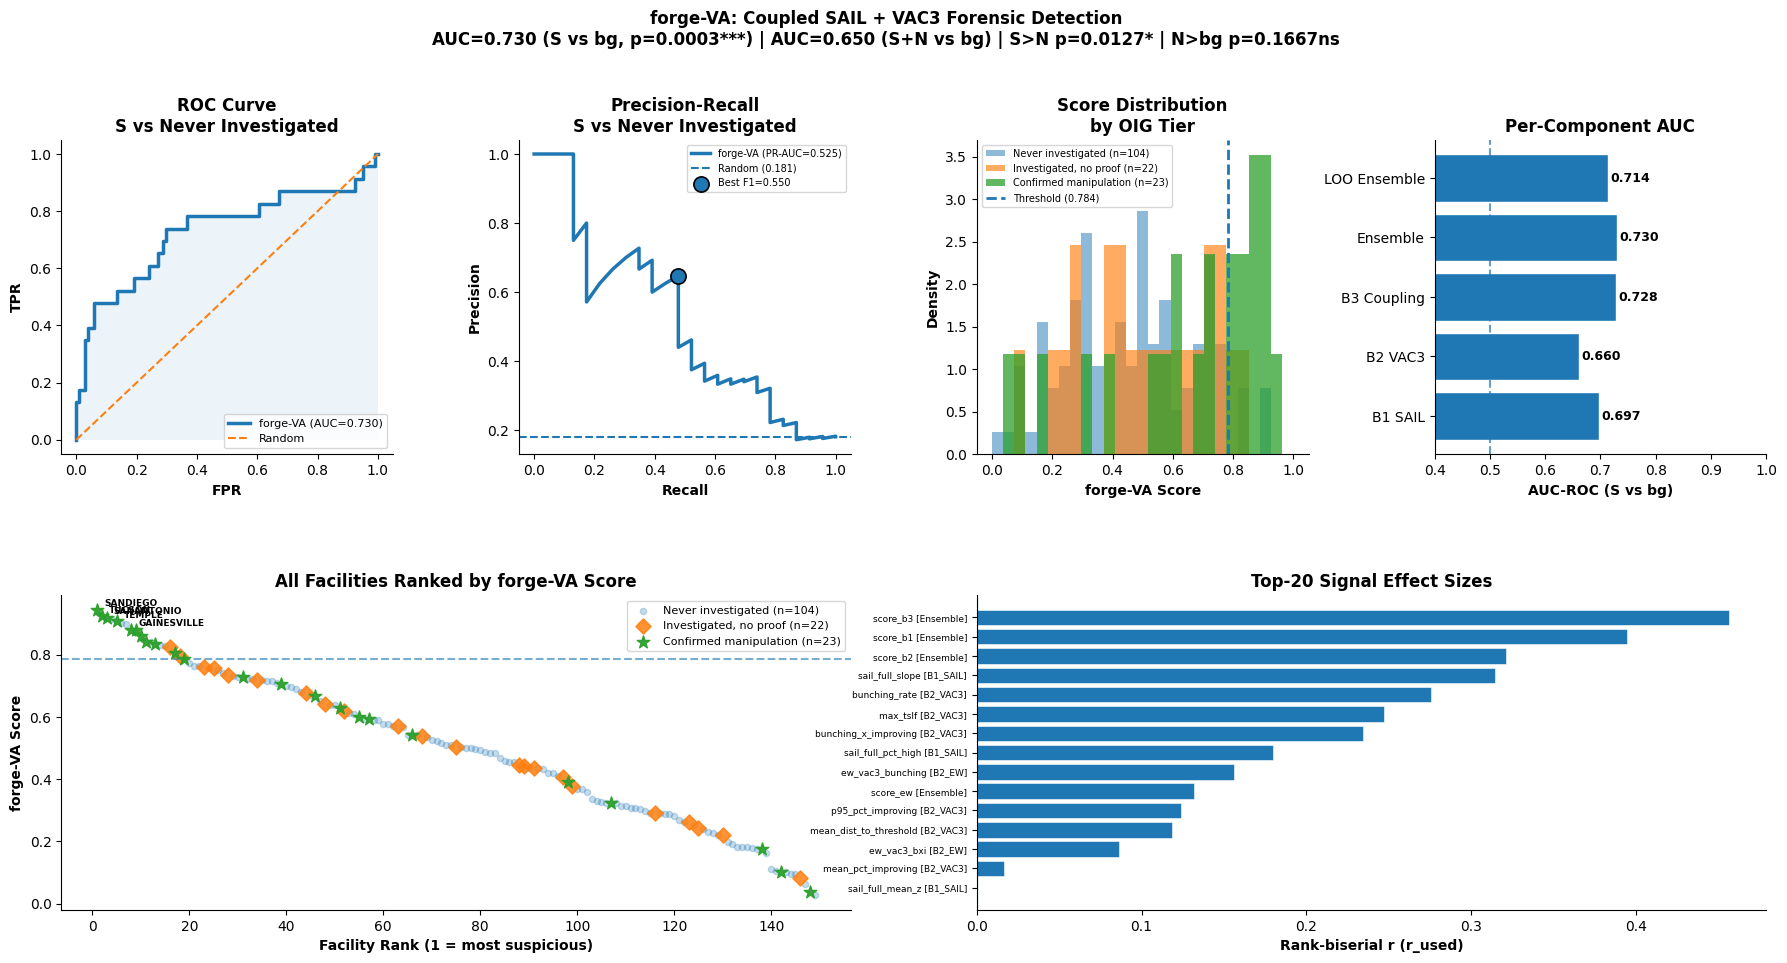

Figure saved -> /mnt/c/Users/lfult/OneDrive - bc.edu/VA_SAIL/forge_va_validation.png

Per-facility results:
Facility                 Tier   forge     LOO     B1     B2     B3  Rank  Result
------------------------------------------------------------------------------------------------
SANDIEGO                    S   0.944   0.840  0.906  0.747  0.830     1  CORRECT
TUCSON                      S   0.922   0.780  0.690  0.842  0.781     2  CORRECT
SANANTONIO                  S   0.918   0.804  0.837  0.778  0.845     3  CORRECT
TEMPLE                      S   0.906   0.776  0.839  0.715  0.741     5  CORRECT
GAINESVILLE                 S   0.879   0.726  0.694  0.757  0.712     8  CORRECT
NASHVILLE                   S   0.877   0.719  0.622  0.829  0.686     9  CORRECT
HOUSTON                     S   0.860   0.697  0.721  0.682  0.640    10  CORRECT
LOSANGELES                  S   0.841   0.711  0.890  0.650  0.654    11  CORRECT
PHILADELPHIA                S   0.833   0.661  0.591  0.74

In [5]:
# ============================================================================
# forge-VA: Coupled SAIL + VAC3 Forensic Detection Framework
# Clean final cell for SAIL_Extraction2.ipynb
#
# Requires prior ground-truth cell defining:
#   gt = adjudicated ground_truth_final.csv with columns:
#        sail_key, state, label, report_no, source, binary_label
#
# Label logic:
#   S     = investigated and substantiated / institutionally reinforced manipulation
#   N     = investigated and not substantiated
#   A     = investigated but ambiguous; omitted from binary validation
#   blank = not investigated; eligible for background
#
# Validation sets:
#   fraud_set = S facilities
#   n_set     = N facilities
#   a_set     = A facilities
#   bg_set    = panel facilities not in S, N, or A
# ============================================================================

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.stats import rankdata, mannwhitneyu, linregress
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
)
from rapidfuzz import process as rfprocess, fuzz

# ── 0. Paths ──────────────────────────────────────────────────────────────────

BASE_DIR     = Path(r"/mnt/c/Users/lfult/OneDrive - bc.edu/VA_SAIL")
BASE_OIG     = Path(r"/mnt/c/Users/lfult/OneDrive - bc.edu/va_analytics/oig_reports")
SAIL_MASTER  = BASE_DIR / "SAIL_FY15-FY24_Master.csv"
OUT_FAC      = BASE_DIR / "SAIL_anomaly_facility_summary_goodonly.csv"
OUT_REC      = BASE_DIR / "SAIL_anomaly_records_goodonly.csv"
OUT_VAL      = BASE_DIR / "forge_va_validation.csv"
OUT_FIG      = BASE_DIR / "forge_va_validation.png"

BASE_DIR.mkdir(parents=True, exist_ok=True)
BASE_OIG.mkdir(parents=True, exist_ok=True)

# ── 1. Helpers ────────────────────────────────────────────────────────────────

def rank_norm(s: pd.Series, direction: int = 1) -> pd.Series:
    """Rank-normalize to [0, 1]. direction=-1 flips before ranking."""
    x = pd.to_numeric(s, errors="coerce") * direction
    valid = x.notna()
    out = pd.Series(np.nan, index=s.index, dtype=float)
    if valid.sum() > 0:
        out.loc[valid] = rankdata(x.loc[valid], method="average") / valid.sum()
    return out


def effect_size_weight(s_vals, bg_vals):
    """Rank-biserial r for one-sided S > bg. Returns (r, p)."""
    s_vals = np.asarray(s_vals, dtype=float)
    bg_vals = np.asarray(bg_vals, dtype=float)
    s_vals = s_vals[np.isfinite(s_vals)]
    bg_vals = bg_vals[np.isfinite(bg_vals)]

    if len(s_vals) < 3 or len(bg_vals) < 3:
        return 0.0, 1.0

    U, p = mannwhitneyu(s_vals, bg_vals, alternative="greater")
    r = 2 * U / (len(s_vals) * len(bg_vals)) - 1
    return max(0.0, float(r)), float(p)


def sig(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"


def quick_auc(scores_series: pd.Series, fraud_set: set, bg_set: set) -> float:
    """AUC-ROC for a score column given fraud and background facility sets."""
    s = scores_series.dropna()
    mask_s = s.index.isin(fraud_set)
    mask_bg = s.index.isin(bg_set)

    if mask_s.sum() < 2 or mask_bg.sum() < 2:
        return np.nan

    y = np.array([1] * mask_s.sum() + [0] * mask_bg.sum())
    sc = np.concatenate([s.loc[mask_s].values, s.loc[mask_bg].values])
    return roc_auc_score(y, sc)


def ols_slope(values: np.ndarray) -> float:
    """OLS slope of finite values versus integer time index."""
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]

    if len(vals) < 3:
        return np.nan

    x = np.arange(len(vals), dtype=float)
    slope, *_ = linregress(x, vals)
    return float(slope)

# ── 2. Ground truth ───────────────────────────────────────────────────────────

assert "gt" in dir() and isinstance(gt, pd.DataFrame), (
    "gt not found. Run the FORGE-VA Ground Truth cell first."
)

required_gt_cols = {"sail_key", "state", "label"}
missing_gt_cols = required_gt_cols - set(gt.columns)
if missing_gt_cols:
    raise ValueError(f"Ground truth is missing required columns: {missing_gt_cols}")

gt = gt.copy()
gt["sail_key"] = gt["sail_key"].astype(str).str.upper().str.strip()
gt["state"] = gt["state"].astype(str).str.upper().str.strip()
gt["label"] = gt["label"].fillna("").astype(str).str.upper().str.strip()

if "report_no" not in gt.columns:
    gt["report_no"] = ""
if "source" not in gt.columns:
    gt["source"] = "revised"

gt["report_no"] = gt["report_no"].fillna("").astype(str).str.strip()
gt["source"] = gt["source"].fillna("revised").replace("", "revised")

valid_labels = {"S", "N", "A", ""}
bad_labels = sorted(set(gt["label"]) - valid_labels)
if bad_labels:
    raise ValueError(f"Unexpected labels in gt: {bad_labels}")

print(
    f"Ground truth: {len(gt)} entries  "
    f"(S={(gt.label == 'S').sum()}  "
    f"N={(gt.label == 'N').sum()}  "
    f"A={(gt.label == 'A').sum()}  "
    f"blank/uninvestigated={(gt.label == '').sum()})"
)

# ── 3. Load VAC3 facility summary ─────────────────────────────────────────────

try:
    _ = fac_summary
    print(f"\nUsing fac_summary in memory ({len(fac_summary)} facilities)")
    if OUT_FAC.exists():
        vac3 = pd.read_csv(OUT_FAC)
    else:
        vac3 = fac_summary.copy()
except NameError:
    print("\nLoading VAC3 summary from disk ...")
    vac3 = pd.read_csv(OUT_FAC)

if "Facility" not in vac3.columns:
    vac3 = vac3.rename(columns={"index": "Facility"})

if "Facility" not in vac3.columns:
    raise ValueError("VAC3 summary must contain a Facility column or index column.")

vac3["Facility"] = vac3["Facility"].astype(str).str.strip().str.upper()
master = vac3.set_index("Facility").copy()
master.index = master.index.astype(str).str.upper().str.strip()
print(f"Panel: {len(master)} facilities")

# ── 4. Robust match ground truth to SAIL panel ────────────────────────────────

sail_facs = master.index.astype(str).str.upper().str.strip().tolist()

KNOWN_NAME_FIXES = {
    "SANANTONIO": "SAN ANTONIO",
    "LOSANGELES": "LOS ANGELES",
    "COLUMBIASC": "COLUMBIA SC",
    "WASHINGTONDC": "WASHINGTON DC",
    "STLOUIS": "ST LOUIS",
    "MOUNTAINHOME": "MOUNTAIN HOME",
    "CENTRALIOWA": "CENTRAL IOWA",
    "LITTLEROCK": "LITTLE ROCK",
    "LAKECITY": "LAKE CITY",
    "WESTPALMBEACH": "WEST PALM BEACH",
    "PUGETSOUND": "PUGET SOUND",
    "NEWORLEANS": "NEW ORLEANS",
    "KANSASCITY": "KANSAS CITY",
    "GRANDJUNCTION": "GRAND JUNCTION",
    "BATTLECREEK": "BATTLE CREEK",
    "PALOALTO": "PALO ALTO",
    "SANJUAN": "SAN JUAN",
}

VA_STOPWORDS = [
    "VA MEDICAL CENTER",
    "VAMC",
    "VA HEALTH CARE SYSTEM",
    "VA HEALTHCARE SYSTEM",
    "HEALTH CARE SYSTEM",
    "HEALTHCARE SYSTEM",
    "VETERANS HEALTH CARE SYSTEM",
    "VETERANS HEALTHCARE SYSTEM",
    "VETERANS HOSPITAL",
    "MEMORIAL VETERANS HOSPITAL",
    "FEDERAL HEALTH CARE CENTER",
    "MEDICAL CENTER",
    "HOSPITAL",
    "SYSTEM",
    "VETERANS",
    "VA",
]


def normalize_facility_name(x):
    """Normalize VA facility names for safer matching."""
    s = str(x).upper().strip()
    s = KNOWN_NAME_FIXES.get(s, s)

    for token in VA_STOPWORDS:
        s = s.replace(token, " ")

    s = (
        s.replace(".", " ")
         .replace(",", " ")
         .replace("-", " ")
         .replace("/", " ")
         .replace("&", " AND ")
    )
    return " ".join(s.split())


candidate_lookup = pd.DataFrame({
    "candidate": sail_facs,
    "candidate_norm": [normalize_facility_name(c) for c in sail_facs],
})
candidate_norms = candidate_lookup["candidate_norm"].tolist()


def robust_facility_match(key, score_cutoff=80):
    """
    Match OIG / GT facility names to SAIL panel names.
    Strategy: exact normalized match, containment match, then RapidFuzz WRatio.
    """
    key_norm = normalize_facility_name(key)

    if not key_norm:
        return None, 0.0, "blank"

    exact = candidate_lookup[candidate_lookup["candidate_norm"] == key_norm]
    if len(exact) == 1:
        return exact.iloc[0]["candidate"], 100.0, "exact"

    contains = candidate_lookup[
        candidate_lookup["candidate_norm"].apply(lambda c: key_norm in c or c in key_norm)
    ]
    if len(contains) == 1:
        return contains.iloc[0]["candidate"], 95.0, "contains"

    matches = rfprocess.extract(key_norm, candidate_norms, scorer=fuzz.WRatio, limit=5)
    strong = [m for m in matches if m[1] >= score_cutoff]

    if not strong:
        return None, float(matches[0][1]) if matches else 0.0, "unmatched"

    best = min(strong, key=lambda m: abs(len(key_norm) - len(m[0])))
    matched_candidate = candidate_lookup.iloc[best[2]]["candidate"]
    return matched_candidate, float(best[1]), "fuzzy"


match_results = gt["sail_key"].apply(lambda k: robust_facility_match(k))

gt["matched"] = match_results.apply(lambda x: x[0])
gt["match_score"] = match_results.apply(lambda x: x[1])
gt["match_method"] = match_results.apply(lambda x: x[2])
gt["matched"] = gt["matched"].astype("string").str.upper().str.strip()

print("\nMatch audit (sorted by score; review low scores carefully):")
print(
    gt[["sail_key", "label", "matched", "match_score", "match_method"]]
    .sort_values(["match_score", "sail_key"])
    .to_string(index=False)
)

low_conf = gt[(gt["matched"].isna()) | (gt["match_score"] < 85)]
if len(low_conf) > 0:
    print("\nLOW-CONFIDENCE / UNMATCHED FACILITIES:")
    print(
        low_conf[["sail_key", "label", "matched", "match_score", "match_method"]]
        .to_string(index=False)
    )
else:
    print("\nAll GT facilities matched with score >= 85.")

dup_matches = (
    gt.dropna(subset=["matched"])
      .groupby("matched")
      .filter(lambda x: len(x) > 1)
      .sort_values("matched")
)

if len(dup_matches) > 0:
    print("\nDUPLICATE PANEL MATCHES. Inspect manually:")
    print(
        dup_matches[["sail_key", "label", "matched", "match_score", "match_method"]]
        .to_string(index=False)
    )

# ── 4b. Build validation sets ────────────────────────────────────────────────
# Only S/N/A are investigated. Blank labels remain eligible for background.

gt_labeled = gt[gt["label"].isin(["S", "N", "A"])].copy()

oig_matched = set(gt_labeled["matched"].dropna().astype(str).str.upper())
fraud_set = set(gt_labeled.loc[gt_labeled["label"] == "S", "matched"].dropna().astype(str).str.upper())
n_set = set(gt_labeled.loc[gt_labeled["label"] == "N", "matched"].dropna().astype(str).str.upper())
a_set = set(gt_labeled.loc[gt_labeled["label"] == "A", "matched"].dropna().astype(str).str.upper())

bg_set = set(master.index.astype(str).str.upper()) - oig_matched
sn_set = fraud_set | n_set

print(
    f"\nMatched — S:{len(fraud_set)}  N:{len(n_set)}  "
    f"A:{len(a_set)}  bg:{len(bg_set)}"
)
print(f"Unmatched: {gt.loc[gt.matched.isna(), 'sail_key'].tolist()}")

# ── 5. BLOCK 1: SAIL raw access signal ───────────────────────────────────────

ACCESS_CATS = {
    "ED Throughput",
    "Hospital Flow",
    "Length of Stay",
    "Care Transitions",
    "Patient Experience",
    "Outpatient Performance Measures",
    "Prevention Composite",
    "Efficiency & Capacity",
}

EARLY_FY = {"FY15", "FY16"}


def compute_sail_block(sail_df: pd.DataFrame, label: str = "full") -> pd.DataFrame:
    """Return facility-indexed SAIL access signal features."""
    sail_df = sail_df.copy()

    dir_map = {
        "Ascending": -1,
        "ascending": -1,
        "Descending": +1,
        "descending": +1,
        "Higher": +1,
        "Lower": -1,
        "higher is better": +1,
        "lower is better": -1,
    }

    sail_df["dir_sign"] = sail_df.get(
        "Direction", pd.Series("Descending", index=sail_df.index)
    ).map(dir_map).fillna(1).astype(int)

    score_col = "Score"
    grp = sail_df.groupby(["Measure_canon", "FY", "Quarter"], dropna=False)
    sail_df["Z_cohort"] = grp[score_col].transform(
        lambda x: (x - x.mean()) / (x.std(ddof=1) + 1e-9)
    )

    # High adjusted score = suspiciously good performance relative to national cohort.
    sail_df["Z_adj"] = sail_df["Z_cohort"] * sail_df["dir_sign"]

    fy_int = pd.to_numeric(
        sail_df["FY"].astype(str).str.extract(r"FY(\d{2,4})", expand=False),
        errors="coerce",
    ).apply(lambda x: 2000 + x if pd.notna(x) and x < 100 else x)

    q_int = pd.to_numeric(
        sail_df["Quarter"].astype(str).str.extract(r"Q(\d)", expand=False),
        errors="coerce",
    )

    sail_df["time_ord"] = (fy_int - fy_int.min()) * 4 + (q_int - 1)

    rows = {}
    for fac, grp_f in sail_df.groupby("Facility", dropna=False):
        z = grp_f["Z_adj"].dropna().values
        if len(z) < 3:
            continue

        grp_t = grp_f.sort_values("time_ord")
        z_t = grp_t["Z_adj"].dropna().values

        rows[fac] = {
            f"sail_{label}_mean_z": float(np.nanmean(z)),
            f"sail_{label}_p90_z": float(np.nanpercentile(z, 90)),
            f"sail_{label}_pct_high": float((z > 1.645).mean()),
            f"sail_{label}_slope": ols_slope(z_t),
        }

    return pd.DataFrame.from_dict(rows, orient="index")


if SAIL_MASTER.exists():
    print(f"\nLoading SAIL master: {SAIL_MASTER} ...")
    sail_raw = pd.read_csv(
        SAIL_MASTER,
        dtype={"FY": "str", "Quarter": "str", "VISN": "str"},
        low_memory=False,
    )

    sail_raw["Facility"] = sail_raw["Facility"].astype(str).str.strip().str.upper()

    if "Measure_canon" not in sail_raw.columns:
        sail_raw["Measure_canon"] = sail_raw.get("Measure", "Unknown")
    if "Category_canon" not in sail_raw.columns:
        sail_raw["Category_canon"] = sail_raw.get("Category", "Unknown")
    if "Score" not in sail_raw.columns and "score" in sail_raw.columns:
        sail_raw = sail_raw.rename(columns={"score": "Score"})

    sail_raw["Score"] = pd.to_numeric(sail_raw["Score"], errors="coerce")

    # Restrict Block 1 to gaming-susceptible access/performance domains.
    access_mask = sail_raw["Category_canon"].isin(ACCESS_CATS)
    sail_access = sail_raw[access_mask].copy()

    print(
        f"  Access/scheduling rows: {len(sail_access):,}  "
        f"({sail_access.Facility.nunique()} facilities, "
        f"{sail_access.Measure_canon.nunique()} measures)"
    )

    b1_full = compute_sail_block(sail_access, "full")
    sail_early = sail_access[sail_access["FY"].isin(EARLY_FY)]
    b1_early = compute_sail_block(sail_early, "early")

    print(f"  Block 1 full:  {len(b1_full)} facilities")
    print(f"  Block 1 early: {len(b1_early)} facilities (FY15-FY16)")

    stale_sail = [c for c in master.columns if c.startswith("sail_")]
    if stale_sail:
        master = master.drop(columns=stale_sail)

    master = master.join(b1_full, how="left")
    master = master.join(b1_early, how="left")
    has_block1 = True
else:
    print(f"\n[WARN] SAIL master not found at {SAIL_MASTER}")
    print("       Block 1 will be skipped. Block 2 plus fallback coupling only.")
    has_block1 = False

# ── 6. BLOCK 2: VAC3 behavioral signal ──────────────────────────────────────

VAC3_SIGNALS = {
    "pct_flagged_good": +1,
    "bunching_rate": +1,
    "mean_pct_improving": +1,
    "p95_pct_improving": +1,
    "mean_anom": +1,
    "p95_anom": +1,
    "mean_mahalanobis": +1,
    "p95_mahalanobis": +1,
    "mean_goodz_weighted": +1,
    "mean_z_consistency_sd": +1,
    "max_good_flag_streak": +1,
    "max_tslf": +1,
    "mean_dist_to_threshold": -1,
    "sd_pct_improving": -1,
}

if "bunching_rate" in master.columns and "mean_pct_improving" in master.columns:
    master["bunching_x_improving"] = (
        master["bunching_rate"].fillna(0) * master["mean_pct_improving"].fillna(0)
    )
    VAC3_SIGNALS["bunching_x_improving"] = +1

if OUT_REC.exists():
    print("\nLoading VAC3 records for early window ...")
    rec_cols = [
        "Facility",
        "FY",
        "IF_anomaly_score",
        "IF_good_flag",
        "Is_Bunched",
        "Pct_Measures_Improving",
        "Mahalanobis_D",
        "GoodZ_Weighted",
        "Facility_Consistency_SD",
        "TSLF",
        "Min_Dist_to_Threshold",
    ]

    rec = pd.read_csv(OUT_REC, usecols=lambda c: c in rec_cols, dtype={"FY": "str"})
    rec["Facility"] = rec["Facility"].astype(str).str.strip().str.upper()
    ew_rec = rec[rec["FY"].isin(EARLY_FY)]

    ew_agg = ew_rec.groupby("Facility").agg(
        ew_vac3_pct_good=("IF_good_flag", "mean"),
        ew_vac3_bunching=("Is_Bunched", "mean"),
        ew_vac3_improving=("Pct_Measures_Improving", "mean"),
        ew_vac3_mahalanobis=("Mahalanobis_D", "mean"),
        ew_vac3_goodz=("GoodZ_Weighted", "mean"),
        ew_vac3_anom=("IF_anomaly_score", "mean"),
    )

    ew_agg["ew_vac3_bxi"] = (
        ew_agg["ew_vac3_bunching"].fillna(0) * ew_agg["ew_vac3_improving"].fillna(0)
    )

    stale_ew = [c for c in master.columns if c.startswith("ew_vac3_")]
    if stale_ew:
        master = master.drop(columns=stale_ew)

    master = master.join(ew_agg, how="left")
    EW_VAC3 = {c: +1 for c in ew_agg.columns}
    print(f"  Early-window VAC3: {ew_agg.notna().any(axis=1).sum()} facilities")
else:
    EW_VAC3 = {}
    print("\n[INFO] OUT_REC not found. No early-window VAC3.")

# ── 6b. Dual-framing weight estimation ───────────────────────────────────────
# Each signal is evaluated under:
#   S vs bg
#   S+N vs bg
# Use S+N only when it improves effect size and is not merely an N-vs-bg proxy.


def build_weighted_score_dual(
    df: pd.DataFrame,
    signals: dict,
    fraud_set: set,
    n_set: set,
    bg_set: set,
    label: str,
) -> tuple[pd.Series, pd.DataFrame]:
    """Dual-framing effect-size-weighted score."""
    sn_set = fraud_set | n_set
    eff_rows = []
    w_sum = pd.Series(0.0, index=df.index)
    w_tot = pd.Series(0.0, index=df.index)

    for col, direction in signals.items():
        if col not in df.columns:
            continue

        s_v = df.loc[df.index.isin(fraud_set), col].dropna().values * direction
        n_v = df.loc[df.index.isin(n_set), col].dropna().values * direction
        sn_v = df.loc[df.index.isin(sn_set), col].dropna().values * direction
        bg_v = df.loc[df.index.isin(bg_set), col].dropna().values * direction

        r_s, p_s = effect_size_weight(s_v, bg_v)
        r_sn, p_sn = effect_size_weight(sn_v, bg_v)
        r_n_bg, p_n_bg = effect_size_weight(n_v, bg_v)

        use_sn = (r_sn > r_s) and (r_n_bg < r_s)
        r_used = r_sn if use_sn else r_s
        p_used = p_sn if use_sn else p_s
        framing = "S+N" if use_sn else "S"

        eff_rows.append({
            "block": label,
            "signal": col,
            "r_s": round(r_s, 4),
            "p_s": round(p_s, 4),
            "r_sn": round(r_sn, 4),
            "p_sn": round(p_sn, 4),
            "r_n_bg": round(r_n_bg, 4),
            "p_n_bg": round(p_n_bg, 4),
            "r_used": round(r_used, 4),
            "p_used": round(p_used, 4),
            "framing_used": framing,
        })

        if r_used <= 0:
            continue

        rn = rank_norm(df[col], direction)
        valid = rn.notna()
        w_sum.loc[valid] += rn.loc[valid] * r_used
        w_tot.loc[valid] += r_used

    score = w_sum / w_tot.replace(0, np.nan)
    return score, pd.DataFrame(eff_rows)


master["score_b2"], eff_b2 = build_weighted_score_dual(
    master, VAC3_SIGNALS, fraud_set, n_set, bg_set, "B2_VAC3"
)

# ── 7. BLOCK 1 score ─────────────────────────────────────────────────────────

if has_block1:
    B1_SIGNALS = {
        c: +1 for c in master.columns
        if c.startswith("sail_full_") or c.startswith("sail_early_")
    }
    master["score_b1"], eff_b1 = build_weighted_score_dual(
        master, B1_SIGNALS, fraud_set, n_set, bg_set, "B1_SAIL"
    )
    eff_all = pd.concat([eff_b1, eff_b2], ignore_index=True)
else:
    master["score_b1"] = np.nan
    eff_all = eff_b2.copy()

# ── 8. Early-window VAC3 score ───────────────────────────────────────────────

if EW_VAC3:
    master["score_ew"], eff_ew = build_weighted_score_dual(
        master, EW_VAC3, fraud_set, n_set, bg_set, "B2_EW"
    )
    eff_all = pd.concat([eff_all, eff_ew], ignore_index=True)
else:
    master["score_ew"] = np.nan

# ── 9. BLOCK 3: Coupling term ────────────────────────────────────────────────

b1_rn = rank_norm(master["score_b1"])
b2_rn = rank_norm(master["score_b2"])

if has_block1 and b1_rn.notna().sum() > 10:
    # Absence or weakness of SAIL signal is not exculpatory, so apply floor.
    b1_rn_floored = b1_rn.fillna(0.25).clip(lower=0.25)
    master["score_b3"] = b1_rn_floored * b2_rn
    print(
        f"\nCoupling term (Block 3) computed for "
        f"{master['score_b3'].notna().sum()} facilities"
    )
    print(f"  B1 floor applied: {(b1_rn < 0.25).sum()} facilities lifted to floor")
else:
    master["score_b3"] = rank_norm(master["score_ew"]) * b2_rn
    print("\nCoupling term: early-window VAC3 × full-panel VAC3")

# ── 10. forge-VA ensemble ───────────────────────────────────────────────────

ensemble_signals = {"score_b1": +1, "score_b2": +1, "score_b3": +1}
if EW_VAC3 and master["score_ew"].notna().sum() > 10:
    ensemble_signals["score_ew"] = +1

master["forge_va"], eff_ens = build_weighted_score_dual(
    master, ensemble_signals, fraud_set, n_set, bg_set, "Ensemble"
)
master["forge_rank"] = master["forge_va"].rank(
    ascending=False, method="min", na_option="bottom"
).astype(int)

eff_all = pd.concat([eff_all, eff_ens], ignore_index=True)

print(f"\nforge-VA ensemble score built for {master['forge_va'].notna().sum()} facilities")

# ── 10b. Framing audit ───────────────────────────────────────────────────────

print(f"\n{'=' * 72}")
print("  Dual-framing signal audit")
print(f"{'=' * 72}")
print(f"  {'Signal':<38} {'Block':<10} {'r_s':>6} {'r_sn':>6} {'r_n_bg':>7} {'Used':>5} {'Framing'}")
print(f"  {'-' * 68}")

switched = []
if not eff_all.empty:
    for _, row in eff_all.sort_values(["block", "signal"]).iterrows():
        framing_flag = " <-- switched" if row["framing_used"] == "S+N" else ""
        print(
            f"  {row['signal']:<38} {row['block']:<10} "
            f"{row['r_s']:>6.3f} {row['r_sn']:>6.3f} "
            f"{row['r_n_bg']:>7.3f} {row['r_used']:>5.3f}  "
            f"{row['framing_used']}{framing_flag}"
        )
        if row["framing_used"] == "S+N":
            switched.append(row["signal"])

print(f"\n  Signals that switched to S+N framing ({len(switched)}): {switched if switched else 'none'}")
print(f"{'=' * 72}")

# ── 10c. LOO ensemble score ─────────────────────────────────────────────────


def compute_ensemble_weights(df: pd.DataFrame, signal_cols: list, fraud_set: set, bg_set: set) -> dict:
    """Compute rank-biserial r for each ensemble block score column."""
    weights = {}

    for col in signal_cols:
        if col not in df.columns:
            continue

        s_v = df.loc[df.index.isin(fraud_set), col].dropna().values
        bg_v = df.loc[df.index.isin(bg_set), col].dropna().values

        if len(s_v) < 3 or len(bg_v) < 3:
            weights[col] = 0.0
            continue

        U, _ = mannwhitneyu(s_v, bg_v, alternative="greater")
        r = 2 * U / (len(s_v) * len(bg_v)) - 1
        weights[col] = max(0.0, float(r))

    return weights


def weighted_ensemble(df: pd.DataFrame, signal_cols: list, weights: dict) -> pd.Series:
    """Weighted average of signal columns using provided weights."""
    w_sum = pd.Series(0.0, index=df.index)
    w_tot = pd.Series(0.0, index=df.index)

    for col in signal_cols:
        r = weights.get(col, 0.0)
        if r <= 0 or col not in df.columns:
            continue

        valid = df[col].notna()
        w_sum.loc[valid] += df.loc[valid, col] * r
        w_tot.loc[valid] += r

    return w_sum / w_tot.replace(0, np.nan)


print("\nComputing LOO ensemble scores...")

ENS_COLS = ["score_b1", "score_b2", "score_b3"]
if "score_ew" in master.columns and master["score_ew"].notna().sum() > 10:
    ENS_COLS.append("score_ew")

loo_scores = pd.Series(np.nan, index=master.index)

for fac in master.index:
    train_idx = master.index[master.index != fac]
    train_df = master.loc[train_idx]
    train_fraud = fraud_set - {fac}
    train_bg = bg_set - {fac}

    if len(train_fraud) < 3 or len(train_bg) < 3:
        w = compute_ensemble_weights(master, ENS_COLS, fraud_set, bg_set)
    else:
        w = compute_ensemble_weights(train_df, ENS_COLS, train_fraud, train_bg)

    if sum(w.values()) == 0:
        continue

    loo_scores.loc[fac] = weighted_ensemble(master.loc[[fac]], ENS_COLS, w).iloc[0]

master["forge_va_loo"] = loo_scores
master["forge_loo_rank"] = master["forge_va_loo"].rank(
    ascending=False, method="min", na_option="bottom"
).astype(int)

print(f"  LOO scores computed for {loo_scores.notna().sum()} facilities")

_s_loo = loo_scores.loc[loo_scores.index.isin(fraud_set)].dropna()
_bg_loo = loo_scores.loc[loo_scores.index.isin(bg_set)].dropna()
if len(_s_loo) >= 2 and len(_bg_loo) >= 2:
    _y = np.array([1] * len(_s_loo) + [0] * len(_bg_loo))
    _sc = np.concatenate([_s_loo.values, _bg_loo.values])
    auc_loo = roc_auc_score(_y, _sc)
    print(f"  LOO AUC (S vs bg): {auc_loo:.4f}")
else:
    auc_loo = np.nan
    print("  LOO AUC: insufficient data")

# ── 11. Evaluation ───────────────────────────────────────────────────────────

fraud_scores = master.loc[master.index.isin(fraud_set), "forge_va"].dropna()
n_scores = master.loc[master.index.isin(n_set), "forge_va"].dropna()
bg_scores_s = master.loc[master.index.isin(bg_set), "forge_va"].dropna()
sn_scores = master.loc[master.index.isin(sn_set), "forge_va"].dropna()

if len(fraud_scores) < 2 or len(bg_scores_s) < 2:
    raise ValueError("Insufficient S or background facilities for ROC evaluation.")

y_sb = np.array([1] * len(fraud_scores) + [0] * len(bg_scores_s))
sc_sb = np.concatenate([fraud_scores.values, bg_scores_s.values])
auc_sb = roc_auc_score(y_sb, sc_sb)
apr_sb = average_precision_score(y_sb, sc_sb)

if len(sn_scores) >= 2 and len(bg_scores_s) >= 2:
    y_snb = np.array([1] * len(sn_scores) + [0] * len(bg_scores_s))
    sc_snb = np.concatenate([sn_scores.values, bg_scores_s.values])
    auc_snb = roc_auc_score(y_snb, sc_snb)
else:
    y_snb, sc_snb, auc_snb = np.array([]), np.array([]), np.nan

fpr, tpr, roc_thr = roc_curve(y_sb, sc_sb)
prec, rec, pr_thr = precision_recall_curve(y_sb, sc_sb)
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
best = int(np.argmax(f1s))
best_thresh = float(pr_thr[best])
y_pred = (sc_sb >= best_thresh).astype(int)
cm = confusion_matrix(y_sb, y_pred)
tn, fp, fn, tp = cm.ravel()

_, p_sb = mannwhitneyu(fraud_scores.values, bg_scores_s.values, alternative="greater")
_, p_sn = mannwhitneyu(fraud_scores.values, n_scores.values, alternative="greater") if len(n_scores) >= 3 else (np.nan, np.nan)
_, p_nb = mannwhitneyu(n_scores.values, bg_scores_s.values, alternative="greater") if len(n_scores) >= 3 else (np.nan, np.nan)
_, p_snb = mannwhitneyu(sn_scores.values, bg_scores_s.values, alternative="greater") if len(sn_scores) >= 3 else (np.nan, np.nan)

block_aucs = {}
for col, block_label in [
    ("score_b1", "B1 SAIL"),
    ("score_b2", "B2 VAC3"),
    ("score_b3", "B3 Coupling"),
    ("forge_va", "Ensemble"),
    ("forge_va_loo", "LOO Ensemble"),
]:
    if col in master.columns:
        a = quick_auc(master[col], fraud_set, bg_set)
        block_aucs[block_label] = round(a, 4) if not np.isnan(a) else "N/A"

print(f"\n{'=' * 62}")
print(f"  forge-VA — Confirmed Fraud (S={len(fraud_scores)}) vs Background (bg={len(bg_scores_s)})")
print(f"{'=' * 62}")
print(f"  {'Component':<18} {'AUC-ROC':>8}")
print(f"  {'-' * 28}")
for k, v in block_aucs.items():
    marker = "  <-- primary" if k == "LOO Ensemble" else "  <-- in-sample" if k == "Ensemble" else ""
    print(f"  {k:<18} {str(v):>8}{marker}")

print(f"\n  PR-AUC  (S vs bg)   : {apr_sb:.4f}")
print(f"  AUC-ROC (S+N vs bg) : {auc_snb:.4f}  (investigation-worthy framing)")
print(f"  Best F1             : {f1s[best]:.4f}  (threshold={best_thresh:.4f})")
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print("\n  Wilcoxon rank-sum (H1: row > col):")
print(f"  S    > bg   : p={p_sb:.4f}  {sig(p_sb)}")
print(f"  S    > N    : p={p_sn:.4f}  {sig(p_sn) if not np.isnan(p_sn) else 'N/A'}")
print(f"  S+N  > bg   : p={p_snb:.4f}  {sig(p_snb) if not np.isnan(p_snb) else 'N/A'}")
print(f"  N    > bg   : p={p_nb:.4f}  {sig(p_nb) if not np.isnan(p_nb) else 'N/A'}  <- selection bias test")
if not np.isnan(p_nb) and p_nb < 0.10:
    print("  [NOTE] N > bg is significant at p < 0.10. Interpret S+N framing cautiously.")
print(f"{'=' * 62}")
print(classification_report(y_sb, y_pred, target_names=["Background", "Confirmed Fraud"]))

# ── 12. Bootstrap CIs ────────────────────────────────────────────────────────

print("\nBootstrapping CIs (2000 resamples)...")

N_BOOT = 2000
RNG = np.random.default_rng(42)
CI_LEVEL = 0.95
alpha = 1 - CI_LEVEL

eval_df = master.loc[
    master.index.isin(fraud_set | bg_set),
    ["forge_va", "forge_va_loo"],
].copy()
eval_df["label"] = eval_df.index.isin(fraud_set).astype(int)
eval_df = eval_df.dropna(subset=["forge_va"])

fac_idx = eval_df.index.values
labels = eval_df["label"].values
scores_is = eval_df["forge_va"].values
scores_loo = eval_df["forge_va_loo"].fillna(eval_df["forge_va"]).values

boot_auc_is = []
boot_auc_loo = []
boot_apr_is = []

for _ in range(N_BOOT):
    idx = RNG.integers(0, len(fac_idx), size=len(fac_idx))
    y_b = labels[idx]
    if y_b.sum() < 2 or (1 - y_b).sum() < 2:
        continue

    boot_auc_is.append(roc_auc_score(y_b, scores_is[idx]))
    boot_auc_loo.append(roc_auc_score(y_b, scores_loo[idx]))
    boot_apr_is.append(average_precision_score(y_b, scores_is[idx]))

boot_auc_is = np.asarray(boot_auc_is)
boot_auc_loo = np.asarray(boot_auc_loo)
boot_apr_is = np.asarray(boot_apr_is)

ci_auc_is = (np.quantile(boot_auc_is, alpha / 2), np.quantile(boot_auc_is, 1 - alpha / 2))
ci_auc_loo = (np.quantile(boot_auc_loo, alpha / 2), np.quantile(boot_auc_loo, 1 - alpha / 2))
ci_apr_is = (np.quantile(boot_apr_is, alpha / 2), np.quantile(boot_apr_is, 1 - alpha / 2))

bootstrap_results = {
    "auc_insample": float(np.mean(boot_auc_is)),
    "auc_insample_lo": float(ci_auc_is[0]),
    "auc_insample_hi": float(ci_auc_is[1]),
    "auc_loo": float(np.mean(boot_auc_loo)),
    "auc_loo_lo": float(ci_auc_loo[0]),
    "auc_loo_hi": float(ci_auc_loo[1]),
    "prauc_insample": float(np.mean(boot_apr_is)),
    "prauc_insample_lo": float(ci_apr_is[0]),
    "prauc_insample_hi": float(ci_apr_is[1]),
    "n_boot": N_BOOT,
    "n_valid_resamples": int(len(boot_auc_is)),
}

print(f"\n{'=' * 62}")
print(f"  Bootstrap Results ({N_BOOT} resamples, {CI_LEVEL * 100:.0f}% CI)")
print(f"{'=' * 62}")
print(f"  AUC-ROC in-sample  : {bootstrap_results['auc_insample']:.4f}  ({ci_auc_is[0]:.3f}-{ci_auc_is[1]:.3f})")
print(f"  AUC-ROC LOO        : {bootstrap_results['auc_loo']:.4f}  ({ci_auc_loo[0]:.3f}-{ci_auc_loo[1]:.3f})")
print(f"  PR-AUC in-sample   : {bootstrap_results['prauc_insample']:.4f}  ({ci_apr_is[0]:.3f}-{ci_apr_is[1]:.3f})")
print(f"{'=' * 62}")

# ── 13. ROC coordinates for LaTeX figure ────────────────────────────────────

print("\nActual ROC coordinates for LaTeX figure:")
print("\\addplot[very thick, red, const plot] coordinates {")

fpr_curve, tpr_curve, _ = roc_curve(labels, scores_is)
keep = [0]
for i in range(1, len(fpr_curve)):
    if abs(fpr_curve[i] - fpr_curve[keep[-1]]) > 0.04 or abs(tpr_curve[i] - tpr_curve[keep[-1]]) > 0.04:
        keep.append(i)
if keep[-1] != len(fpr_curve) - 1:
    keep.append(len(fpr_curve) - 1)

for i in keep:
    print(f"    ({fpr_curve[i]:.4f},{tpr_curve[i]:.4f})")
print("};")

roc_coords = {
    "fpr": fpr_curve[keep].tolist(),
    "tpr": tpr_curve[keep].tolist(),
}

# ── 14. Plots ────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(22, 10))
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.38)

# Panel A: ROC
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(fpr, tpr, lw=2.5, label=f"forge-VA (AUC={auc_sb:.3f})")
ax1.plot([0, 1], [0, 1], "--", lw=1.5, label="Random")
ax1.fill_between(fpr, tpr, alpha=0.08)
ax1.set_xlabel("FPR", fontweight="bold")
ax1.set_ylabel("TPR", fontweight="bold")
ax1.set_title("ROC Curve\nS vs Never Investigated", fontweight="bold")
ax1.legend(loc="lower right", fontsize=8)
ax1.spines[["top", "right"]].set_visible(False)

# Panel B: PR curve
ax2 = fig.add_subplot(gs[0, 1])
base_rate = len(fraud_scores) / len(sc_sb)
ax2.plot(rec, prec, lw=2.5, label=f"forge-VA (PR-AUC={apr_sb:.3f})")
ax2.axhline(base_rate, ls="--", lw=1.5, label=f"Random ({base_rate:.3f})")
ax2.scatter(rec[best], prec[best], s=120, zorder=5, edgecolors="black", lw=1.2, label=f"Best F1={f1s[best]:.3f}")
ax2.set_xlabel("Recall", fontweight="bold")
ax2.set_ylabel("Precision", fontweight="bold")
ax2.set_title("Precision-Recall\nS vs Never Investigated", fontweight="bold")
ax2.legend(fontsize=7)
ax2.spines[["top", "right"]].set_visible(False)

# Panel C: Score distribution
ax3 = fig.add_subplot(gs[0, 2])
bins = np.linspace(0, 1, 28)
ax3.hist(bg_scores_s.values, bins=bins, alpha=0.50, density=True, label=f"Never investigated (n={len(bg_scores_s)})")
ax3.hist(n_scores.values, bins=bins, alpha=0.65, density=True, label=f"Investigated, no proof (n={len(n_scores)})")
ax3.hist(fraud_scores.values, bins=bins, alpha=0.75, density=True, label=f"Confirmed manipulation (n={len(fraud_scores)})")
ax3.axvline(best_thresh, ls="--", lw=2, label=f"Threshold ({best_thresh:.3f})")
ax3.set_xlabel("forge-VA Score", fontweight="bold")
ax3.set_ylabel("Density", fontweight="bold")
ax3.set_title("Score Distribution\nby OIG Tier", fontweight="bold")
ax3.legend(fontsize=7)
ax3.spines[["top", "right"]].set_visible(False)

# Panel D: Per-block AUC
ax4 = fig.add_subplot(gs[0, 3])
labels_auc = list(block_aucs.keys())
vals_auc = [v if isinstance(v, float) else 0.5 for v in block_aucs.values()]
bars = ax4.barh(labels_auc, vals_auc, edgecolor="white")
ax4.axvline(0.5, ls="--", lw=1.5, alpha=0.7)
for bar, val in zip(bars, vals_auc):
    ax4.text(val + 0.005, bar.get_y() + bar.get_height() / 2, f"{val:.3f}", va="center", fontsize=9, fontweight="bold")
ax4.set_xlabel("AUC-ROC (S vs bg)", fontweight="bold")
ax4.set_title("Per-Component AUC", fontweight="bold")
ax4.set_xlim(0.4, 1.0)
ax4.spines[["top", "right"]].set_visible(False)

# Panel E: Ranked scatter
ax5 = fig.add_subplot(gs[1, 0:2])
ax5.scatter(master.loc[master.index.isin(bg_set), "forge_rank"], master.loc[master.index.isin(bg_set), "forge_va"], alpha=0.25, s=20, zorder=1, label=f"Never investigated (n={len(bg_set)})")
ax5.scatter(master.loc[master.index.isin(n_set), "forge_rank"], master.loc[master.index.isin(n_set), "forge_va"], alpha=0.85, s=60, zorder=2, marker="D", label=f"Investigated, no proof (n={len(n_set)})")
ax5.scatter(master.loc[master.index.isin(fraud_set), "forge_rank"], master.loc[master.index.isin(fraud_set), "forge_va"], alpha=0.95, s=90, zorder=3, marker="*", label=f"Confirmed manipulation (n={len(fraud_set)})")
ax5.axhline(best_thresh, ls="--", lw=1.5, alpha=0.6)

top_fraud = master.loc[master.index.isin(fraud_set)].nsmallest(5, "forge_rank")
for fac, row in top_fraud.iterrows():
    ax5.annotate(fac, (row.forge_rank, row.forge_va), textcoords="offset points", xytext=(5, 3), fontsize=6.5, fontweight="bold")

ax5.set_xlabel("Facility Rank (1 = most suspicious)", fontweight="bold")
ax5.set_ylabel("forge-VA Score", fontweight="bold")
ax5.set_title("All Facilities Ranked by forge-VA Score", fontweight="bold")
ax5.legend(fontsize=8)
ax5.spines[["top", "right"]].set_visible(False)

# Panel F: Top signal effect sizes
ax6 = fig.add_subplot(gs[1, 2:4])
top_eff = eff_all[eff_all["r_used"] > 0].sort_values("r_used", ascending=True).tail(20)
if len(top_eff) > 0:
    ax6.barh(top_eff["signal"] + " [" + top_eff["block"] + "]", top_eff["r_used"], edgecolor="white", lw=0.4)
ax6.axvline(0, lw=0.8)
ax6.set_xlabel("Rank-biserial r (r_used)", fontweight="bold")
ax6.set_title("Top-20 Signal Effect Sizes", fontweight="bold")
ax6.tick_params(axis="y", labelsize=6.5)
ax6.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    f"forge-VA: Coupled SAIL + VAC3 Forensic Detection\n"
    f"AUC={auc_sb:.3f} (S vs bg, p={p_sb:.4f}{sig(p_sb)}) | "
    f"AUC={auc_snb:.3f} (S+N vs bg) | "
    f"S>N p={p_sn:.4f}{sig(p_sn) if not np.isnan(p_sn) else 'N/A'} | "
    f"N>bg p={p_nb:.4f}{sig(p_nb) if not np.isnan(p_nb) else 'N/A'}",
    fontsize=12,
    fontweight="bold",
    y=1.01,
)

plt.savefig(OUT_FIG, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved -> {OUT_FIG}")

# ── 15. Per-facility results table ──────────────────────────────────────────

all_tiers = gt_labeled.dropna(subset=["matched"]).copy()
all_tiers["forge_va"] = all_tiers["matched"].map(master["forge_va"])
all_tiers["forge_va_loo"] = all_tiers["matched"].map(master["forge_va_loo"])
all_tiers["forge_rank"] = all_tiers["matched"].map(master["forge_rank"])
all_tiers["forge_loo_rank"] = all_tiers["matched"].map(master["forge_loo_rank"])
all_tiers["score_b1"] = all_tiers["matched"].map(master["score_b1"])
all_tiers["score_b2"] = all_tiers["matched"].map(master["score_b2"])
all_tiers["score_b3"] = all_tiers["matched"].map(master["score_b3"])
all_tiers["predicted"] = np.where(all_tiers["forge_va"] >= best_thresh, "Fraud", "Clean")
all_tiers = all_tiers.sort_values("forge_va", ascending=False)

print("\nPer-facility results:")
print(f"{'Facility':<24} {'Tier':>4} {'forge':>7} {'LOO':>7} {'B1':>6} {'B2':>6} {'B3':>6} {'Rank':>5}  Result")
print("-" * 96)

for _, r in all_tiers.iterrows():
    result = (
        "CORRECT" if r.label == "S" and r.predicted == "Fraud"
        else "MISSED" if r.label == "S" and r.predicted == "Clean"
        else "sel.bias" if r.label == "N"
        else "ambig"
    )

    b1 = f"{r.score_b1:.3f}" if pd.notna(r.score_b1) else "N/A"
    b2 = f"{r.score_b2:.3f}" if pd.notna(r.score_b2) else "N/A"
    b3 = f"{r.score_b3:.3f}" if pd.notna(r.score_b3) else "N/A"
    fv = f"{r.forge_va:.3f}" if pd.notna(r.forge_va) else "N/A"
    fl = f"{r.forge_va_loo:.3f}" if pd.notna(r.forge_va_loo) else "N/A"
    rk = int(r.forge_rank) if pd.notna(r.forge_rank) else -1

    print(f"{r.sail_key:<24} {r.label:>4} {fv:>7} {fl:>7} {b1:>6} {b2:>6} {b3:>6} {rk:>5}  {result}")

# ── 16. Save validation outputs ──────────────────────────────────────────────

validation_cols = [
    "sail_key",
    "state",
    "label",
    "report_no",
    "source",
    "matched",
    "match_score",
    "match_method",
    "forge_va",
    "forge_va_loo",
    "forge_rank",
    "forge_loo_rank",
    "score_b1",
    "score_b2",
    "score_b3",
    "predicted",
]

all_tiers[validation_cols].to_csv(OUT_VAL, index=False)
eff_all.to_csv(BASE_DIR / "forge_va_effect_sizes.csv", index=False)
master.to_csv(BASE_DIR / "forge_va_facility_scores.csv", index=True)

print(f"\nSaved validation table -> {OUT_VAL}")
print(f"Saved effect sizes      -> {BASE_DIR / 'forge_va_effect_sizes.csv'}")
print(f"Saved facility scores   -> {BASE_DIR / 'forge_va_facility_scores.csv'}")

CONFIRMED_FRAUD_KEYS = sorted(gt_labeled.loc[gt_labeled["label"] == "S", "sail_key"].unique().tolist())
CONFIRMED_CLEAN_KEYS = sorted(gt_labeled.loc[gt_labeled["label"] == "N", "sail_key"].unique().tolist())
AMBIGUOUS_KEYS = sorted(gt_labeled.loc[gt_labeled["label"] == "A", "sail_key"].unique().tolist())
UNINVESTIGATED_KEYS = sorted(gt.loc[gt["label"] == "", "sail_key"].unique().tolist())

print("\nKey sets created:")
print(f"  CONFIRMED_FRAUD_KEYS: {len(CONFIRMED_FRAUD_KEYS)}")
print(f"  CONFIRMED_CLEAN_KEYS: {len(CONFIRMED_CLEAN_KEYS)}")
print(f"  AMBIGUOUS_KEYS:       {len(AMBIGUOUS_KEYS)}")
print(f"  UNINVESTIGATED_KEYS:  {len(UNINVESTIGATED_KEYS)}")


In [ ]:
print(master.columns)
print(master.index.astype(str).str.upper().str.strip().tolist())

# END

In [ ]:
!pip install rapidfuzz